# SMC-only spatial-projection posterior sampling with saved prior and tail stats

This notebook runs the spatial identity/projection observation model and SMC only. It loads the trained prior checkpoint and the most recent saved prior-only terminal-tail statistics by default.


## 0. Environment notes

On Tuolumne, use a PyTorch ROCm kernel/module. Do not run package installs from inside the notebook unless your allocation explicitly allows it.

Typical required Python packages are `torch`, `numpy`, `h5py`, `matplotlib`, and optionally `tqdm`.


In [1]:
# No pip installs here. Use the Tuolumne/ROCm PyTorch environment or your own prebuilt conda/venv.
# Required packages: torch, numpy, h5py, matplotlib, tqdm(optional).


## 1. Imports and Tuolumne/AMD configuration

Most settings can be overridden without editing the notebook by setting environment variables before launching Jupyter or running the `.py` export, e.g.

```bash
export FASTMRI_TRAIN_ROOT=/path/to/knee_singlecoil_train
export FASTMRI_VAL_ROOT=/path/to/knee_singlecoil_val
export OUTPUT_DIR=$PWD/mri_smc_outputs
export IMG_SIZE=64
export NUM_TRAIN_STEPS=20000
export N_PARTICLES=512
```


In [2]:
!export FASTMRI_TRAIN_ROOT=/path/to/knee_singlecoil_train
!export FASTMRI_VAL_ROOT=/path/to/knee_singlecoil_val
!export OUTPUT_DIR=$PWD/mri_smc_outputs


In [3]:
import os
import gc
import math
import time
import pathlib
import random
from typing import List, Tuple, Optional

# Set matplotlib backend before importing pyplot. In batch jobs with no display, use Agg.
import matplotlib
if os.environ.get("DISPLAY", "") == "" and os.environ.get("MPLBACKEND", "") == "":
    matplotlib.use("Agg")
import numpy as np
import matplotlib.pyplot as plt

try:
    import h5py
except Exception as e:
    h5py = None
    print("WARNING: h5py is not available; fastMRI HDF5 loading will fail unless synthetic fallback is enabled.")
    print("h5py import error:", repr(e))

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **kwargs):
        return x

# -----------------------------
# Environment helpers
# -----------------------------
def env_bool(name: str, default: bool) -> bool:
    val = os.environ.get(name, None)
    if val is None:
        return bool(default)
    return str(val).strip().lower() in {"1", "true", "yes", "y", "on"}


def env_int(name: str, default: int) -> int:
    return int(os.environ.get(name, str(default)))


def env_float(name: str, default: float) -> float:
    return float(os.environ.get(name, str(default)))


def env_str(name: str, default: str) -> str:
    return os.environ.get(name, default)


def env_float_list(name: str, default):
    val = os.environ.get(name, None)
    if val is None or str(val).strip() == "":
        return list(default)
    return [float(x) for x in str(val).replace(";", ",").split(",") if x.strip()]


def env_int_list(name: str, default):
    val = os.environ.get(name, None)
    if val is None or str(val).strip() == "":
        return list(default)
    return [int(x) for x in str(val).replace(";", ",").split(",") if x.strip()]

# -----------------------------
# Tuolumne / ROCm execution hygiene
# -----------------------------
SEED = env_int("SEED", 2026)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.set_default_dtype(torch.float32)
NUM_CPU_THREADS = env_int("NUM_CPU_THREADS", min(8, os.cpu_count() or 1))
try:
    torch.set_num_threads(NUM_CPU_THREADS)
except Exception:
    pass

# PyTorch ROCm intentionally exposes AMD GPUs through the torch.cuda API.
DEVICE = torch.device(env_str("TORCH_DEVICE", "cuda" if torch.cuda.is_available() else "cpu"))
PIN_MEMORY = env_bool("PIN_MEMORY", False)  # False is safer on ROCm/shared HPC nodes.
DATALOADER_NUM_WORKERS = env_int("DATALOADER_NUM_WORKERS", 0)
SHOW_PLOTS = env_bool("SHOW_PLOTS", True)
SAVE_FIGURES = env_bool("SAVE_FIGURES", True)
OUTPUT_DIR = pathlib.Path(env_str("OUTPUT_DIR", "./singlecoil_mri_tuolumne_outputs")).expanduser()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

try:
    # On ROCm this may still be routed through MIOpen/cudnn compatibility layers.
    torch.backends.cudnn.benchmark = env_bool("CUDNN_BENCHMARK", True)
except Exception:
    pass

print("Torch version:", torch.__version__)
print("Torch HIP/ROCm version:", getattr(torch.version, "hip", None))
print("CUDA API available (ROCm uses this name too):", torch.cuda.is_available())
print("Device:", DEVICE)
print("CPU threads:", NUM_CPU_THREADS)
print("ROCR_VISIBLE_DEVICES:", os.environ.get("ROCR_VISIBLE_DEVICES"))
print("HIP_VISIBLE_DEVICES:", os.environ.get("HIP_VISIBLE_DEVICES"))
if torch.cuda.is_available():
    print("GPU count:", torch.cuda.device_count())
    print("GPU 0:", torch.cuda.get_device_name(0))
    try:
        props = torch.cuda.get_device_properties(0)
        print("GPU 0 memory GB:", round(props.total_memory / 1024**3, 2))
    except Exception:
        pass


def clear_device_cache():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def sync_device():
    if torch.cuda.is_available():
        torch.cuda.synchronize()

# -----------------------------
# Dataset configuration
# -----------------------------
DATA_MODE = env_str("DATA_MODE", "fastmri_h5")   # "fastmri_h5" or "synthetic"

FASTMRI_TRAIN_ROOT = env_str("FASTMRI_TRAIN_ROOT", "./knee_singlecoil_train")
FASTMRI_VAL_ROOT = env_str("FASTMRI_VAL_ROOT", "./knee_singlecoil_val")

ALLOW_SYNTHETIC_FALLBACK = env_bool("ALLOW_SYNTHETIC_FALLBACK", True)
MAX_FASTMRI_FILES = env_int("MAX_FASTMRI_FILES", 12)
MAX_SLICES_PER_FILE = env_int("MAX_SLICES_PER_FILE", 24)
IMG_SIZE = env_int("IMG_SIZE", 64)

# -----------------------------
# Score training configuration
# -----------------------------
BATCH_SIZE = env_int("BATCH_SIZE", 16)
NUM_TRAIN_STEPS = env_int("NUM_TRAIN_STEPS", 0)  # load pretrained prior by default; set >0 only to fine-tune
LR = env_float("LR", 2e-4)
BASE_CHANNELS = env_int("BASE_CHANNELS", 32)
TIME_EMB_DIM = env_int("TIME_EMB_DIM", 128)
DSM_T_MIN = env_float("DSM_T_MIN", 1e-3)
DSM_T_MAX = env_float("DSM_T_MAX", 0.98)
DSM_WEIGHT_BY_SIGMA2 = env_bool("DSM_WEIGHT_BY_SIGMA2", True)
# Pretrained prior location from the prior-training/tail-stats run.
# Environment override precedence:
#   CHECKPOINT_PATH > SAVED_CHECKPOINT_PATH > PRIOR_CHECKPOINT_PATH > auto-discovered latest file in PRIOR_OUTPUT_DIR > fixed default.
DEFAULT_PRIOR_OUTPUT_DIR = pathlib.Path(env_str("DEFAULT_PRIOR_OUTPUT_DIR", "/p/lustre5/wang161/smc_swissroll_tuolumne/notebooks/MRISythetic/DOLCE_GaussianCT/prior/mri_score_prior_outputs")).expanduser()
PRIOR_OUTPUT_DIR = pathlib.Path(env_str("PRIOR_OUTPUT_DIR", str(DEFAULT_PRIOR_OUTPUT_DIR))).expanduser()
DEFAULT_PRIOR_CHECKPOINT_PATH = pathlib.Path(env_str("DEFAULT_PRIOR_CHECKPOINT_PATH", "/p/lustre5/wang161/smc_swissroll_tuolumne/notebooks/MRISythetic/DOLCE_GaussianCT/prior/mri_score_prior_outputs/score_prior_singlecoil_mri_64_trained.pt")).expanduser()
AUTO_DISCOVER_LATEST_PRIOR_CHECKPOINT = env_bool("AUTO_DISCOVER_LATEST_PRIOR_CHECKPOINT", True)
REQUIRE_PRETRAINED_PRIOR = env_bool("REQUIRE_PRETRAINED_PRIOR", True)

def _latest_existing_file(directory: pathlib.Path, patterns):
    directory = pathlib.Path(directory).expanduser()
    candidates = []
    if directory.exists():
        for pat in patterns:
            candidates.extend(directory.glob(pat))
    # de-duplicate and keep files only
    uniq = []
    seen = set()
    for p in candidates:
        try:
            rp = p.resolve()
        except Exception:
            rp = p
        if str(rp) not in seen and p.is_file():
            seen.add(str(rp))
            uniq.append(p)
    if not uniq:
        return None
    return max(uniq, key=lambda p: p.stat().st_mtime)

_explicit_prior_ckpt = (
    os.environ.get("CHECKPOINT_PATH")
    or os.environ.get("SAVED_CHECKPOINT_PATH")
    or os.environ.get("PRIOR_CHECKPOINT_PATH")
)
if _explicit_prior_ckpt:
    CHECKPOINT_PATH = pathlib.Path(_explicit_prior_ckpt).expanduser()
elif AUTO_DISCOVER_LATEST_PRIOR_CHECKPOINT:
    CHECKPOINT_PATH = _latest_existing_file(
        PRIOR_OUTPUT_DIR,
        [
            "score_prior*_trained.pt",
            "score_prior_singlecoil_mri_*.pt",
            "score_prior*.pt",
        ],
    ) or DEFAULT_PRIOR_CHECKPOINT_PATH
else:
    CHECKPOINT_PATH = DEFAULT_PRIOR_CHECKPOINT_PATH

LOAD_CHECKPOINT_IF_EXISTS = env_bool("LOAD_CHECKPOINT_IF_EXISTS", True)
SAVE_CHECKPOINT = env_bool("SAVE_CHECKPOINT", False)  # do not overwrite the pretrained prior by default

# -----------------------------
# Observation / likelihood configuration
# -----------------------------
# Default phase-retrieval experiment:
#   OBS_MODE=phase_retrieval
#   LIKELIHOOD_TYPE=gaussian
#
# Other supported modes:
#   OBS_MODE=mri_fft            LIKELIHOOD_TYPE=gaussian
#   OBS_MODE=spatial_projection LIKELIHOOD_TYPE=gaussian  # identity + spatial projection mask
#   OBS_MODE=random_inpainting  LIKELIHOOD_TYPE=poisson_direct
OBS_MODE = env_str("OBS_MODE", "mri_fft").strip().lower()
LIKELIHOOD_TYPE = env_str("LIKELIHOOD_TYPE", "gaussian").strip().lower()

# Original MRI FFT mask options. Used for OBS_MODE=mri_fft and optionally for
# masked phase retrieval.
MASK_TYPE = env_str("MASK_TYPE", "lowpass_square").strip().lower()  # "cartesian", "vd_poisson", "block", or "lowpass_square"
ACCEL = env_int("ACCEL", 8)
CENTER_FRACTION = env_float("CENTER_FRACTION", 0.125)
MRI_MASK_SEED = env_int("MRI_MASK_SEED", 123)

# Block Fourier mask options. A True entry means that k-space coordinate is observed.
# Blocks are BLOCK_MASK_BLOCK_SIZE x BLOCK_MASK_BLOCK_SIZE. Neighboring blocks are
# separated by BLOCK_MASK_GAP pixels; the default gap equals the block size.
BLOCK_MASK_BLOCK_SIZE = env_int("BLOCK_MASK_BLOCK_SIZE", 8)
BLOCK_MASK_NUM_BLOCKS = env_int("BLOCK_MASK_NUM_BLOCKS", 8)
BLOCK_MASK_GAP = env_int("BLOCK_MASK_GAP", BLOCK_MASK_BLOCK_SIZE)

# Low-pass square Fourier mask options for OBS_MODE=mri_fft.
# True/1 entries are observed k-space coefficients.  The FFT routines in this
# notebook use centered k-space, so the DC / (kx,ky)=(0,0) frequency is at the
# center of the array.
#
# MASK_TYPE="lowpass_square" observes only the centered LOWPASS_SQUARE_SIZE x
# LOWPASS_SQUARE_SIZE square and masks out everything else.
# Typical choices: 4, 8, 16.
LOWPASS_SQUARE_SIZE = env_int("LOWPASS_SQUARE_SIZE", 4)
LOWPASS_SQUARE_SIZES = env_int_list("LOWPASS_SQUARE_SIZES", [4, 8, 16])

# 2D phase retrieval options.
# PHASE_RETRIEVAL_MASK_TYPE:
#   "full"        observe every 2D Fourier magnitude;
#   "cartesian"   observe complete Fourier columns;
#   "vd_poisson"  observe a variable-density point mask.
#   "block"       observe compact 4x4 Fourier blocks by default.
PHASE_RETRIEVAL_MASK_TYPE = env_str("PHASE_RETRIEVAL_MASK_TYPE", "vd_poisson").strip().lower()
PHASE_RETRIEVAL_ACCEL = env_int("PHASE_RETRIEVAL_ACCEL", ACCEL)
PHASE_RETRIEVAL_CENTER_FRACTION = env_float("PHASE_RETRIEVAL_CENTER_FRACTION", CENTER_FRACTION)
PHASE_RETRIEVAL_MASK_SEED = env_int("PHASE_RETRIEVAL_MASK_SEED", MRI_MASK_SEED)
PHASE_RETRIEVAL_EPS = env_float("PHASE_RETRIEVAL_EPS", 1e-6)
# "amplitude" uses sqrt(|F x|^2+eps^2); "intensity" uses |F x|^2.
PHASE_RETRIEVAL_MEASUREMENT = env_str("PHASE_RETRIEVAL_MEASUREMENT", "amplitude").strip().lower()


PHASE_RETRIEVAL_MASK_TYPE = env_str("PHASE_RETRIEVAL_MASK_TYPE", "block").strip().lower()
PHASE_RETRIEVAL_ACCEL = env_int("PHASE_RETRIEVAL_ACCEL", 4)
PHASE_RETRIEVAL_CENTER_FRACTION = env_float("PHASE_RETRIEVAL_CENTER_FRACTION", 0.08)
PHASE_RETRIEVAL_MASK_SEED = env_int("PHASE_RETRIEVAL_MASK_SEED", 123)



# Random inpainting options. REMAIN/KEEP fraction is the observed-pixel fraction.
INPAINT_REMAIN_FRACTION = env_float("INPAINT_REMAIN_FRACTION", 0.2)
INPAINT_KEEP_FRACTION = env_float("INPAINT_KEEP_FRACTION", INPAINT_REMAIN_FRACTION)
INPAINT_MASK_SEED = env_int("INPAINT_MASK_SEED", MRI_MASK_SEED)

# Spatial identity-projection options.  This OBS_MODE uses the operator
#     h(x) = P_Omega x,
# where P_Omega selects entries of x on a purely spatial pixel mask.
# Recommended use: OBS_MODE=spatial_projection and LIKELIHOOD_TYPE=gaussian.
SPATIAL_MASK_TYPE = env_str("SPATIAL_MASK_TYPE", "random").strip().lower()  # random, center_square, block, or full
SPATIAL_KEEP_FRACTION = env_float("SPATIAL_KEEP_FRACTION", INPAINT_KEEP_FRACTION)
SPATIAL_MASK_SEED = env_int("SPATIAL_MASK_SEED", INPAINT_MASK_SEED)
SPATIAL_CENTER_FRACTION = env_float("SPATIAL_CENTER_FRACTION", SPATIAL_KEEP_FRACTION)
SPATIAL_BLOCK_SIZE = env_int("SPATIAL_BLOCK_SIZE", BLOCK_MASK_BLOCK_SIZE)
SPATIAL_NUM_BLOCKS = env_int("SPATIAL_NUM_BLOCKS", BLOCK_MASK_NUM_BLOCKS)
SPATIAL_BLOCK_GAP = env_int("SPATIAL_BLOCK_GAP", SPATIAL_BLOCK_SIZE)

# Gaussian likelihood options.
DELTA_OBS = env_float("DELTA_OBS", 0.2)
OBS_NOISE_VAR = float(DELTA_OBS ** 2)
ADD_OBS_NOISE = env_bool("ADD_OBS_NOISE", True)

# Poisson likelihood options for random inpainting / linear observation modes.
POISSON_RATE_LINK = env_str("POISSON_RATE_LINK", "softplus").strip().lower()
POISSON_RATE_SCALE = env_float("POISSON_RATE_SCALE", 20.0)
POISSON_RATE_OFFSET = env_float("POISSON_RATE_OFFSET", 3.0)
POISSON_EPS = env_float("POISSON_EPS", 1e-6)
POISSON_SAMPLE_COUNTS = env_bool("POISSON_SAMPLE_COUNTS", True)

# If True, uses mean over observation coordinates instead of sum.
# Keep False for the exact iid product likelihood. SMC diagnostics use separate numerical
# normalization controls where needed.
NORMALIZE_LIKELIHOOD_BY_OBS_DIM = env_bool("NORMALIZE_LIKELIHOOD_BY_OBS_DIM", False)


# ============================================================
# Likelihood-surrogate correction mode
# ============================================================
# This controls ONLY the first-order Taylor tail correction in
#     L_m(x) = r(x) + c_m * eta_m * <grad r(x), mu_tail_m>.
# It does NOT divide the base likelihood r(x).
#
# Three supported modes:
#   "none"       : c_m = 1,              L_m(x) = r(x)
#   "inv_m"      : c_m = 1 / m,          L_m(x) = r(x) + eta_m/m       * <grad r, mu_tail>
#   "inv_sqrt_m" : c_m = 1 / sqrt(m),    L_m(x) = r(x) + eta_m/sqrt(m) * <grad r, mu_tail>
# where m = OBS_DIM, defined later after the observation mask is built.
#
# Backward-compatible environment aliases:
#   TAIL_CORRECTION_NORM_MODE=obs_dim       -> inv_m
#   TAIL_CORRECTION_NORM_MODE=sqrt_obs_dim  -> inv_sqrt_m

LIKELIHOOD_SURROGATE_MODE = env_str("LIKELIHOOD_SURROGATE_MODE", "none").strip().lower()
if "LIKELIHOOD_SURROGATE_MODE" not in os.environ and "TAIL_CORRECTION_NORM_MODE" in os.environ:
    _legacy_mode = env_str("TAIL_CORRECTION_NORM_MODE", "none").strip().lower()
    if _legacy_mode in {"obs_dim", "m", "1/m", "dim"}:
        LIKELIHOOD_SURROGATE_MODE = "inv_m"
    elif _legacy_mode in {"sqrt_obs_dim", "sqrt_m", "1/sqrt_m", "1/sqrt(m)"}:
        LIKELIHOOD_SURROGATE_MODE = "inv_sqrt_m"
    elif _legacy_mode in {"none", "no", "off", "likelihood", "current"}:
        LIKELIHOOD_SURROGATE_MODE = "none"
    else:
        LIKELIHOOD_SURROGATE_MODE = _legacy_mode

TAIL_CORRECTION_EXTRA_SCALE = env_float("TAIL_CORRECTION_EXTRA_SCALE", 1.0)
# Legacy alias used only for old saved-config fields. Do not use for logic.
TAIL_CORRECTION_NORM_MODE = LIKELIHOOD_SURROGATE_MODE

# -----------------------------
# Terminal multiscale prior / SMC configuration
# -----------------------------
# IMPORTANT: These are not intermediate reverse-time checkpoints.
# Each multiscale level integrates an increment process over the full terminal interval [T0,T1],
# then selects/branches at terminal time t=T1, matching the manuscript.
SAMPLER_TYPE = env_str("SAMPLER_TYPE", "sde")  # terminal multiscale decomposition uses stochastic increment noise
REVERSE_T_START = env_float("REVERSE_T_START", 0.03)
T0 = env_float("T0", REVERSE_T_START)
T1 = env_float("T1", 1.0)
BASE_NOISE_MODE = env_str("BASE_NOISE_MODE", "notebook_constant")  # "notebook_constant" or "sqrt_2_over_t"
SAMPLE_CLAMP = None if env_str("SAMPLE_CLAMP", "4.0").lower() == "none" else env_float("SAMPLE_CLAMP", 4.0)

NUM_SMC_LEVELS = env_int("NUM_SMC_LEVELS", 5)
NUM_REF_LEVELS = env_int("NUM_REF_LEVELS", 8)
N_STEPS_REF_BY_LEVEL = env_int_list("STEPS_BY_LEVEL", [100, 120, 140, 160, 180, 200, 220, 240])
if len(N_STEPS_REF_BY_LEVEL) != NUM_REF_LEVELS:
    raise ValueError(f"STEPS_BY_LEVEL must have length NUM_REF_LEVELS={NUM_REF_LEVELS}, got {len(N_STEPS_REF_BY_LEVEL)}")
N_STEPS_SMC_BY_LEVEL = env_int_list("SMC_STEPS_BY_LEVEL", N_STEPS_REF_BY_LEVEL[:NUM_SMC_LEVELS])
if len(N_STEPS_SMC_BY_LEVEL) != NUM_SMC_LEVELS:
    raise ValueError(f"SMC_STEPS_BY_LEVEL must have length NUM_SMC_LEVELS={NUM_SMC_LEVELS}, got {len(N_STEPS_SMC_BY_LEVEL)}")
N_STEPS_BASELINE_BY_LEVEL = env_int_list("BASELINE_STEPS_BY_LEVEL", N_STEPS_REF_BY_LEVEL)
if len(N_STEPS_BASELINE_BY_LEVEL) != NUM_REF_LEVELS:
    raise ValueError(f"BASELINE_STEPS_BY_LEVEL must have length NUM_REF_LEVELS={NUM_REF_LEVELS}, got {len(N_STEPS_BASELINE_BY_LEVEL)}")

USE_MONOTONE_GAP = env_bool("USE_MONOTONE_GAP", True)
# LIKELIHOOD_SURROGATE_MODE and TAIL_CORRECTION_EXTRA_SCALE are defined above.
# TAIL_CORRECTION_NORM_MODE is kept only as a backward-compatible alias.
TAIL_CORRECTION_NORM_MODE = LIKELIHOOD_SURROGATE_MODE

N_REF_TAIL = env_int("N_REF_TAIL", 256)

# SMC-only: load the most recent prior-only tail statistics instead of recomputing them.
# Environment override precedence:
#   TAIL_STATS_NPZ_PATH > latest score_prior_tail_behavior_stats*.npz in PRIOR_TAIL_STATS_DIR/PRIOR_OUTPUT_DIR.
PRIOR_TAIL_STATS_DIR = pathlib.Path(env_str("PRIOR_TAIL_STATS_DIR", str(PRIOR_OUTPUT_DIR))).expanduser()
LOAD_PRECOMPUTED_TAIL_STATS = env_bool("LOAD_PRECOMPUTED_TAIL_STATS", True)
RECOMPUTE_TAIL_STATS_IF_MISSING = env_bool("RECOMPUTE_TAIL_STATS_IF_MISSING", False)
STRICT_TAIL_STATS_COMPATIBILITY = env_bool("STRICT_TAIL_STATS_COMPATIBILITY", True)
_explicit_tail_stats_npz = os.environ.get("TAIL_STATS_NPZ_PATH", "").strip()
if _explicit_tail_stats_npz:
    TAIL_STATS_NPZ_PATH = pathlib.Path(_explicit_tail_stats_npz).expanduser()
else:
    _tail_search_dirs = []
    for _d in [PRIOR_TAIL_STATS_DIR, PRIOR_OUTPUT_DIR, OUTPUT_DIR]:
        if str(_d) not in [str(x) for x in _tail_search_dirs]:
            _tail_search_dirs.append(_d)
    _tail_candidates = []
    for _d in _tail_search_dirs:
        _latest = _latest_existing_file(
            _d,
            [
                "score_prior_tail_behavior_stats*.npz",
                "*tail*behavior*stats*.npz",
                "*tail*stats*.npz",
            ],
        )
        if _latest is not None:
            _tail_candidates.append(_latest)
    TAIL_STATS_NPZ_PATH = max(_tail_candidates, key=lambda p: p.stat().st_mtime) if _tail_candidates else (PRIOR_OUTPUT_DIR / "score_prior_tail_behavior_stats.npz")
N_PARTICLES = env_int("N_PARTICLES", 256)
N_BASELINE = env_int("N_BASELINE", 256)
TARGET_POPULATION = env_int("TARGET_POPULATION", N_PARTICLES)
LIKELIHOOD_STRENGTH = env_float("LIKELIHOOD_STRENGTH", 1.0)

# Chunk sizes prevent memory spikes on AMD GPUs. Increase if your allocation has plenty of memory.
SAMPLE_CHUNK_SIZE = env_int("SAMPLE_CHUNK_SIZE", 64)
L_SURROGATE_CHUNK_SIZE = env_int("L_SURROGATE_CHUNK_SIZE", 32)
REWARD_EVAL_CHUNK_SIZE = env_int("REWARD_EVAL_CHUNK_SIZE", 64)

# Per-level MAP diagnostics.  The notebook displays/saves this many MAP-like
# particles per SMC level. If fewer particles are available, the best available
# particle is repeated so the display still has exactly NUM_MAP_PARTICLES columns.
NUM_MAP_PARTICLES = env_int("NUM_MAP_PARTICLES", 5)


# -----------------------------
# Score-training diagnostics
# -----------------------------
PLOT_SCORE_TRAINING_LOSS = env_bool("PLOT_SCORE_TRAINING_LOSS", True)
TRAIN_LOSS_SMOOTH_WINDOW = env_int("TRAIN_LOSS_SMOOTH_WINDOW", 100)
TRAIN_LOSS_TIME_BINS = env_int("TRAIN_LOSS_TIME_BINS", 16)
TRAIN_LOSS_EVAL_BATCHES = env_int("TRAIN_LOSS_EVAL_BATCHES", 2)


print("OUTPUT_DIR:", OUTPUT_DIR.resolve())
print("DATA_MODE:", DATA_MODE)
print("FASTMRI_TRAIN_ROOT:", FASTMRI_TRAIN_ROOT)
print("FASTMRI_VAL_ROOT:", FASTMRI_VAL_ROOT)
print("IMG_SIZE:", IMG_SIZE, "BATCH_SIZE:", BATCH_SIZE, "NUM_TRAIN_STEPS:", NUM_TRAIN_STEPS)
print("PRIOR_OUTPUT_DIR:", PRIOR_OUTPUT_DIR.resolve() if PRIOR_OUTPUT_DIR.exists() else PRIOR_OUTPUT_DIR)
print("CHECKPOINT_PATH:", CHECKPOINT_PATH)
print("REQUIRE_PRETRAINED_PRIOR:", REQUIRE_PRETRAINED_PRIOR)
print("LOAD_PRECOMPUTED_TAIL_STATS:", LOAD_PRECOMPUTED_TAIL_STATS)
print("TAIL_STATS_NPZ_PATH:", TAIL_STATS_NPZ_PATH)
print("RECOMPUTE_TAIL_STATS_IF_MISSING:", RECOMPUTE_TAIL_STATS_IF_MISSING)
print("N_REF_TAIL:", N_REF_TAIL, "N_PARTICLES:", N_PARTICLES, "N_BASELINE:", N_BASELINE)
print("Terminal multiscale T0/T1:", T0, T1)
print("NUM_SMC_LEVELS:", NUM_SMC_LEVELS)
print("NUM_REF_LEVELS:", NUM_REF_LEVELS)
print("SMC terminal steps by level:", N_STEPS_SMC_BY_LEVEL)
print("Reference terminal steps by level:", N_STEPS_REF_BY_LEVEL)
print("LIKELIHOOD_SURROGATE_MODE:", LIKELIHOOD_SURROGATE_MODE)
print("TAIL_CORRECTION_EXTRA_SCALE:", TAIL_CORRECTION_EXTRA_SCALE)
print("OBS_MODE:", OBS_MODE)
print("LIKELIHOOD_TYPE:", LIKELIHOOD_TYPE)
print("INPAINT_KEEP_FRACTION:", INPAINT_KEEP_FRACTION)
print("SPATIAL_MASK_TYPE:", SPATIAL_MASK_TYPE)
print("SPATIAL_KEEP_FRACTION/SPATIAL_MASK_SEED:", SPATIAL_KEEP_FRACTION, SPATIAL_MASK_SEED)
print("SPATIAL_BLOCK_SIZE/NUM_BLOCKS/GAP:", SPATIAL_BLOCK_SIZE, SPATIAL_NUM_BLOCKS, SPATIAL_BLOCK_GAP)
print("DELTA_OBS:", DELTA_OBS)
print("POISSON_RATE_SCALE/OFFSET/EPS:", POISSON_RATE_SCALE, POISSON_RATE_OFFSET, POISSON_EPS)
print("PHASE_RETRIEVAL_MASK_TYPE:", PHASE_RETRIEVAL_MASK_TYPE)
print("PHASE_RETRIEVAL_ACCEL:", PHASE_RETRIEVAL_ACCEL)
print("BLOCK_MASK_BLOCK_SIZE/NUM_BLOCKS/GAP:", BLOCK_MASK_BLOCK_SIZE, BLOCK_MASK_NUM_BLOCKS, BLOCK_MASK_GAP)
print("LOWPASS_SQUARE_SIZE:", LOWPASS_SQUARE_SIZE)
print("LOWPASS_SQUARE_SIZES:", LOWPASS_SQUARE_SIZES)
print("NUM_MAP_PARTICLES:", NUM_MAP_PARTICLES)
print("PHASE_RETRIEVAL_MEASUREMENT/EPS:", PHASE_RETRIEVAL_MEASUREMENT, PHASE_RETRIEVAL_EPS)

print("PLOT_SCORE_TRAINING_LOSS:", PLOT_SCORE_TRAINING_LOSS)


/p/lustre5/wang161/smc_swissroll_tuolumne/venvs/torch-rocm/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Torch version: 2.9.1+rocm6.3
Torch HIP/ROCm version: 6.3.42134-a9a80e791
CUDA API available (ROCm uses this name too): True
Device: cuda
CPU threads: 8
ROCR_VISIBLE_DEVICES: 0,1,2,3
HIP_VISIBLE_DEVICES: None
GPU count: 4
GPU 0: AMD Instinct MI300A
GPU 0 memory GB: 128.0
OUTPUT_DIR: /p/lustre5/wang161/smc_swissroll_tuolumne/singlecoil_mri_tuolumne_outputs
DATA_MODE: fastmri_h5
FASTMRI_TRAIN_ROOT: ./knee_singlecoil_train
FASTMRI_VAL_ROOT: ./knee_singlecoil_val
IMG_SIZE: 64 BATCH_SIZE: 16 NUM_TRAIN_STEPS: 0
PRIOR_OUTPUT_DIR: /p/lustre5/wang161/smc_swissroll_tuolumne/notebooks/MRISythetic/DOLCE_GaussianCT/prior/mri_score_prior_outputs
CHECKPOINT_PATH: /p/lustre5/wang161/smc_swissroll_tuolumne/notebooks/MRISythetic/DOLCE_GaussianCT/prior/mri_score_prior_outputs/score_prior_singlecoil_mri_64_trained.pt
REQUIRE_PRETRAINED_PRIOR: True
LOAD_PRECOMPUTED_TAIL_STATS: True
TAIL_STATS_NPZ_PATH: /p/lustre5/wang161/smc_swissroll_tuolumne/notebooks/MRISythetic/DOLCE_GaussianCT/prior/mri_score_prior_out

## 2. Dataset utilities

The fastMRI single-coil HDF5 files usually contain:

- `kspace`: emulated single-coil k-space, shape `(slices, height, width)`;
- `reconstruction_esc`: inverse Fourier reconstruction of the single-coil k-space, cropped to the central region;
- `reconstruction_rss`: root-sum-of-squares reference image.

This loader trains the prior on clean images. It prefers `reconstruction_esc`, then `reconstruction_rss`, and falls back to inverse FFT of `kspace` if needed.


In [4]:
def fft2c_img(x: torch.Tensor) -> torch.Tensor:
    """Centered orthonormal 2D FFT.

    x: real tensor (B,1,H,W) or (B,H,W)
    returns: complex tensor (B,H,W)
    """
    if x.ndim == 4:
        x = x[:, 0]
    x = torch.fft.ifftshift(x, dim=(-2, -1))
    k = torch.fft.fft2(x.to(torch.complex64), norm="ortho")
    k = torch.fft.fftshift(k, dim=(-2, -1))
    return k


def ifft2c_img(k: torch.Tensor) -> torch.Tensor:
    """Centered orthonormal 2D inverse FFT.

    k: complex tensor (B,H,W) or (H,W)
    returns: complex tensor with same leading batch convention
    """
    single = False
    if k.ndim == 2:
        k = k[None]
        single = True
    k = torch.fft.ifftshift(k, dim=(-2, -1))
    x = torch.fft.ifft2(k.to(torch.complex64), norm="ortho")
    x = torch.fft.fftshift(x, dim=(-2, -1))
    return x[0] if single else x


def center_crop_2d(x: torch.Tensor, crop_hw: Tuple[int, int]) -> torch.Tensor:
    h, w = x.shape[-2:]
    ch, cw = crop_hw
    ch = min(ch, h)
    cw = min(cw, w)
    top = (h - ch) // 2
    left = (w - cw) // 2
    return x[..., top:top + ch, left:left + cw]


def resize_2d(x: torch.Tensor, size: int) -> torch.Tensor:
    """Resize a single image tensor (H,W) to (size,size)."""
    x4 = x[None, None].float()
    y = F.interpolate(x4, size=(size, size), mode="bilinear", align_corners=False)
    return y[0, 0]


def robust_normalize_to_minus1_1(x: torch.Tensor, q_low=0.01, q_high=0.995) -> torch.Tensor:
    """Per-slice robust scaling to [-1,1]."""
    x = torch.nan_to_num(x.float(), nan=0.0, posinf=0.0, neginf=0.0)
    lo = torch.quantile(x.flatten(), q_low)
    hi = torch.quantile(x.flatten(), q_high)
    scale = torch.clamp(hi - lo, min=1e-6)
    x = (x - lo) / scale
    x = torch.clamp(x, 0.0, 1.0)
    return 2.0 * x - 1.0


def h5_complex_to_torch(arr: np.ndarray) -> torch.Tensor:
    """Convert common HDF5 complex formats to a complex torch tensor."""
    a = np.asarray(arr)
    if np.iscomplexobj(a):
        return torch.from_numpy(a.astype(np.complex64))
    # Some datasets store complex as last dimension [real, imag].
    if a.ndim >= 1 and a.shape[-1] == 2:
        t = torch.from_numpy(a.astype(np.float32))
        return torch.view_as_complex(t.contiguous())
    return torch.from_numpy(a.astype(np.float32)).to(torch.complex64)


class FastMRISingleCoilSliceDataset(Dataset):
    """Local fastMRI single-coil HDF5 slice dataset.

    Expected root: directory containing *.h5 files from knee_singlecoil_train or knee_singlecoil_val.
    """
    def __init__(self, root: str, img_size: int = 64, max_files: Optional[int] = None,
                 max_slices_per_file: Optional[int] = None):
        if h5py is None:
            raise RuntimeError("h5py is not available in this Python environment.")
        self.root = pathlib.Path(root)
        self.img_size = int(img_size)
        self.files = sorted(self.root.glob("*.h5"))
        if max_files is not None:
            self.files = self.files[:int(max_files)]
        self.index = []
        for fp in self.files:
            try:
                with h5py.File(fp, "r") as f:
                    if "reconstruction_esc" in f:
                        n_slices = f["reconstruction_esc"].shape[0]
                    elif "reconstruction_rss" in f:
                        n_slices = f["reconstruction_rss"].shape[0]
                    elif "kspace" in f:
                        n_slices = f["kspace"].shape[0]
                    else:
                        continue
                if max_slices_per_file is not None:
                    n_slices = min(n_slices, int(max_slices_per_file))
                # Skip very edge slices when there are many slices; they often contain little anatomy.
                for s in range(n_slices):
                    self.index.append((fp, s))
            except Exception as e:
                print(f"Skipping {fp}: {e}")
        if len(self.index) == 0:
            raise RuntimeError(f"No usable fastMRI HDF5 slices found in {self.root.resolve()}")

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        fp, s = self.index[idx]
        with h5py.File(fp, "r") as f:
            if "reconstruction_esc" in f:
                arr = np.asarray(f["reconstruction_esc"][s])
                img = torch.from_numpy(arr.astype(np.float32))
                if torch.is_complex(img):
                    img = img.abs()
            elif "reconstruction_rss" in f:
                arr = np.asarray(f["reconstruction_rss"][s])
                img = torch.from_numpy(arr.astype(np.float32))
            else:
                k = h5_complex_to_torch(f["kspace"][s])
                img = ifft2c_img(k).abs().float()
        if img.ndim > 2:
            img = img.squeeze()
        # Center crop before resizing.
        short = min(img.shape[-2], img.shape[-1])
        img = center_crop_2d(img, (short, short))
        img = resize_2d(img, self.img_size)
        img = robust_normalize_to_minus1_1(img)
        return img[None]  # (1,H,W)


class SyntheticMRIDataset(Dataset):
    """Small synthetic phantom dataset for code debugging only."""
    def __init__(self, n: int = 2048, img_size: int = 64, seed: int = 0):
        self.n = int(n)
        self.img_size = int(img_size)
        self.rng = np.random.default_rng(seed)
        self.seeds = self.rng.integers(0, 2**31 - 1, size=self.n)

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        rng = np.random.default_rng(int(self.seeds[idx]))
        H = W = self.img_size
        yy, xx = np.mgrid[-1:1:complex(H), -1:1:complex(W)]
        img = np.zeros((H, W), dtype=np.float32)
        n_ellipses = rng.integers(4, 10)
        for _ in range(n_ellipses):
            cx, cy = rng.uniform(-0.45, 0.45, size=2)
            ax, ay = rng.uniform(0.08, 0.35, size=2)
            theta = rng.uniform(0, np.pi)
            c, s = np.cos(theta), np.sin(theta)
            x0 = xx - cx
            y0 = yy - cy
            xr = c * x0 + s * y0
            yr = -s * x0 + c * y0
            mask = (xr / ax) ** 2 + (yr / ay) ** 2 <= 1.0
            img[mask] += rng.uniform(0.15, 1.0)
        # Mild smoothness in Fourier domain.
        k = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(img), norm="ortho"))
        rr = np.sqrt(xx**2 + yy**2)
        filt = np.exp(-(rr / 0.75) ** 4)
        img = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(k * filt), norm="ortho")).real
        img = img - img.min()
        img = img / (img.max() + 1e-6)
        img = 2.0 * img - 1.0
        return torch.from_numpy(img.astype(np.float32))[None]


def make_datasets():
    if DATA_MODE == "fastmri_h5":
        try:
            train_ds = FastMRISingleCoilSliceDataset(
                FASTMRI_TRAIN_ROOT,
                img_size=IMG_SIZE,
                max_files=MAX_FASTMRI_FILES,
                max_slices_per_file=MAX_SLICES_PER_FILE,
            )
            try:
                val_ds = FastMRISingleCoilSliceDataset(
                    FASTMRI_VAL_ROOT,
                    img_size=IMG_SIZE,
                    max_files=max(1, min(4, MAX_FASTMRI_FILES)),
                    max_slices_per_file=min(16, MAX_SLICES_PER_FILE),
                )
            except Exception:
                val_ds = train_ds
            print(f"Loaded fastMRI train slices: {len(train_ds)}")
            print(f"Loaded fastMRI val/test slices: {len(val_ds)}")
            return train_ds, val_ds
        except Exception as e:
            if not ALLOW_SYNTHETIC_FALLBACK:
                raise
            print("Could not load local fastMRI files:", e)
            print("Falling back to synthetic phantom data for code debugging.")
    train_ds = SyntheticMRIDataset(n=2048, img_size=IMG_SIZE, seed=SEED)
    val_ds = SyntheticMRIDataset(n=256, img_size=IMG_SIZE, seed=SEED + 1)
    return train_ds, val_ds


train_ds, val_ds = make_datasets()
def make_loader(ds, batch_size: int, shuffle: bool, drop_last: bool):
    kwargs = dict(
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=DATALOADER_NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    )
    if DATALOADER_NUM_WORKERS > 0:
        kwargs["persistent_workers"] = True
        kwargs["prefetch_factor"] = 2
    return DataLoader(ds, **kwargs)


train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
print("Example batch shape:", next(iter(train_loader)).shape)


Could not load local fastMRI files: No usable fastMRI HDF5 slices found in /p/lustre5/wang161/smc_swissroll_tuolumne/knee_singlecoil_train
Falling back to synthetic phantom data for code debugging.
Example batch shape: torch.Size([16, 1, 64, 64])


## 3. Quick visualization of training slices


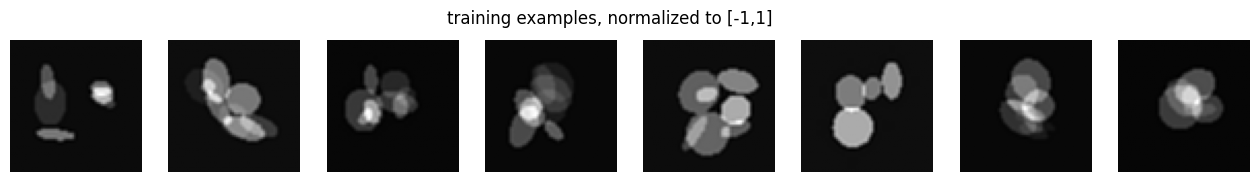

In [5]:
def show_images_grid(xs, title="", n=8):
    if not SHOW_PLOTS and not SAVE_FIGURES:
        return
    xs = xs.detach().cpu()
    n = min(n, xs.shape[0])
    fig, axes = plt.subplots(1, n, figsize=(2*n, 2))
    if n == 1:
        axes = [axes]
    for i in range(n):
        axes[i].imshow(xs[i, 0], cmap="gray", vmin=-1, vmax=1)
        axes[i].axis("off")
    fig.suptitle(title)
    if SAVE_FIGURES:
        fig.savefig(OUTPUT_DIR / "training_examples.png", dpi=150, bbox_inches="tight")
    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close(fig)

batch = next(iter(train_loader))
show_images_grid(batch, "training examples, normalized to [-1,1]", n=min(8, batch.shape[0]))


## 4. CNN score model and denoising score matching

We train a small U-Net score model on clean single-coil MRI images. The forward noising process is

\[
x_t=(1-t)x_0+\sqrt{t(2-t)}\,\xi,
\qquad \xi\sim N(0,I),
\]

and the denoising score target is

\[
s_\theta(x_t,t)\approx -\xi/\sqrt{t(2-t)}.
\]


In [6]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.dim = int(dim)

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        # t: (B,)
        half = self.dim // 2
        device = t.device
        freqs = torch.exp(torch.linspace(math.log(1.0), math.log(1000.0), half, device=device))
        args = t[:, None] * freqs[None, :]
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
        if emb.shape[-1] < self.dim:
            emb = F.pad(emb, (0, self.dim - emb.shape[-1]))
        return emb


class TimeBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, emb_dim: int):
        super().__init__()
        groups = 8 if out_ch % 8 == 0 else 1
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm1 = nn.GroupNorm(groups, out_ch)
        self.emb_proj = nn.Linear(emb_dim, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm2 = nn.GroupNorm(groups, out_ch)
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, emb):
        h = self.conv1(x)
        h = self.norm1(h)
        h = F.silu(h)
        h = h + self.emb_proj(emb)[:, :, None, None]
        h = self.conv2(h)
        h = self.norm2(h)
        h = F.silu(h)
        return h + self.skip(x)


class SmallUNetScore(nn.Module):
    def __init__(self, in_ch=1, base_ch=32, emb_dim=128):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalTimeEmbedding(emb_dim),
            nn.Linear(emb_dim, emb_dim),
            nn.SiLU(),
            nn.Linear(emb_dim, emb_dim),
        )
        self.enc1 = TimeBlock(in_ch, base_ch, emb_dim)
        self.enc2 = TimeBlock(base_ch, base_ch * 2, emb_dim)
        self.enc3 = TimeBlock(base_ch * 2, base_ch * 4, emb_dim)
        self.pool = nn.AvgPool2d(2)
        self.up2 = nn.ConvTranspose2d(base_ch * 4, base_ch * 2, 2, stride=2)
        self.dec2 = TimeBlock(base_ch * 4, base_ch * 2, emb_dim)
        self.up1 = nn.ConvTranspose2d(base_ch * 2, base_ch, 2, stride=2)
        self.dec1 = TimeBlock(base_ch * 2, base_ch, emb_dim)
        self.out = nn.Conv2d(base_ch, in_ch, 3, padding=1)

    def forward(self, x, t):
        # t should be in [0,1], shape (B,)
        emb = self.time_mlp(t)
        e1 = self.enc1(x, emb)
        e2 = self.enc2(self.pool(e1), emb)
        e3 = self.enc3(self.pool(e2), emb)
        u2 = self.up2(e3)
        if u2.shape[-2:] != e2.shape[-2:]:
            u2 = F.interpolate(u2, size=e2.shape[-2:], mode="bilinear", align_corners=False)
        d2 = self.dec2(torch.cat([u2, e2], dim=1), emb)
        u1 = self.up1(d2)
        if u1.shape[-2:] != e1.shape[-2:]:
            u1 = F.interpolate(u1, size=e1.shape[-2:], mode="bilinear", align_corners=False)
        d1 = self.dec1(torch.cat([u1, e1], dim=1), emb)
        return self.out(d1)


def dsm_loss(model: nn.Module, x0: torch.Tensor) -> torch.Tensor:
    B = x0.shape[0]
    t = torch.rand(B, device=x0.device) * (DSM_T_MAX - DSM_T_MIN) + DSM_T_MIN
    sigma = torch.sqrt(torch.clamp(t * (2.0 - t), min=1e-8)).view(B, 1, 1, 1)
    mean = (1.0 - t).view(B, 1, 1, 1) * x0
    eps = torch.randn_like(x0)
    xt = mean + sigma * eps
    target = -eps / sigma
    pred = model(xt, t)
    sq = (pred - target) ** 2
    if DSM_WEIGHT_BY_SIGMA2:
        sq = sq * sigma ** 2
    return sq.mean()


score_model = SmallUNetScore(in_ch=1, base_ch=BASE_CHANNELS, emb_dim=TIME_EMB_DIM).to(DEVICE)
print("score model parameters:", sum(p.numel() for p in score_model.parameters()) / 1e6, "M")


score model parameters: 0.562625 M


## 5. Train or load the score prior

For a first test, 3k steps is enough to check that the pipeline runs. For a usable MRI prior, increase `NUM_TRAIN_STEPS` and `MAX_FASTMRI_FILES`.


In [7]:
def infinite_loader(loader):
    while True:
        for batch in loader:
            yield batch


# score_model is created in the model-definition cell. Create it here only if cells were run out of order.
created_score_model_here = False
try:
    score_model
except NameError:
    score_model = SmallUNetScore(in_ch=1, base_ch=BASE_CHANNELS, emb_dim=TIME_EMB_DIM).to(DEVICE)
    created_score_model_here = True
if created_score_model_here:
    print("score model parameters:", sum(p.numel() for p in score_model.parameters()) / 1e6, "M")

# Always define these diagnostics, including checkpoint-only runs.
score_training_losses = []
score_training_steps = []
score_training_loss_source = "unavailable"
checkpoint_loaded = False
need_train = True

if LOAD_CHECKPOINT_IF_EXISTS and CHECKPOINT_PATH.exists():
    print(f"Loading checkpoint: {CHECKPOINT_PATH}")
    try:
        try:
            ckpt = torch.load(str(CHECKPOINT_PATH), map_location=DEVICE, weights_only=False)
        except TypeError:
            ckpt = torch.load(str(CHECKPOINT_PATH), map_location=DEVICE)

        score_model.load_state_dict(ckpt["model"] if isinstance(ckpt, dict) and "model" in ckpt else ckpt)
        checkpoint_loaded = True
        print("Using pretrained prior checkpoint:", CHECKPOINT_PATH)
        need_train = False
        print("Checkpoint loaded successfully.")

        if isinstance(ckpt, dict):
            history = ckpt.get("loss_history", ckpt.get("training_losses", None))
            if history is not None:
                if torch.is_tensor(history):
                    history = history.detach().cpu().numpy()
                score_training_losses = np.asarray(history, dtype=np.float64).reshape(-1).tolist()
                score_training_steps = list(range(1, len(score_training_losses) + 1))
                score_training_loss_source = "loaded checkpoint"
                print(f"Loaded {len(score_training_losses)} training-loss values from checkpoint.")
            else:
                print("Checkpoint contains no training-loss history; the fixed-time DSM profile below will still be evaluated.")
    except Exception as e:
        print("Could not load checkpoint; will train from scratch.")
        print("Checkpoint load error:", repr(e))

if need_train:
    if NUM_TRAIN_STEPS <= 0:
        _msg = (
            "No pretrained prior checkpoint was loaded, and NUM_TRAIN_STEPS <= 0. "
            f"Expected checkpoint at CHECKPOINT_PATH={CHECKPOINT_PATH}."
        )
        if REQUIRE_PRETRAINED_PRIOR:
            raise FileNotFoundError(
                _msg
                + " Set CHECKPOINT_PATH/SAVED_CHECKPOINT_PATH/PRIOR_CHECKPOINT_PATH to the trained prior, "
                + "or set REQUIRE_PRETRAINED_PRIOR=0 only for a smoke test."
            )
        print(_msg)
        print("REQUIRE_PRETRAINED_PRIOR=0, so leaving score model untrained for a smoke test only.")
    else:
        print("Training score model...")
        score_model.train()
        opt = torch.optim.AdamW(score_model.parameters(), lr=LR, weight_decay=1e-4)
        data_iter = infinite_loader(train_loader)
        pbar = tqdm(range(1, NUM_TRAIN_STEPS + 1))
        for step in pbar:
            x0 = next(data_iter).to(DEVICE, non_blocking=PIN_MEMORY)
            loss = dsm_loss(score_model, x0)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(score_model.parameters(), 1.0)
            opt.step()

            score_training_losses.append(float(loss.detach().cpu()))
            score_training_steps.append(int(step))
            if step % 50 == 0:
                pbar.set_description(f"loss={np.mean(score_training_losses[-50:]):.4f}")
            if step % 500 == 0:
                clear_device_cache()

        score_training_loss_source = "trained in this run"
        if SAVE_CHECKPOINT:
            CHECKPOINT_PATH.parent.mkdir(parents=True, exist_ok=True)
            torch.save(
                {
                    "model": score_model.state_dict(),
                    "config": {
                        "IMG_SIZE": IMG_SIZE,
                        "BASE_CHANNELS": BASE_CHANNELS,
                        "TIME_EMB_DIM": TIME_EMB_DIM,
                        "DSM_T_MIN": DSM_T_MIN,
                        "DSM_T_MAX": DSM_T_MAX,
                        "DSM_WEIGHT_BY_SIGMA2": DSM_WEIGHT_BY_SIGMA2,
                    },
                    # Tensor form remains compatible with recent torch.load defaults.
                    "loss_history": torch.as_tensor(score_training_losses, dtype=torch.float32),
                },
                str(CHECKPOINT_PATH),
            )
            print(f"Saved checkpoint: {CHECKPOINT_PATH}")

score_training_losses = np.asarray(score_training_losses, dtype=np.float64)
score_training_steps = np.asarray(score_training_steps, dtype=np.int64)
score_model.eval()
clear_device_cache()
print("training-loss source:", score_training_loss_source)


Loading checkpoint: /p/lustre5/wang161/smc_swissroll_tuolumne/notebooks/MRISythetic/DOLCE_GaussianCT/prior/mri_score_prior_outputs/score_prior_singlecoil_mri_64_trained.pt
Using pretrained prior checkpoint: /p/lustre5/wang161/smc_swissroll_tuolumne/notebooks/MRISythetic/DOLCE_GaussianCT/prior/mri_score_prior_outputs/score_prior_singlecoil_mri_64_trained.pt
Checkpoint loaded successfully.
Loaded 50000 training-loss values from checkpoint.
training-loss source: loaded checkpoint


## 5A. Score-prior training-loss diagnostics

The first panel displays the optimizer loss recorded during score training. The second panel evaluates the same denoising score-matching objective at fixed forward-noising times on held-out validation/synthetic samples. If an older checkpoint has no stored loss history, only the fixed-time profile is shown.


Training dataset class: SyntheticMRIDataset
Validation dataset class: SyntheticMRIDataset
Recorded optimizer losses: 50000
Fixed-time DSM loss mean/min/max: 0.014775506797377602 0.00011809947318397462 0.13419504463672638


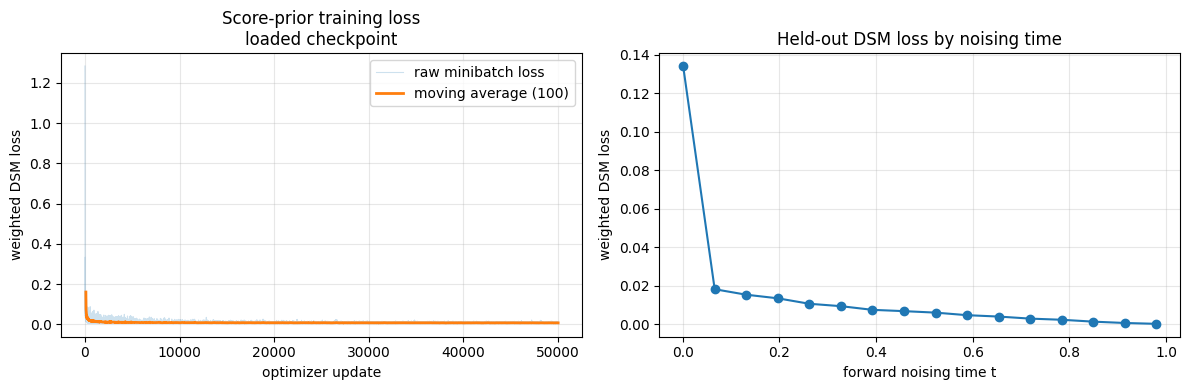

In [8]:
# ============================================================
# Score-prior training diagnostics
# ============================================================

def moving_average_1d(values, window):
    values = np.asarray(values, dtype=np.float64)
    window = max(1, min(int(window), len(values))) if len(values) else 1
    if len(values) == 0 or window == 1:
        return values.copy()
    kernel = np.ones(window, dtype=np.float64) / float(window)
    return np.convolve(values, kernel, mode="valid")


@torch.no_grad()
def dsm_loss_fixed_time_per_sample(model, x0, t_value, generator):
    """Per-sample weighted DSM loss at a fixed forward-noising time."""
    B = x0.shape[0]
    t = torch.full((B,), float(t_value), device=x0.device, dtype=x0.dtype)
    sigma = torch.sqrt(torch.clamp(t * (2.0 - t), min=1e-8)).view(B, 1, 1, 1)
    mean = (1.0 - t).view(B, 1, 1, 1) * x0
    eps = torch.randn(x0.shape, device=x0.device, dtype=x0.dtype, generator=generator)
    xt = mean + sigma * eps
    target = -eps / sigma
    pred = model(xt, t)
    sq = (pred - target) ** 2
    if DSM_WEIGHT_BY_SIGMA2:
        sq = sq * sigma ** 2
    return sq.flatten(1).mean(dim=1)


score_validation_time_grid = np.asarray([], dtype=np.float64)
score_validation_time_loss = np.asarray([], dtype=np.float64)

if TRAIN_LOSS_TIME_BINS > 0 and TRAIN_LOSS_EVAL_BATCHES > 0:
    score_model.eval()
    val_loss_loader = make_loader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
    score_validation_time_grid = np.linspace(DSM_T_MIN, DSM_T_MAX, TRAIN_LOSS_TIME_BINS)
    time_losses = []

    for t_idx, t_value in enumerate(score_validation_time_grid):
        vals = []
        generator = torch.Generator(device=DEVICE)
        generator.manual_seed(SEED + 70000 + t_idx)
        for batch_idx, batch in enumerate(val_loss_loader):
            if batch_idx >= TRAIN_LOSS_EVAL_BATCHES:
                break
            x0 = batch.to(DEVICE, non_blocking=PIN_MEMORY)
            vals.append(dsm_loss_fixed_time_per_sample(score_model, x0, t_value, generator).detach().cpu())
        time_losses.append(float(torch.cat(vals).mean()) if vals else float("nan"))

    score_validation_time_loss = np.asarray(time_losses, dtype=np.float64)

print("Training dataset class:", type(train_ds).__name__)
print("Validation dataset class:", type(val_ds).__name__)
print("Recorded optimizer losses:", int(score_training_losses.size))
if score_validation_time_loss.size:
    print("Fixed-time DSM loss mean/min/max:",
          float(np.nanmean(score_validation_time_loss)),
          float(np.nanmin(score_validation_time_loss)),
          float(np.nanmax(score_validation_time_loss)))

if PLOT_SCORE_TRAINING_LOSS and (score_training_losses.size or score_validation_time_loss.size):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    if score_training_losses.size:
        axes[0].plot(score_training_steps, score_training_losses, alpha=0.22, linewidth=0.8, label="raw minibatch loss")
        smooth = moving_average_1d(score_training_losses, TRAIN_LOSS_SMOOTH_WINDOW)
        smooth_steps = score_training_steps[len(score_training_steps) - len(smooth):]
        axes[0].plot(smooth_steps, smooth, linewidth=2.0, label=f"moving average ({min(TRAIN_LOSS_SMOOTH_WINDOW, len(score_training_losses))})")
        axes[0].set_title(f"Score-prior training loss\n{score_training_loss_source}")
        axes[0].set_xlabel("optimizer update")
        axes[0].set_ylabel("weighted DSM loss")
        axes[0].grid(True, alpha=0.3)
        axes[0].legend()
    else:
        axes[0].text(0.5, 0.5, "No stored training-loss history\nin the loaded checkpoint", ha="center", va="center")
        axes[0].set_axis_off()

    if score_validation_time_loss.size:
        axes[1].plot(score_validation_time_grid, score_validation_time_loss, marker="o")
        axes[1].set_title("Held-out DSM loss by noising time")
        axes[1].set_xlabel("forward noising time t")
        axes[1].set_ylabel("weighted DSM loss")
        axes[1].grid(True, alpha=0.3)
    else:
        axes[1].set_axis_off()

    plt.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(OUTPUT_DIR / "score_prior_training_loss.png", dpi=160, bbox_inches="tight")
    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close(fig)

np.savez_compressed(
    OUTPUT_DIR / "score_prior_training_diagnostics.npz",
    training_steps=score_training_steps,
    training_losses=score_training_losses,
    validation_time_grid=score_validation_time_grid,
    validation_time_loss=score_validation_time_loss,
    training_loss_source=np.asarray([score_training_loss_source], dtype=object),
    dataset_class=np.asarray([type(train_ds).__name__], dtype=object),
)


## 6. Terminal multiscale prior simulator

This cell implements the manuscript-style multiscale terminal partial sums. Each level is integrated over the full terminal interval $[T_0,T_1]$ and then evaluated at $t=T_1$. This replaces reverse-time checkpoint selection.


Terminal multiscale simulator defined.
Selection is at terminal time T1, not at intermediate reverse times.
T0/T1: 0.03 1.0
NUM_SMC_LEVELS: 5 NUM_REF_LEVELS: 8
SMC terminal steps: [100, 120, 140, 160, 180]
Reference terminal steps: [100, 120, 140, 160, 180, 200, 220, 240]


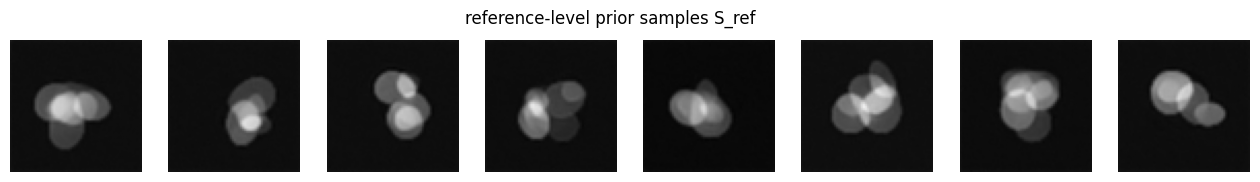

In [9]:

# ============================================================
# Manuscript-style terminal multiscale SDE simulator for images
# ============================================================
# Every level is a terminal partial sum S_m = sum_{k=0}^m Xbar^k_1.
# Selection is always performed on terminal samples, not intermediate reverse-time checkpoints.


def make_generator(seed: int, device=DEVICE):
    gen = torch.Generator(device=device)
    gen.manual_seed(int(seed))
    return gen


@torch.no_grad()
def randn_seeded(shape, seed: int, device=DEVICE, dtype=torch.float32):
    return torch.randn(shape, generator=make_generator(seed, device), device=device, dtype=dtype)


@torch.no_grad()
def score_apply_torch(tau_forward: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
    """Apply learned score. tau_forward is the forward noising time in [0,1]."""
    if not torch.is_tensor(tau_forward):
        tau_forward = torch.full((x.shape[0],), float(tau_forward), device=x.device, dtype=x.dtype)
    elif tau_forward.ndim == 0:
        tau_forward = torch.full((x.shape[0],), float(tau_forward.item()), device=x.device, dtype=x.dtype)
    return score_model(x, torch.clamp(tau_forward.to(x.device, x.dtype), min=DSM_T_MIN, max=DSM_T_MAX))


@torch.no_grad()
def base_drift_torch(t: float, y: torch.Tensor) -> torch.Tensor:
    """Reverse-SDE drift used in the multiscale increment decomposition."""
    t_safe = torch.clamp(torch.as_tensor(t, device=y.device, dtype=y.dtype), min=1e-4)
    score_time = torch.clamp(1.0 - t_safe, min=DSM_T_MIN, max=DSM_T_MAX)
    score = score_apply_torch(score_time, y)
    # Manuscript SDE drift: (x + 2 score)/t. Noise is represented separately by the level expansion.
    return (y + 2.0 * score) / t_safe


def psi_pair_torch(t, n, k):
    d = 2.0 ** (-(n - 1))
    I0 = (k - 1) * d
    I1 = k * d
    I2 = (k + 1) * d
    scale = 2.0 ** ((n - 2) / 2.0)
    tf = float(t)
    val = torch.zeros((2,), device=DEVICE)
    if (tf > I0) and (tf < I1):
        val[0] = scale
    elif (tf > I1) and (tf < I2):
        val[1] = -scale
    return val


def white_level_coeffs_torch(t, n_level):
    if n_level == 1:
        return torch.ones((1,), device=DEVICE)
    num_k_iter = 2 ** (n_level - 2)
    vals = []
    for kk in range(num_k_iter):
        k = 2 * kk + 1
        vals.append(psi_pair_torch(t, n_level, k))
    psi_flat = torch.cat(vals, dim=0)
    scal = 2.0 ** (-(n_level) / 2.0)
    return psi_flat * scal


def generate_eta_tensor_torch(max_n, batch_size, image_shape, seed):
    num_k = 2 ** (max_n - 1)
    return randn_seeded((batch_size, num_k, *image_shape), seed=seed, device=DEVICE)


def white_level_vector_torch(t, n_level, eta_batch):
    t_safe = torch.clamp(torch.as_tensor(t, device=DEVICE, dtype=eta_batch.dtype), min=1e-4)
    coeffs = white_level_coeffs_torch(float(t_safe), n_level).to(dtype=eta_batch.dtype)
    # coeffs: (K,), eta_batch: (B,K,C,H,W) -> (B,C,H,W)
    noise = torch.tensordot(coeffs, eta_batch, dims=([0], [1]))
    return noise * torch.sqrt(2.0 / t_safe)


@torch.no_grad()
def interpolate_paths_to_n_steps_torch(paths: torch.Tensor, target_n_steps: int) -> torch.Tensor:
    """Interpolate a full path to a new uniform grid on [T0,T1].

    paths has shape (old_steps+1, B, C, H, W).
    """
    old_n_steps = int(paths.shape[0] - 1)
    target_n_steps = int(target_n_steps)
    if old_n_steps == target_n_steps:
        return paths
    pos = torch.linspace(0.0, float(old_n_steps), target_n_steps + 1, device=paths.device)
    lo = torch.floor(pos).long().clamp(0, old_n_steps)
    hi = torch.ceil(pos).long().clamp(0, old_n_steps)
    w = (pos - lo.to(dtype=paths.dtype)).view(-1, 1, 1, 1, 1)
    return (1.0 - w) * paths[lo] + w * paths[hi]


@torch.no_grad()
def simulate_base_level_torch(seed: int, batch_size: int, n_steps: int, t0: float = T0, t1: float = T1) -> torch.Tensor:
    """Simulate base terminal path Xbar^0_t on [T0,T1]."""
    n_steps = int(n_steps)
    x = randn_seeded((batch_size, 1, IMG_SIZE, IMG_SIZE), seed=seed, device=DEVICE)
    omega0 = randn_seeded((batch_size, 1, IMG_SIZE, IMG_SIZE), seed=seed + 1, device=DEVICE)
    ts = torch.linspace(float(t0), float(t1), n_steps + 1, device=DEVICE)
    dt = float(t1 - t0) / float(n_steps)
    xs = [x.clone()]
    for k in range(n_steps):
        t = ts[k]
        drift = base_drift_torch(float(t.item()), x)
        if BASE_NOISE_MODE == "sqrt_2_over_t":
            noise = torch.sqrt(2.0 / torch.clamp(t, min=1e-4)) * omega0
        else:
            noise = omega0
        x = x + dt * (drift + noise)
        if SAMPLE_CLAMP is not None:
            x = torch.clamp(x, -SAMPLE_CLAMP, SAMPLE_CLAMP)
        xs.append(x.clone())
    return torch.stack(xs, dim=0)


@torch.no_grad()
def increment_drift_torch(t: float, y: torch.Tensor, x_base: torch.Tensor) -> torch.Tensor:
    return base_drift_torch(t, x_base + y) - base_drift_torch(t, x_base)


@torch.no_grad()
def simulate_increment_level_torch(
    seed: int,
    noise_level: int,
    current_paths: torch.Tensor,
    n_steps: int,
    t0: float = T0,
    t1: float = T1,
    return_base_on_grid: bool = False,
):
    """Simulate increment Xbar^noise_level_t over the full terminal interval.

    current_paths represents S_{level-1}(t). The returned increment path has terminal value
    Xbar^level_1, so current_on_grid + inc_paths is S_level(t).
    """
    n_steps = int(n_steps)
    batch_size = int(current_paths.shape[1])
    image_shape = tuple(current_paths.shape[2:])
    current_on_grid = interpolate_paths_to_n_steps_torch(current_paths, n_steps)
    eta_batch = generate_eta_tensor_torch(noise_level, batch_size, image_shape, seed)
    y = torch.zeros((batch_size, *image_shape), device=DEVICE, dtype=current_paths.dtype)
    ts = torch.linspace(float(t0), float(t1), n_steps + 1, device=DEVICE)
    dt = float(t1 - t0) / float(n_steps)
    ys = [y.clone()]
    for k in range(n_steps):
        t = ts[k]
        x_base = current_on_grid[k]
        drift = increment_drift_torch(float(t.item()), y, x_base)
        noise = white_level_vector_torch(float(t.item()), noise_level, eta_batch)
        y = y + dt * (drift + noise)
        if SAMPLE_CLAMP is not None:
            # Clamp the total state, then convert back to increment coordinates.
            total = torch.clamp(x_base + y, -SAMPLE_CLAMP, SAMPLE_CLAMP)
            y = total - x_base
        ys.append(y.clone())
    inc_paths = torch.stack(ys, dim=0)
    if return_base_on_grid:
        return inc_paths, current_on_grid
    return inc_paths


@torch.no_grad()
def simulate_prior_hierarchy_with_increments_torch(
    seed: int,
    batch_size: int,
    num_levels: int,
    n_steps_by_level,
    t0: float = T0,
    t1: float = T1,
):
    """Generate terminal multiscale hierarchy.

    Returns:
        paths_by_level[ell]      : full path for S_ell(t), terminal sample is paths_by_level[ell][-1]
        increments_by_level[ell] : full path for Xbar^ell(t)
    """
    steps = [int(s) for s in list(n_steps_by_level)]
    if len(steps) != int(num_levels):
        raise ValueError(f"n_steps_by_level must have length {num_levels}, got {len(steps)}")
    paths_by_level = []
    increments_by_level = []
    current_paths = simulate_base_level_torch(seed, batch_size, n_steps=steps[0], t0=t0, t1=t1)
    paths_by_level.append(current_paths)
    increments_by_level.append(current_paths)
    for ell in range(1, int(num_levels)):
        inc_paths, current_on_grid = simulate_increment_level_torch(
            seed + 1000 * ell,
            ell + 1,
            current_paths,
            n_steps=steps[ell],
            t0=t0,
            t1=t1,
            return_base_on_grid=True,
        )
        current_paths = current_on_grid + inc_paths
        if SAMPLE_CLAMP is not None:
            current_paths = torch.clamp(current_paths, -SAMPLE_CLAMP, SAMPLE_CLAMP)
        paths_by_level.append(current_paths)
        increments_by_level.append(inc_paths)
    return paths_by_level, increments_by_level


@torch.no_grad()
def check_increment_identity(paths_by_level, increments_by_level):
    for ell in range(1, len(paths_by_level)):
        err = torch.max(torch.abs(paths_by_level[ell][-1] - paths_by_level[ell - 1][-1] - increments_by_level[ell][-1]))
        print(f"terminal level {ell+1}: max |S_new(1)-S_prev(1)-inc(1)| = {float(err):.3e}")


@torch.no_grad()
def sample_prior_terminal(model: nn.Module, batch_size: int, chunk_size: int = SAMPLE_CHUNK_SIZE) -> torch.Tensor:
    """Reference-level terminal prior sampler: returns S_ref = S_{NUM_REF_LEVELS-1}(1)."""
    model.eval()
    chunks = []
    done = 0
    while done < int(batch_size):
        bs = min(int(chunk_size), int(batch_size) - done)
        paths, _ = simulate_prior_hierarchy_with_increments_torch(
            seed=SEED + 910000 + done,
            batch_size=bs,
            num_levels=NUM_REF_LEVELS,
            n_steps_by_level=N_STEPS_BASELINE_BY_LEVEL,
            t0=T0,
            t1=T1,
        )
        chunks.append(paths[-1][-1].detach().cpu())
        done += bs
        del paths
        clear_device_cache()
    return torch.cat(chunks, dim=0).to(DEVICE)


print("Terminal multiscale simulator defined.")
print("Selection is at terminal time T1, not at intermediate reverse times.")
print("T0/T1:", T0, T1)
print("NUM_SMC_LEVELS:", NUM_SMC_LEVELS, "NUM_REF_LEVELS:", NUM_REF_LEVELS)
print("SMC terminal steps:", N_STEPS_SMC_BY_LEVEL)
print("Reference terminal steps:", N_STEPS_REF_BY_LEVEL)

# Quick visual sample from the trained prior.
with torch.no_grad():
    prior_preview = sample_prior_terminal(score_model, batch_size=min(8, BATCH_SIZE))
show_images_grid(prior_preview, "reference-level prior samples S_ref", n=min(8, prior_preview.shape[0]))


## 7. Observation model

The default in this file is `OBS_MODE="phase_retrieval"` with a Gaussian likelihood. The nonlinear forward map observes a possibly masked two-dimensional Fourier magnitude. Because magnitude is already real, the observation dimension equals the number of retained Fourier-magnitude entries; it is **not doubled** by real/imaginary packing.

Available observation modes remain:

- `phase_retrieval`: nonlinear 2D Fourier magnitude;
- `mri_fft`: masked complex Fourier samples packed as real/imaginary values;
- `random_inpainting`: selected image pixels.


In [10]:
# DELTA_OBS is configured in Section 1.
# The held-out target x_true and y_obs are created after the MRI observation operator is defined.


OBS_MODE: mri_fft (FFT/k-space)
Mask type: lowpass_square
low-pass square size: 4 x 4
low-pass preview sizes: [4, 8, 16]
sampled k-space points: 16 / 4096 effective accel: 256.0
packed observation dimension: 32


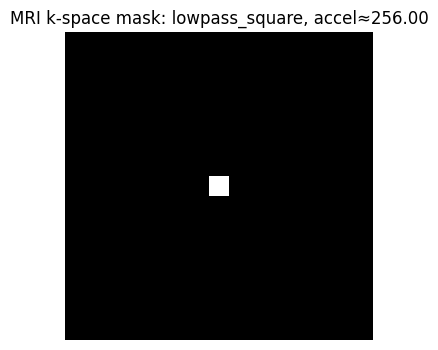

In [11]:
# ============================================================
# Observation model: spatial projection, 2D phase retrieval, FFT/MRI, or random inpainting
# ============================================================

MRI_OBS_MODES = {"mri_fft", "fft", "singlecoil_mri", "singlecoil_fft"}
RANDOM_INPAINT_OBS_MODES = {"random_inpainting", "random_inpaint", "inpaint_random", "pixel_inpaint"}
SPATIAL_PROJECTION_OBS_MODES = {"spatial_projection", "identity_projection", "masked_identity", "identity_mask", "spatial_mask", "pixel_projection"}
PHASE_RETRIEVAL_OBS_MODES = {
    "phase_retrieval", "phase_retrieval_2d", "fourier_magnitude", "fft_magnitude"
}
OBS_MODE = OBS_MODE.strip().lower()
LIKELIHOOD_TYPE = LIKELIHOOD_TYPE.strip().lower()


def make_cartesian_mask_2d(H: int, W: int, accel: int = 4, center_fraction: float = 0.08,
                           seed: int = 0, device=DEVICE) -> torch.Tensor:
    rng = np.random.default_rng(int(seed))
    mask_cols = np.zeros(W, dtype=bool)
    num_low = max(1, int(round(W * center_fraction)))
    start = W // 2 - num_low // 2
    stop = start + num_low
    mask_cols[start:stop] = True
    target_cols = max(num_low, int(round(W / accel)))
    remaining = np.flatnonzero(~mask_cols)
    extra = target_cols - int(mask_cols.sum())
    if extra > 0:
        chosen = rng.choice(remaining, size=extra, replace=False)
        mask_cols[chosen] = True
    mask = np.zeros((H, W), dtype=bool)
    mask[:, mask_cols] = True
    return torch.as_tensor(mask, dtype=torch.bool, device=device)


def make_vd_poisson_mask_2d(H: int, W: int, accel: int = 8, center_fraction: float = 0.08,
                            seed: int = 0, device=DEVICE) -> torch.Tensor:
    """Lightweight variable-density point mask for k-space experiments."""
    rng = np.random.default_rng(int(seed))
    yy, xx = np.mgrid[-1:1:complex(H), -1:1:complex(W)]
    rr = np.sqrt(xx**2 + yy**2)
    prob = np.exp(-(rr / 0.45) ** 2)
    prob = prob / prob.mean() / accel
    prob = np.clip(prob, 0.0, 1.0)
    mask = rng.random((H, W)) < prob
    low_h = max(1, int(round(H * center_fraction)))
    low_w = max(1, int(round(W * center_fraction)))
    hs = H // 2 - low_h // 2
    ws = W // 2 - low_w // 2
    mask[hs:hs + low_h, ws:ws + low_w] = True
    target = max(1, int(round(H * W / accel)))
    current = int(mask.sum())
    flat = mask.reshape(-1)
    if current < target:
        candidates = np.flatnonzero(~flat)
        add = rng.choice(candidates, size=min(target - current, len(candidates)), replace=False)
        flat[add] = True
    elif current > target:
        protected = np.zeros((H, W), dtype=bool)
        protected[hs:hs + low_h, ws:ws + low_w] = True
        candidates = np.flatnonzero(flat & ~protected.reshape(-1))
        drop = rng.choice(candidates, size=min(current - target, len(candidates)), replace=False)
        flat[drop] = False
    return torch.as_tensor(flat.reshape(H, W), dtype=torch.bool, device=device)

def make_block_mask_2d(H: int, W: int, block_size: int = 4, num_blocks: int = 4,
                       gap_size: Optional[int] = None, device=DEVICE) -> torch.Tensor:
    """Centered block k-space mask. True means observable.

    Blocks lie on a regular 2D lattice. Each block is block_size x block_size,
    and the gap between neighboring lattice blocks is gap_size. By default
    gap_size equals block_size, so 4x4 blocks have 4-pixel gaps. The selected
    blocks are filled from the Fourier center outward.
    """
    block_size = int(block_size)
    num_blocks = int(num_blocks)
    gap_size = block_size if gap_size is None else int(gap_size)
    if block_size <= 0:
        raise ValueError(f"block_size must be positive, got {block_size}")
    if num_blocks <= 0:
        raise ValueError(f"num_blocks must be positive, got {num_blocks}")
    if gap_size < 0:
        raise ValueError(f"gap_size must be nonnegative, got {gap_size}")
    if block_size > H or block_size > W:
        raise ValueError(f"block_size={block_size} does not fit mask size {H}x{W}")

    pitch = block_size + gap_size
    center_h = H // 2 - block_size // 2
    center_w = W // 2 - block_size // 2
    span = max(H, W) // max(pitch, 1) + 2

    candidates = []
    image_center_h = (H - 1) / 2.0
    image_center_w = (W - 1) / 2.0
    for r in range(-span, span + 1):
        for c in range(-span, span + 1):
            hs = center_h + r * pitch
            ws = center_w + c * pitch
            if hs < 0 or ws < 0 or hs + block_size > H or ws + block_size > W:
                continue
            bh = hs + (block_size - 1) / 2.0
            bw = ws + (block_size - 1) / 2.0
            dist2 = (bh - image_center_h) ** 2 + (bw - image_center_w) ** 2
            candidates.append((dist2, abs(r) + abs(c), r, c, hs, ws))

    if num_blocks > len(candidates):
        raise ValueError(
            f"Requested {num_blocks} blocks, but only {len(candidates)} fit in a {H}x{W} mask. "
            "Reduce BLOCK_MASK_NUM_BLOCKS, BLOCK_MASK_BLOCK_SIZE, or BLOCK_MASK_GAP."
        )

    candidates.sort()
    mask = np.zeros((H, W), dtype=bool)
    for _, _, _, _, hs, ws in candidates[:num_blocks]:
        mask[hs:hs + block_size, ws:ws + block_size] = True
    return torch.as_tensor(mask, dtype=torch.bool, device=device)


def make_lowpass_square_mask_2d(H: int, W: int, square_size: int = 16, device=DEVICE) -> torch.Tensor:
    """Centered low-pass square k-space mask. True means observable.

    The notebook uses fft2c_img, which returns fftshifted / centered k-space.
    Therefore the DC coefficient, i.e. Fourier coordinate (ky,kx)=(0,0), is at
    array index (H//2, W//2).  This mask observes only a square centered there.

    Examples for IMG_SIZE=64:
        square_size=4  -> 16 observed complex k-space coefficients
        square_size=8  -> 64 observed complex k-space coefficients
        square_size=16 -> 256 observed complex k-space coefficients

    For OBS_MODE=mri_fft, OBS_DIM is doubled because real and imaginary parts
    are packed into one real observation vector.
    """
    H = int(H)
    W = int(W)
    square_size = int(square_size)
    if H <= 0 or W <= 0:
        raise ValueError(f"H and W must be positive, got H={H}, W={W}")
    if square_size <= 0:
        raise ValueError(f"LOWPASS_SQUARE_SIZE must be positive, got {square_size}")
    if square_size > H or square_size > W:
        raise ValueError(
            f"LOWPASS_SQUARE_SIZE={square_size} does not fit inside mask size {H}x{W}."
        )

    hs = H // 2 - square_size // 2
    ws = W // 2 - square_size // 2
    mask = np.zeros((H, W), dtype=bool)
    mask[hs:hs + square_size, ws:ws + square_size] = True
    return torch.as_tensor(mask, dtype=torch.bool, device=device)


def make_random_inpainting_mask_2d(H: int, W: int, keep_fraction: float = 0.2,
                                   seed: int = 0, device=DEVICE) -> torch.Tensor:
    """Fixed random pixel inpainting mask. True means observed pixel."""
    keep_fraction = float(keep_fraction)
    if not (0.0 < keep_fraction <= 1.0):
        raise ValueError(f"INPAINT_KEEP_FRACTION must be in (0,1], got {keep_fraction}")
    rng = np.random.default_rng(int(seed))
    d = int(H * W)
    m = max(1, int(round(keep_fraction * d)))
    idx = np.sort(rng.choice(d, size=m, replace=False))
    mask = np.zeros(d, dtype=bool)
    mask[idx] = True
    return torch.as_tensor(mask.reshape(H, W), dtype=torch.bool, device=device)



def make_center_square_mask_2d(H: int, W: int, keep_fraction: float = 0.2,
                               device=DEVICE) -> torch.Tensor:
    """Centered spatial square mask. True means the pixel is observed."""
    keep_fraction = float(keep_fraction)
    if not (0.0 < keep_fraction <= 1.0):
        raise ValueError(f"keep_fraction must be in (0,1], got {keep_fraction}")
    target = max(1, int(round(keep_fraction * H * W)))
    side = max(1, int(round(math.sqrt(target))))
    side_h = min(H, side)
    side_w = min(W, max(1, int(math.ceil(target / max(side_h, 1)))))
    hs = H // 2 - side_h // 2
    ws = W // 2 - side_w // 2
    mask = np.zeros((H, W), dtype=bool)
    mask[hs:hs + side_h, ws:ws + side_w] = True
    return torch.as_tensor(mask, dtype=torch.bool, device=device)


def make_spatial_projection_mask_2d(H: int, W: int, mask_type: str = "random",
                                    keep_fraction: float = 0.2, seed: int = 0,
                                    block_size: int = 4, num_blocks: int = 4,
                                    gap_size: Optional[int] = None, device=DEVICE) -> torch.Tensor:
    """Purely spatial mask for the identity projection h(x)=P_Omega x.

    True means the corresponding image pixel is observed.  Unlike the MRI and
    phase-retrieval masks above, this mask lives in image coordinates, not in
    Fourier/k-space coordinates.
    """
    mt = str(mask_type).strip().lower()
    if mt in {"random", "uniform_random", "pixel_random"}:
        return make_random_inpainting_mask_2d(
            H, W, keep_fraction=keep_fraction, seed=seed, device=device
        )
    if mt in {"center", "center_square", "central_square"}:
        return make_center_square_mask_2d(
            H, W, keep_fraction=keep_fraction, device=device
        )
    if mt in {"block", "blocks", "block_grid"}:
        return make_block_mask_2d(
            H, W, block_size=block_size, num_blocks=num_blocks,
            gap_size=gap_size, device=device
        )
    if mt in {"full", "all", "identity"}:
        return torch.ones((H, W), dtype=torch.bool, device=device)
    raise ValueError(
        f"Unknown SPATIAL_MASK_TYPE={mask_type}; use random, center_square, block, or full."
    )

def positive_base_torch(z: torch.Tensor) -> torch.Tensor:
    if POISSON_RATE_LINK == "softplus":
        return F.softplus(z + POISSON_RATE_OFFSET)
    if POISSON_RATE_LINK == "exp":
        return torch.exp(z + POISSON_RATE_OFFSET)
    raise ValueError(f"Unknown POISSON_RATE_LINK={POISSON_RATE_LINK}")


def poisson_rate_from_z_torch(z: torch.Tensor, eps: float = POISSON_EPS) -> torch.Tensor:
    return POISSON_RATE_SCALE * positive_base_torch(z) + eps


def inverse_poisson_rate_to_z_torch(y_count: torch.Tensor) -> torch.Tensor:
    """Approximate inverse of lambda=alpha*g(z+offset)+eps, for display only."""
    base = torch.clamp(
        (y_count.to(torch.float32) - POISSON_EPS) / max(float(POISSON_RATE_SCALE), 1e-12),
        min=1e-8,
    )
    if POISSON_RATE_LINK == "softplus":
        inv = torch.where(base > 20.0, base, torch.log(torch.expm1(base) + 1e-12))
        return inv - POISSON_RATE_OFFSET
    if POISSON_RATE_LINK == "exp":
        return torch.log(base) - POISSON_RATE_OFFSET
    raise ValueError(f"Unknown POISSON_RATE_LINK={POISSON_RATE_LINK}")


def phase_retrieval_map_torch(x: torch.Tensor) -> torch.Tensor:
    """Smooth 2D Fourier amplitude/intensity map, shape (B,H,W)."""
    k = fft2c_img(x)
    power = k.real.square() + k.imag.square()
    if PHASE_RETRIEVAL_MEASUREMENT == "amplitude":
        return torch.sqrt(power + float(PHASE_RETRIEVAL_EPS) ** 2)
    if PHASE_RETRIEVAL_MEASUREMENT == "intensity":
        return power
    raise ValueError(
        f"Unknown PHASE_RETRIEVAL_MEASUREMENT={PHASE_RETRIEVAL_MEASUREMENT}; "
        "use 'amplitude' or 'intensity'."
    )


# Build the active observation mask/operator.
if OBS_MODE in PHASE_RETRIEVAL_OBS_MODES:
    if LIKELIHOOD_TYPE != "gaussian":
        raise ValueError(
            "This phase-retrieval notebook uses a Gaussian magnitude likelihood. "
            "Set LIKELIHOOD_TYPE=gaussian."
        )
    if PHASE_RETRIEVAL_MASK_TYPE == "full":
        PHASE_RETRIEVAL_MASK = torch.ones((IMG_SIZE, IMG_SIZE), dtype=torch.bool, device=DEVICE)
    elif PHASE_RETRIEVAL_MASK_TYPE == "cartesian":
        PHASE_RETRIEVAL_MASK = make_cartesian_mask_2d(
            IMG_SIZE, IMG_SIZE,
            accel=PHASE_RETRIEVAL_ACCEL,
            center_fraction=PHASE_RETRIEVAL_CENTER_FRACTION,
            seed=PHASE_RETRIEVAL_MASK_SEED,
            device=DEVICE,
        )
    elif PHASE_RETRIEVAL_MASK_TYPE in {"vd_poisson", "variable_density"}:
        PHASE_RETRIEVAL_MASK = make_vd_poisson_mask_2d(
            IMG_SIZE, IMG_SIZE,
            accel=PHASE_RETRIEVAL_ACCEL,
            center_fraction=PHASE_RETRIEVAL_CENTER_FRACTION,
            seed=PHASE_RETRIEVAL_MASK_SEED,
            device=DEVICE,
        )
    elif PHASE_RETRIEVAL_MASK_TYPE in {"block", "blocks", "block_grid"}:
        PHASE_RETRIEVAL_MASK = make_block_mask_2d(
            IMG_SIZE, IMG_SIZE,
            block_size=BLOCK_MASK_BLOCK_SIZE,
            num_blocks=BLOCK_MASK_NUM_BLOCKS,
            gap_size=BLOCK_MASK_GAP,
            device=DEVICE,
        )
    else:
        raise ValueError(
            f"Unknown PHASE_RETRIEVAL_MASK_TYPE={PHASE_RETRIEVAL_MASK_TYPE}; "
            "use full, cartesian, vd_poisson, or block."
        )

    OBS_MASK = PHASE_RETRIEVAL_MASK
    MRI_MASK = OBS_MASK  # compatibility with saving code
    OBS_INDICES = None
    OBS_DIM = int(OBS_MASK.sum().item())
    MASK_TYPE = f"phase_retrieval_{PHASE_RETRIEVAL_MASK_TYPE}"
    print("OBS_MODE:", OBS_MODE, "(nonlinear 2D Fourier magnitude)")
    print("phase-retrieval measurement:", PHASE_RETRIEVAL_MEASUREMENT)
    print("phase-retrieval mask type:", PHASE_RETRIEVAL_MASK_TYPE)
    print("observed Fourier magnitudes:", OBS_DIM, "/", IMG_SIZE * IMG_SIZE)
    if PHASE_RETRIEVAL_MASK_TYPE in {"block", "blocks", "block_mask", "block_grid"}:
        print("block mask settings: block_size/num_blocks/gap:", BLOCK_MASK_BLOCK_SIZE, BLOCK_MASK_NUM_BLOCKS, BLOCK_MASK_GAP)
    print("effective magnitude sampling factor:", IMG_SIZE * IMG_SIZE / float(OBS_DIM))
    print("Note: magnitude measurements are real, so OBS_DIM is not doubled.")

elif OBS_MODE in MRI_OBS_MODES:
    if MASK_TYPE == "cartesian":
        MRI_MASK = make_cartesian_mask_2d(
            IMG_SIZE, IMG_SIZE, accel=ACCEL, center_fraction=CENTER_FRACTION,
            seed=MRI_MASK_SEED, device=DEVICE,
        )
    elif MASK_TYPE in {"vd_poisson", "variable_density"}:
        MRI_MASK = make_vd_poisson_mask_2d(
            IMG_SIZE, IMG_SIZE, accel=ACCEL, center_fraction=CENTER_FRACTION,
            seed=MRI_MASK_SEED, device=DEVICE,
        )
    elif MASK_TYPE in {"block", "blocks", "block_mask", "block_grid"}:
        MRI_MASK = make_block_mask_2d(
            IMG_SIZE, IMG_SIZE,
            block_size=BLOCK_MASK_BLOCK_SIZE,
            num_blocks=BLOCK_MASK_NUM_BLOCKS,
            gap_size=BLOCK_MASK_GAP,
            device=DEVICE,
        )
    elif MASK_TYPE in {"lowpass_square", "lowpass", "low_pass", "center_square_lowpass", "centered_lowpass_square"}:
        MRI_MASK = make_lowpass_square_mask_2d(
            IMG_SIZE, IMG_SIZE,
            square_size=LOWPASS_SQUARE_SIZE,
            device=DEVICE,
        )
        # Normalize the saved/displayed name.
        MASK_TYPE = "lowpass_square"
    else:
        raise ValueError(
            f"Unknown MASK_TYPE={MASK_TYPE}; use cartesian, vd_poisson, block, or lowpass_square."
        )
    OBS_MASK = MRI_MASK
    OBS_INDICES = None
    OBS_DIM = int(MRI_MASK.sum().item()) * 2
    print("OBS_MODE:", OBS_MODE, "(FFT/k-space)")
    print("Mask type:", MASK_TYPE)
    if MASK_TYPE in {"block", "blocks", "block_mask", "block_grid"}:
        print("block mask settings: block_size/num_blocks/gap:", BLOCK_MASK_BLOCK_SIZE, BLOCK_MASK_NUM_BLOCKS, BLOCK_MASK_GAP)
    if MASK_TYPE in {"lowpass_square", "lowpass", "low_pass", "center_square_lowpass", "centered_lowpass_square"}:
        print("low-pass square size:", LOWPASS_SQUARE_SIZE, "x", LOWPASS_SQUARE_SIZE)
        print("low-pass preview sizes:", LOWPASS_SQUARE_SIZES)
    print("sampled k-space points:", int(MRI_MASK.sum().item()), "/", IMG_SIZE * IMG_SIZE,
          "effective accel:", IMG_SIZE * IMG_SIZE / float(MRI_MASK.sum().item()))
    print("packed observation dimension:", OBS_DIM)


elif OBS_MODE in SPATIAL_PROJECTION_OBS_MODES:
    if LIKELIHOOD_TYPE != "gaussian":
        raise ValueError(
            "OBS_MODE=spatial_projection is the linear identity-projection model "
            "y = P_Omega x + Gaussian noise. Set LIKELIHOOD_TYPE=gaussian."
        )
    OBS_MASK = make_spatial_projection_mask_2d(
        IMG_SIZE, IMG_SIZE,
        mask_type=SPATIAL_MASK_TYPE,
        keep_fraction=SPATIAL_KEEP_FRACTION,
        seed=SPATIAL_MASK_SEED,
        block_size=SPATIAL_BLOCK_SIZE,
        num_blocks=SPATIAL_NUM_BLOCKS,
        gap_size=SPATIAL_BLOCK_GAP,
        device=DEVICE,
    )
    MRI_MASK = OBS_MASK  # compatibility with existing saving/plotting code
    OBS_INDICES = torch.nonzero(OBS_MASK.reshape(-1), as_tuple=False).flatten().to(device=DEVICE)
    OBS_DIM = int(OBS_INDICES.numel())
    MASK_TYPE = f"spatial_projection_{SPATIAL_MASK_TYPE}"
    print("OBS_MODE:", OBS_MODE, "(identity operator with spatial projection mask)")
    print("Forward operator: h(x) = P_Omega x, with Omega in image/spatial coordinates")
    print("spatial mask type:", SPATIAL_MASK_TYPE)
    print("observed pixels:", OBS_DIM, "/", IMG_SIZE * IMG_SIZE,
          "observed fraction:", OBS_DIM / float(IMG_SIZE * IMG_SIZE))
    print("SPATIAL_KEEP_FRACTION:", SPATIAL_KEEP_FRACTION, "SPATIAL_MASK_SEED:", SPATIAL_MASK_SEED)
    if SPATIAL_MASK_TYPE in {"block", "blocks", "block_grid"}:
        print("spatial block settings: block_size/num_blocks/gap:",
              SPATIAL_BLOCK_SIZE, SPATIAL_NUM_BLOCKS, SPATIAL_BLOCK_GAP)

elif OBS_MODE in RANDOM_INPAINT_OBS_MODES:
    OBS_MASK = make_random_inpainting_mask_2d(
        IMG_SIZE, IMG_SIZE,
        keep_fraction=INPAINT_KEEP_FRACTION,
        seed=INPAINT_MASK_SEED,
        device=DEVICE,
    )
    MRI_MASK = OBS_MASK
    OBS_INDICES = torch.nonzero(OBS_MASK.reshape(-1), as_tuple=False).flatten().to(device=DEVICE)
    OBS_DIM = int(OBS_INDICES.numel())
    MASK_TYPE = "random_inpainting"
    print("OBS_MODE:", OBS_MODE, "(random pixel inpainting)")
    print("observed pixels:", OBS_DIM, "/", IMG_SIZE * IMG_SIZE,
          "observed fraction:", OBS_DIM / float(IMG_SIZE * IMG_SIZE))
    print("INPAINT_MASK_SEED:", INPAINT_MASK_SEED)

else:
    allowed = sorted(MRI_OBS_MODES | SPATIAL_PROJECTION_OBS_MODES | RANDOM_INPAINT_OBS_MODES | PHASE_RETRIEVAL_OBS_MODES)
    raise ValueError(f"Unknown OBS_MODE={OBS_MODE}. Use one of {allowed}.")


if SHOW_PLOTS or SAVE_FIGURES:
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(OBS_MASK.detach().cpu().numpy(), cmap="gray")
    if OBS_MODE in PHASE_RETRIEVAL_OBS_MODES:
        ax.set_title(f"Phase-retrieval magnitude mask: {PHASE_RETRIEVAL_MASK_TYPE}")
        fname = "phase_retrieval_mask.png"
    elif OBS_MODE in MRI_OBS_MODES:
        ax.set_title(f"MRI k-space mask: {MASK_TYPE}, accel≈{IMG_SIZE*IMG_SIZE/MRI_MASK.sum().item():.2f}")
        fname = "mri_kspace_mask.png"
    elif OBS_MODE in SPATIAL_PROJECTION_OBS_MODES:
        ax.set_title(f"Spatial projection mask: {SPATIAL_MASK_TYPE}, keep={OBS_DIM/(IMG_SIZE*IMG_SIZE):.2f}")
        fname = "spatial_projection_mask.png"
    else:
        ax.set_title(f"Random inpainting mask, keep={OBS_DIM/(IMG_SIZE*IMG_SIZE):.2f}")
        fname = "random_inpainting_mask.png"
    ax.axis("off")
    if SAVE_FIGURES:
        fig.savefig(OUTPUT_DIR / fname, dpi=150, bbox_inches="tight")
    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close(fig)


def apply_mri_observation_torch(x: torch.Tensor) -> torch.Tensor:
    """Generic matrix-free observation h(x), retained under the legacy function name."""
    if x.ndim == 2:
        x = x.reshape(x.shape[0], 1, IMG_SIZE, IMG_SIZE)

    if OBS_MODE in PHASE_RETRIEVAL_OBS_MODES:
        magnitude_map = phase_retrieval_map_torch(x)
        return magnitude_map[:, PHASE_RETRIEVAL_MASK].float()

    if OBS_MODE in MRI_OBS_MODES:
        k = fft2c_img(x)
        k_obs = k[:, MRI_MASK]
        return torch.cat([k_obs.real, k_obs.imag], dim=1).float()

    if OBS_MODE in SPATIAL_PROJECTION_OBS_MODES:
        flat = x.reshape(x.shape[0], -1)
        return flat[:, OBS_INDICES].float()

    if OBS_MODE in RANDOM_INPAINT_OBS_MODES:
        flat = x.reshape(x.shape[0], -1)
        return flat[:, OBS_INDICES].float()

    raise ValueError(f"Unknown OBS_MODE={OBS_MODE}")


def packed_to_masked_kspace(y_pack: torch.Tensor, mask: torch.Tensor = None) -> torch.Tensor:
    """Convert packed real/imag MRI observation to a full masked complex k-space array."""
    if OBS_MODE not in MRI_OBS_MODES:
        raise ValueError("packed_to_masked_kspace is only defined for OBS_MODE='mri_fft'.")
    if mask is None:
        mask = MRI_MASK
    if y_pack.ndim != 1:
        y_pack = y_pack.flatten()
    y_for_display = (
        inverse_poisson_rate_to_z_torch(y_pack)
        if LIKELIHOOD_TYPE in {"poisson_direct", "poisson_gaussian"}
        else y_pack
    )
    M = int(mask.sum().item())
    real = y_for_display[:M]
    imag = y_for_display[M:]
    k = torch.zeros(mask.shape, dtype=torch.complex64, device=y_pack.device)
    k[mask] = real.to(torch.float32) + 1j * imag.to(torch.float32)
    return k


def phase_retrieval_to_masked_map(y_mag: torch.Tensor, mask: torch.Tensor = None) -> torch.Tensor:
    """Scatter a phase-retrieval observation vector into a full 2D magnitude map."""
    if mask is None:
        mask = PHASE_RETRIEVAL_MASK
    full = torch.zeros(mask.shape, dtype=torch.float32, device=y_mag.device)
    full[mask] = y_mag.reshape(-1).to(torch.float32)
    return full


def phase_retrieval_zero_phase_backprojection(y_mag: torch.Tensor) -> torch.Tensor:
    """Display-only inverse FFT using the observed amplitude and zero phase.

    This is not a phase-retrieval solution; it is a deterministic visualization baseline.
    """
    observed_map = phase_retrieval_to_masked_map(y_mag)
    if PHASE_RETRIEVAL_MEASUREMENT == "intensity":
        amplitude = torch.sqrt(torch.clamp(observed_map, min=0.0))
    else:
        amplitude = torch.clamp(observed_map, min=0.0)
    k_zero_phase = amplitude.to(torch.complex64)
    x_back = ifft2c_img(k_zero_phase).real
    return x_back[None, None]


def zero_filled_reconstruction(y_pack: torch.Tensor) -> torch.Tensor:
    """Adjoint-style/display baseline for the active observation."""
    if OBS_MODE in PHASE_RETRIEVAL_OBS_MODES:
        return phase_retrieval_zero_phase_backprojection(y_pack)

    if OBS_MODE in MRI_OBS_MODES:
        k = packed_to_masked_kspace(y_pack)
        x = ifft2c_img(k).real
        return x[None, None]

    if OBS_MODE in SPATIAL_PROJECTION_OBS_MODES:
        x = torch.zeros((1, 1, IMG_SIZE, IMG_SIZE), dtype=torch.float32, device=y_pack.device)
        flat = x.reshape(-1)
        flat[OBS_INDICES] = y_pack.to(torch.float32).reshape(-1)
        return x

    if OBS_MODE in RANDOM_INPAINT_OBS_MODES:
        values = (
            inverse_poisson_rate_to_z_torch(y_pack)
            if LIKELIHOOD_TYPE in {"poisson_direct", "poisson_gaussian"}
            else y_pack
        )
        x = torch.zeros((1, 1, IMG_SIZE, IMG_SIZE), dtype=torch.float32, device=y_pack.device)
        flat = x.reshape(-1)
        flat[OBS_INDICES] = values.to(torch.float32).reshape(-1)
        return x

    raise ValueError(f"Unknown OBS_MODE={OBS_MODE}")



@torch.no_grad()
def lowpass_ifft_reconstruction_from_image(x: torch.Tensor, square_size: int) -> torch.Tensor:
    """Return zero-filled inverse FFT using only a centered low-pass square.

    This is useful for visualizing the low-resolution image that comes from the
    lowest Fourier frequencies of a candidate image/sample.

    Args:
        x: image batch with shape (B,1,H,W), (B,H,W), or one image compatible
           with fft2c_img.
        square_size: side length of centered low-pass square in k-space.

    Returns:
        Real image tensor with shape (B,1,H,W).
    """
    if x.ndim == 2:
        x = x[None, None]
    elif x.ndim == 3:
        # Interpret (B,H,W) as a batch without channel.
        x = x[:, None]
    k = fft2c_img(x)
    mask = make_lowpass_square_mask_2d(
        k.shape[-2], k.shape[-1], square_size=square_size, device=k.device
    )
    k_low = torch.zeros_like(k)
    k_low[:, mask] = k[:, mask]
    x_low = ifft2c_img(k_low).real[:, None]
    return x_low


@torch.no_grad()
def lowpass_ifft_reconstruction_from_kspace(k_centered: torch.Tensor, square_size: int) -> torch.Tensor:
    """Return real image from a centered complex k-space tensor after low-pass masking.

    Args:
        k_centered: centered/fftshifted complex k-space with shape (H,W) or (B,H,W).
        square_size: side length of centered low-pass square.

    Returns:
        Real image tensor with shape (B,1,H,W).
    """
    if k_centered.ndim == 2:
        k_centered = k_centered[None]
    mask = make_lowpass_square_mask_2d(
        k_centered.shape[-2], k_centered.shape[-1], square_size=square_size, device=k_centered.device
    )
    k_low = torch.zeros_like(k_centered)
    k_low[:, mask] = k_centered[:, mask]
    return ifft2c_img(k_low).real[:, None]


@torch.no_grad()
def lowpass_ifft_reconstruction_from_observation(y_pack: torch.Tensor, square_size: Optional[int] = None) -> torch.Tensor:
    """Zero-filled inverse FFT from the packed MRI observation vector.

    If square_size is None, this uses the active MRI_MASK.  If square_size is
    provided, it additionally keeps only the centered square of that size from
    the already-observed k-space.  It cannot invent unobserved Fourier values;
    therefore, if the active mask is 4x4, the 8x8 and 16x16 previews from y_obs
    will still contain only the observed 4x4 values.
    """
    if OBS_MODE not in MRI_OBS_MODES:
        raise ValueError("lowpass_ifft_reconstruction_from_observation is only for OBS_MODE=mri_fft.")
    k = packed_to_masked_kspace(y_pack)
    if square_size is not None:
        mask = make_lowpass_square_mask_2d(
            k.shape[-2], k.shape[-1], square_size=square_size, device=k.device
        )
        k = k * mask.to(k.device)
    x = ifft2c_img(k).real
    return x[None, None]


@torch.no_grad()
def make_lowpass_ifft_family_from_image(x: torch.Tensor, square_sizes=None):
    """Dictionary {size: IFFT(low-pass-size k-space of x)} for plotting."""
    if square_sizes is None:
        square_sizes = LOWPASS_SQUARE_SIZES
    return {
        int(s): lowpass_ifft_reconstruction_from_image(x, int(s))
        for s in list(square_sizes)
    }


def observation_mean_torch(x: torch.Tensor) -> torch.Tensor:
    """Conditional observation mean under the active likelihood."""
    z = apply_mri_observation_torch(x)
    if LIKELIHOOD_TYPE in {"poisson_direct", "poisson_gaussian"}:
        return poisson_rate_from_z_torch(z)
    return z


## 8. Choose a held-out target and generate the fixed observation


OBS_MODE: mri_fft
LIKELIHOOD_TYPE: gaussian
x_true range: -1.0 0.9999992847442627
y_clean shape: (32,)
y_obs shape: (32,)
OBS_DIM: 32


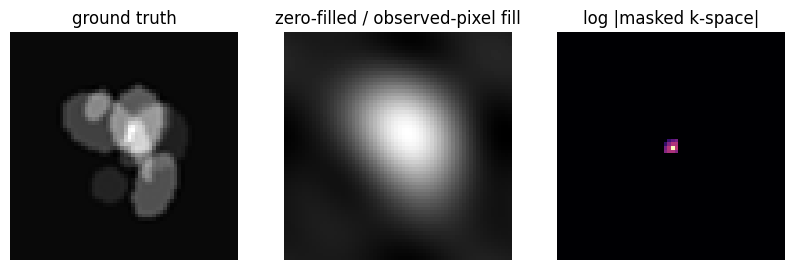

In [12]:
# Choose a target slice from validation data.
x_true = val_ds[min(3, len(val_ds) - 1)][None].to(DEVICE)  # (1,1,H,W), normalized near [-1,1]

with torch.no_grad():
    y_clean = apply_mri_observation_torch(x_true)[0]

    if LIKELIHOOD_TYPE == "gaussian":
        y_obs = y_clean.clone()
        if ADD_OBS_NOISE:
            y_obs = y_obs + DELTA_OBS * torch.randn_like(y_obs)

    elif LIKELIHOOD_TYPE in {"poisson_direct", "poisson_gaussian"}:
        lambda_target = poisson_rate_from_z_torch(y_clean)
        if POISSON_SAMPLE_COUNTS:
            y_obs = torch.poisson(lambda_target).to(torch.float32)
        else:
            y_obs = torch.round(lambda_target).to(torch.float32)

    else:
        raise ValueError(f"Unknown LIKELIHOOD_TYPE={LIKELIHOOD_TYPE}")

    # For phase retrieval this is a zero-phase backprojection, not a true inverse.
    x_zf = zero_filled_reconstruction(y_obs)

print("OBS_MODE:", OBS_MODE)
print("LIKELIHOOD_TYPE:", LIKELIHOOD_TYPE)
print("x_true range:", float(x_true.min()), float(x_true.max()))
print("y_clean shape:", tuple(y_clean.shape))
print("y_obs shape:", tuple(y_obs.shape))
print("OBS_DIM:", OBS_DIM)
if OBS_MODE in PHASE_RETRIEVAL_OBS_MODES:
    print("phase-retrieval measurement:", PHASE_RETRIEVAL_MEASUREMENT)
    print("phase-retrieval mask type:", PHASE_RETRIEVAL_MASK_TYPE)
    sign_symmetry_error = torch.max(torch.abs(
        apply_mri_observation_torch(x_true) - apply_mri_observation_torch(-x_true)
    ))
    print("max |H(x_true)-H(-x_true)|:", float(sign_symmetry_error))
if LIKELIHOOD_TYPE in {"poisson_direct", "poisson_gaussian"}:
    print("lambda_target mean/min/max:", float(lambda_target.mean()), float(lambda_target.min()), float(lambda_target.max()))
    print("y_obs count mean/min/max:", float(y_obs.mean()), float(y_obs.min()), float(y_obs.max()))

if SHOW_PLOTS or SAVE_FIGURES:
    fig, axes = plt.subplots(1, 3, figsize=(10, 3))
    axes[0].imshow(x_true[0, 0].detach().cpu(), cmap="gray", vmin=-1, vmax=1)
    axes[0].set_title("ground truth")
    axes[1].imshow(x_zf[0, 0].detach().cpu(), cmap="gray")
    axes[1].set_title(
        "zero-phase backprojection"
        if OBS_MODE in PHASE_RETRIEVAL_OBS_MODES
        else "zero-filled / observed-pixel fill"
    )

    if OBS_MODE in PHASE_RETRIEVAL_OBS_MODES:
        mag_map = phase_retrieval_to_masked_map(y_obs)
        axes[2].imshow(torch.log1p(torch.clamp(mag_map, min=0.0)).detach().cpu(), cmap="magma")
        axes[2].set_title("log observed Fourier magnitude")
    elif OBS_MODE in MRI_OBS_MODES:
        axes[2].imshow(torch.log1p(torch.abs(packed_to_masked_kspace(y_obs))).detach().cpu(), cmap="magma")
        axes[2].set_title("log |masked k-space|")
    else:
        obs_display = zero_filled_reconstruction(y_obs)
        axes[2].imshow(obs_display[0, 0].detach().cpu(), cmap="magma")
        axes[2].set_title("observed pixels display")

    for ax in axes:
        ax.axis("off")
    if SAVE_FIGURES:
        fig.savefig(OUTPUT_DIR / "target_and_observation.png", dpi=150, bbox_inches="tight")
    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close(fig)


saved low-pass IFFT preview: singlecoil_mri_tuolumne_outputs/mri_lowpass_ifft_previews_4x4_8x8_16x16.png


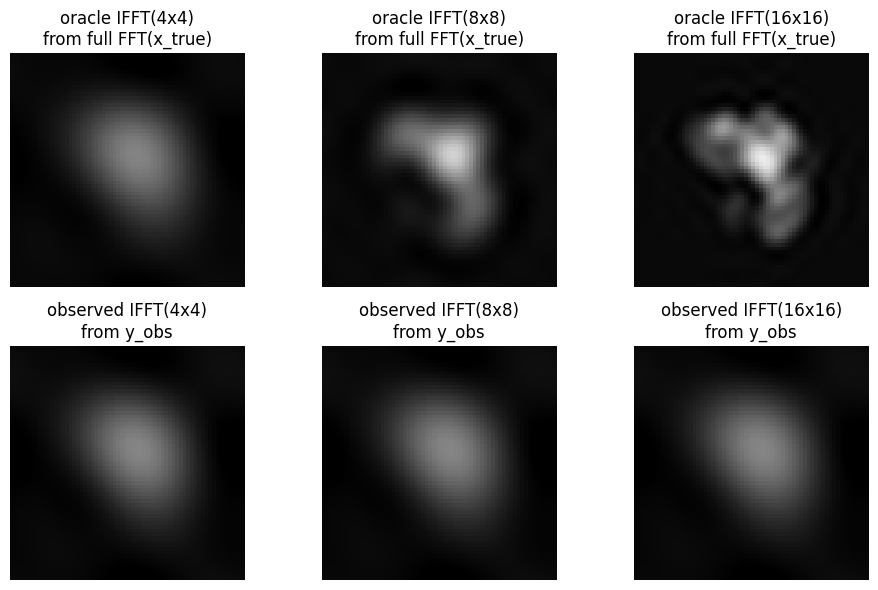

Low-pass IFFT preview sizes: [4, 8, 16]
Active MRI mask is lowpass_square with LOWPASS_SQUARE_SIZE: 4


In [13]:
# ============================================================
# Low-pass IFFT previews for MRI FFT masks
# ============================================================
# This cell is display-only. It does not change the likelihood or SMC sampler.
# For OBS_MODE=mri_fft, it shows low-resolution images formed by keeping only
# centered 4x4, 8x8, and 16x16 k-space squares and then applying inverse FFT.

if OBS_MODE in MRI_OBS_MODES:
    preview_sizes = [int(s) for s in LOWPASS_SQUARE_SIZES]

    with torch.no_grad():
        oracle_lowpass = [lowpass_ifft_reconstruction_from_image(x_true, s) for s in preview_sizes]
        observed_lowpass = [lowpass_ifft_reconstruction_from_observation(y_obs, s) for s in preview_sizes]

    if SHOW_PLOTS or SAVE_FIGURES:
        fig, axes = plt.subplots(2, len(preview_sizes), figsize=(3.2 * len(preview_sizes), 6.0), squeeze=False)

        for j, s in enumerate(preview_sizes):
            axes[0, j].imshow(oracle_lowpass[j][0, 0].detach().cpu().numpy(), cmap="gray", vmin=-1, vmax=1)
            axes[0, j].set_title(f"oracle IFFT({s}x{s})\nfrom full FFT(x_true)")
            axes[0, j].axis("off")

            axes[1, j].imshow(observed_lowpass[j][0, 0].detach().cpu().numpy(), cmap="gray", vmin=-1, vmax=1)
            axes[1, j].set_title(f"observed IFFT({s}x{s})\nfrom y_obs")
            axes[1, j].axis("off")

        plt.tight_layout()
        if SAVE_FIGURES:
            fig.savefig(OUTPUT_DIR / "mri_lowpass_ifft_previews_4x4_8x8_16x16.png", dpi=180, bbox_inches="tight")
            print("saved low-pass IFFT preview:", OUTPUT_DIR / "mri_lowpass_ifft_previews_4x4_8x8_16x16.png")
        if SHOW_PLOTS:
            plt.show()
        else:
            plt.close(fig)

    print("Low-pass IFFT preview sizes:", preview_sizes)
    if MASK_TYPE == "lowpass_square":
        print("Active MRI mask is lowpass_square with LOWPASS_SQUARE_SIZE:", LOWPASS_SQUARE_SIZE)
else:
    print("Low-pass IFFT preview skipped because OBS_MODE is not MRI FFT.")


## 9. Observation reward and gradient

For phase retrieval, the Gaussian reward is
\[
r(x)=-\frac{1}{2\delta^2}\|H_\varepsilon(x)-y\|_2^2,
\qquad
H_\varepsilon(x)=\sqrt{|\mathcal F_{2D}x|^2+\varepsilon_{\rm PR}^2}.
\]
PyTorch automatic differentiation propagates through the FFT and smooth magnitude. The same reward gradient is used both by the first-order multiscale likelihood decomposition.


In [14]:
def reward_mri(x: torch.Tensor) -> torch.Tensor:
    """Current log-likelihood/reward r(x)=log p(y_obs | x).

    Name kept as reward_mri for compatibility. It now supports both:
      - Gaussian: y | x ~ N(h(x), DELTA_OBS^2 I)
      - Poisson direct: y_j | x ~ Poisson(lambda_j(x))
      - Poisson-Gaussian: weighted quadratic approximation to Poisson
    """
    hx = apply_mri_observation_torch(x)

    if LIKELIHOOD_TYPE == "gaussian":
        res = hx - y_obs[None, :]
        quad_per_coord = (res ** 2) / (DELTA_OBS ** 2 + 1e-8)
        quad = quad_per_coord.mean(dim=1) if NORMALIZE_LIKELIHOOD_BY_OBS_DIM else quad_per_coord.sum(dim=1)
        return LIKELIHOOD_STRENGTH * (-0.5 * quad)

    if LIKELIHOOD_TYPE == "poisson_direct":
        lam = poisson_rate_from_z_torch(hx)
        logp_per_coord = y_obs[None, :] * torch.log(lam + 1e-8) - lam
        logp = logp_per_coord.mean(dim=1) if NORMALIZE_LIKELIHOOD_BY_OBS_DIM else logp_per_coord.sum(dim=1)
        return LIKELIHOOD_STRENGTH * logp

    if LIKELIHOOD_TYPE == "poisson_gaussian":
        lam = poisson_rate_from_z_torch(hx)
        var = y_obs[None, :] + POISSON_EPS
        quad_per_coord = (y_obs[None, :] - lam) ** 2 / var
        quad = quad_per_coord.mean(dim=1) if NORMALIZE_LIKELIHOOD_BY_OBS_DIM else quad_per_coord.sum(dim=1)
        return LIKELIHOOD_STRENGTH * (-0.5 * quad)

    raise ValueError(f"Unknown LIKELIHOOD_TYPE={LIKELIHOOD_TYPE}")


@torch.no_grad()
def reward_mri_value_chunked(x: torch.Tensor, chunk_size: int = REWARD_EVAL_CHUNK_SIZE) -> torch.Tensor:
    vals = []
    for xs in x.split(chunk_size, dim=0):
        vals.append(reward_mri(xs))
    return torch.cat(vals, dim=0)


def reward_and_grad_mri(x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
    x_req = x.detach().clone().requires_grad_(True)
    r = reward_mri(x_req)
    g = torch.autograd.grad(r.sum(), x_req, create_graph=False, retain_graph=False)[0]
    return r.detach(), g.detach()


# Sanity check reward and gradient.
rt, gt = reward_and_grad_mri(x_true)
print("reward at ground truth:", float(rt.item()), "grad norm:", float(gt.flatten().norm()))
print("active OBS_MODE:", OBS_MODE)
print("active LIKELIHOOD_TYPE:", LIKELIHOOD_TYPE)
print("OBS_DIM:", OBS_DIM, "NORMALIZE_LIKELIHOOD_BY_OBS_DIM:", NORMALIZE_LIKELIHOOD_BY_OBS_DIM)


# Phase-retrieval-specific autodiff sanity check.
if OBS_MODE in PHASE_RETRIEVAL_OBS_MODES:
    direction = torch.randn_like(x_true)
    direction = direction / (torch.linalg.vector_norm(direction) + 1e-12)
    eps_fd = 1e-3
    with torch.no_grad():
        fd = (reward_mri(x_true + eps_fd * direction) - reward_mri(x_true - eps_fd * direction)) / (2.0 * eps_fd)
    ad = torch.sum(gt * direction)
    rel = torch.abs(fd.reshape(()) - ad) / (torch.abs(fd.reshape(())) + torch.abs(ad) + 1e-8)
    print("phase-retrieval finite-difference directional derivative:", float(fd.item()))
    print("phase-retrieval autodiff directional derivative:", float(ad.item()))
    print("phase-retrieval directional-gradient relative error:", float(rel.item()))


reward at ground truth: -19.874998092651367 grad norm: 22.930458068847656
active OBS_MODE: mri_fft
active LIKELIHOOD_TYPE: gaussian
OBS_DIM: 32 NORMALIZE_LIKELIHOOD_BY_OBS_DIM: False


## 10. Build first-order tail statistics from the terminal reference hierarchy

This follows Algorithm 2 in the manuscript. For each paired prior realization, the code builds terminal partial sums $S_0,\ldots,S_{M-1}$ and a higher terminal reference $S_{\rm ref}$. The unresolved tail is estimated in **image/state space**,
\[
R_m=S_{\rm ref}-S_m,
\qquad
\widehat\mu_{>m}\approx\mathbb E[R_m].
\]
For nonlinear phase retrieval, no linear $A\Sigma A^\top$ closure is used. Instead, the level surrogate uses the autodifferentiated phase-retrieval reward gradient.


In [15]:

# ============================================================
# Tail statistics for terminal partial sums S_m and reference S_ref
# ============================================================

@torch.no_grad()
def trace_var_per_dim_from_sums(sum_x: torch.Tensor, sum_x2: torch.Tensor, n: int) -> torch.Tensor:
    mean = sum_x / float(n)
    mean2 = sum_x2 / float(n)
    var = torch.clamp(mean2 - mean ** 2, min=0.0)
    return var.mean()


@torch.no_grad()
def build_tail_statistics(model: nn.Module, n_ref: int = N_REF_TAIL, chunk_size: int = SAMPLE_CHUNK_SIZE):
    """Streaming Algorithm-2 tail statistics for terminal multiscale levels.

    SMC levels:       S_0, ..., S_{NUM_SMC_LEVELS-1}, all at terminal time T1.
    Reference level:  S_ref = S_{NUM_REF_LEVELS-1}, also at terminal time T1.
    Tail:             R_m = S_ref - S_m.
    """
    model.eval()
    shape = (1, 1, IMG_SIZE, IMG_SIZE)
    sum_ref = torch.zeros(shape, dtype=torch.float64)
    sum_ref2 = torch.zeros(shape, dtype=torch.float64)
    sum_level = [torch.zeros(shape, dtype=torch.float64) for _ in range(NUM_SMC_LEVELS)]
    sum_level2 = [torch.zeros(shape, dtype=torch.float64) for _ in range(NUM_SMC_LEVELS)]
    sum_tail = [torch.zeros(shape, dtype=torch.float64) for _ in range(NUM_SMC_LEVELS)]
    sum_tail2 = [torch.zeros(shape, dtype=torch.float64) for _ in range(NUM_SMC_LEVELS)]

    count = 0
    pbar = tqdm(range(0, int(n_ref), int(chunk_size)), desc="tail stats terminal", leave=False)
    for start in pbar:
        bs = min(int(chunk_size), int(n_ref) - int(start))
        paths_ref, increments_ref = simulate_prior_hierarchy_with_increments_torch(
            seed=SEED + 700000 + int(start),
            batch_size=bs,
            num_levels=NUM_REF_LEVELS,
            n_steps_by_level=N_STEPS_REF_BY_LEVEL,
            t0=T0,
            t1=T1,
        )
        finals_cpu = [p[-1].detach().cpu().to(torch.float64) for p in paths_ref]
        x_ref = finals_cpu[-1]
        sum_ref += x_ref.sum(dim=0, keepdim=True)
        sum_ref2 += (x_ref ** 2).sum(dim=0, keepdim=True)

        for m in range(NUM_SMC_LEVELS):
            xm = finals_cpu[m]
            tail = x_ref - xm
            sum_level[m] += xm.sum(dim=0, keepdim=True)
            sum_level2[m] += (xm ** 2).sum(dim=0, keepdim=True)
            sum_tail[m] += tail.sum(dim=0, keepdim=True)
            sum_tail2[m] += (tail ** 2).sum(dim=0, keepdim=True)

        count += bs
        del paths_ref, increments_ref, finals_cpu, x_ref
        clear_device_cache()

    var_ref = trace_var_per_dim_from_sums(sum_ref, sum_ref2, count)
    mu_tails = []
    eta = []
    tail_vars = []
    level_vars = []
    gap_vars = []

    for m in range(NUM_SMC_LEVELS):
        mu = (sum_tail[m] / float(count)).to(torch.float32)
        var_m = trace_var_per_dim_from_sums(sum_level[m], sum_level2[m], count)
        var_tail = trace_var_per_dim_from_sums(sum_tail[m], sum_tail2[m], count)
        gap = torch.clamp(var_ref - var_m, min=0.0)
        mu_tails.append(mu.detach())
        level_vars.append(float(var_m.cpu()))
        tail_vars.append(float(var_tail.cpu()))
        gap_vars.append(float(gap.cpu()))

    if USE_MONOTONE_GAP:
        # Same convention as the Swiss-roll notebook: avoid increasing gaps across levels.
        gap_np = np.minimum.accumulate(np.asarray(gap_vars, dtype=np.float64))
        gap_vars = [float(x) for x in gap_np]

    for m in range(NUM_SMC_LEVELS):
        tv = max(float(tail_vars[m]), 1e-12)
        eta_m = math.sqrt(max(float(gap_vars[m]), 0.0) / tv)
        eta.append(float(eta_m))

    info = {
        "eta": eta,
        "tail_vars": tail_vars,
        "level_vars": level_vars,
        "gap_vars": gap_vars,
        "var_ref": float(var_ref.cpu()),
        "n_ref": int(count),
        "num_smc_levels": int(NUM_SMC_LEVELS),
        "num_ref_levels": int(NUM_REF_LEVELS),
        "reference_level_one_based": int(NUM_REF_LEVELS),
        "smc_level_one_based": list(range(1, NUM_SMC_LEVELS + 1)),
    }
    return mu_tails, eta, info




# ============================================================
# Load precomputed prior-only tail statistics, or recompute only if explicitly allowed
# ============================================================

def _tail_stats_fail_or_warn(msg: str):
    if STRICT_TAIL_STATS_COMPATIBILITY:
        raise ValueError(msg)
    print("WARNING:", msg)


def _maybe_float_close(a, b, tol=1e-6):
    try:
        return abs(float(a) - float(b)) <= float(tol)
    except Exception:
        return False


def _unpack_npz_object(obj):
    try:
        item = np.asarray(obj, dtype=object).reshape(-1)[0]
        if hasattr(item, "item"):
            item = item.item()
        return item
    except Exception:
        return None


def _validate_tail_stats_info(info: dict, path: pathlib.Path):
    if not isinstance(info, dict):
        return
    checks = []
    if "IMG_SIZE" in info:
        checks.append(("IMG_SIZE", int(info["IMG_SIZE"]), int(IMG_SIZE)))
    if "num_ref_levels" in info:
        checks.append(("NUM_REF_LEVELS", int(info["num_ref_levels"]), int(NUM_REF_LEVELS)))
    if "T0" in info and not _maybe_float_close(info["T0"], T0, tol=1e-6):
        _tail_stats_fail_or_warn(f"Tail stats T0={info['T0']} does not match notebook T0={T0}: {path}")
    if "T1" in info and not _maybe_float_close(info["T1"], T1, tol=1e-6):
        _tail_stats_fail_or_warn(f"Tail stats T1={info['T1']} does not match notebook T1={T1}: {path}")
    if "BASE_NOISE_MODE" in info and str(info["BASE_NOISE_MODE"]) != str(BASE_NOISE_MODE):
        _tail_stats_fail_or_warn(f"Tail stats BASE_NOISE_MODE={info['BASE_NOISE_MODE']} does not match notebook BASE_NOISE_MODE={BASE_NOISE_MODE}: {path}")
    if "N_STEPS_REF_BY_LEVEL" in info:
        saved_steps = [int(s) for s in list(info["N_STEPS_REF_BY_LEVEL"])]
        if saved_steps != [int(s) for s in N_STEPS_REF_BY_LEVEL]:
            _tail_stats_fail_or_warn(f"Tail stats reference steps {saved_steps} do not match notebook steps {N_STEPS_REF_BY_LEVEL}: {path}")
    for name, saved, current in checks:
        if saved != current:
            _tail_stats_fail_or_warn(f"Tail stats {name}={saved} does not match notebook {name}={current}: {path}")


def load_tail_statistics_npz(path: pathlib.Path):
    """Load prior-only terminal-tail statistics saved by Load_Saved_ScorePrior_Save_TailStats.ipynb.

    Required arrays:
        mu_tail_by_level : (num_tail_levels, 1, 1, H, W) or compatible
        eta_by_level     : (num_tail_levels,)

    The SMC algorithm uses only levels S_0..S_{NUM_SMC_LEVELS-1}; extra saved
    levels are ignored.
    """
    path = pathlib.Path(path).expanduser()
    if not path.exists():
        raise FileNotFoundError(f"Tail-stats npz does not exist: {path}")

    data = np.load(path, allow_pickle=True)
    if "mu_tail_by_level" not in data or "eta_by_level" not in data:
        raise KeyError(f"{path} must contain mu_tail_by_level and eta_by_level")

    mu_np = np.asarray(data["mu_tail_by_level"])
    eta_np = np.asarray(data["eta_by_level"], dtype=np.float64).reshape(-1)
    if mu_np.shape[0] < NUM_SMC_LEVELS:
        raise ValueError(f"Tail stats have only {mu_np.shape[0]} levels, but NUM_SMC_LEVELS={NUM_SMC_LEVELS}: {path}")
    if eta_np.shape[0] < NUM_SMC_LEVELS:
        raise ValueError(f"eta_by_level has only {eta_np.shape[0]} levels, but NUM_SMC_LEVELS={NUM_SMC_LEVELS}: {path}")

    loaded_info = _unpack_npz_object(data["info"]) if "info" in data else {}
    if not isinstance(loaded_info, dict):
        loaded_info = {}
    _validate_tail_stats_info(loaded_info, path)

    mu_list = [torch.as_tensor(mu_np[m], dtype=torch.float32) for m in range(NUM_SMC_LEVELS)]
    eta_list = [float(eta_np[m]) for m in range(NUM_SMC_LEVELS)]

    def _arr_or_info(name, default=np.nan):
        if name in data:
            return np.asarray(data[name], dtype=np.float64).reshape(-1)[:NUM_SMC_LEVELS].tolist()
        if name in loaded_info:
            return list(loaded_info[name])[:NUM_SMC_LEVELS]
        return [float(default)] * NUM_SMC_LEVELS

    info = {
        "source": "loaded_npz",
        "path": str(path),
        "level_vars": _arr_or_info("level_vars"),
        "tail_vars": _arr_or_info("tail_vars"),
        "gap_vars": _arr_or_info("gap_vars"),
        "var_ref": float(loaded_info.get("var_ref", np.nan)),
        "n_ref_tail": int(loaded_info.get("n_ref_tail", N_REF_TAIL)),
        "num_tail_levels_saved": int(mu_np.shape[0]),
    }
    # Keep all metadata for downstream saved results.
    info.update({f"saved_{k}": v for k, v in loaded_info.items() if k not in info})
    return mu_list, eta_list, info


def get_tail_statistics_for_smc():
    global TAIL_STATS_NPZ_PATH
    if LOAD_PRECOMPUTED_TAIL_STATS:
        if TAIL_STATS_NPZ_PATH.exists():
            print("Loading precomputed prior-only terminal-tail stats:", TAIL_STATS_NPZ_PATH)
            return load_tail_statistics_npz(TAIL_STATS_NPZ_PATH)
        print("Precomputed tail-stats file was not found:", TAIL_STATS_NPZ_PATH)
        if not RECOMPUTE_TAIL_STATS_IF_MISSING:
            raise FileNotFoundError(
                "Precomputed tail stats were requested but not found. "
                "Set TAIL_STATS_NPZ_PATH to your score_prior_tail_behavior_stats.npz, "
                "or set RECOMPUTE_TAIL_STATS_IF_MISSING=1 to rebuild them."
            )

    print("Recomputing terminal tail statistics because loading is disabled or missing.")
    t0 = time.time()
    mu, eta, info = build_tail_statistics(score_model, N_REF_TAIL)
    sync_device()
    print("built terminal tail statistics in %.1f sec" % (time.time() - t0))
    info = dict(info)
    info["source"] = "recomputed_in_smc_notebook"
    return mu, eta, info


t0 = time.time()
mu_tail_by_level, eta_by_level, tail_info = get_tail_statistics_for_smc()
sync_device()
print("prepared terminal tail statistics in %.1f sec" % (time.time() - t0))
print("SMC levels are terminal partial sums S_0..S_%d" % (NUM_SMC_LEVELS - 1))
print("Reference is terminal level %d, S_ref = S_%d" % (NUM_REF_LEVELS, NUM_REF_LEVELS - 1))
print("tail stats source:", tail_info.get("source", "unknown"))
print("tail stats path:", tail_info.get("path", None))
print("eta_by_level:", eta_by_level)
print("level var:", tail_info.get("level_vars"))
print("tail var:", tail_info.get("tail_vars"))
print("gap var:", tail_info.get("gap_vars"))
print("var_ref:", tail_info.get("var_ref"))


Loading precomputed prior-only terminal-tail stats: /p/lustre5/wang161/smc_swissroll_tuolumne/notebooks/MRISythetic/DOLCE_GaussianCT/prior/mri_score_prior_outputs/score_prior_tail_behavior_stats.npz
prepared terminal tail statistics in 0.0 sec
SMC levels are terminal partial sums S_0..S_4
Reference is terminal level 8, S_ref = S_7
tail stats source: loaded_npz
tail stats path: /p/lustre5/wang161/smc_swissroll_tuolumne/notebooks/MRISythetic/DOLCE_GaussianCT/prior/mri_score_prior_outputs/score_prior_tail_behavior_stats.npz
eta_by_level: [0.8434957823340496, 0.7194763178858056, 0.6370923708485051, 0.5859083975987452, 0.5442095497230831]
level var: [0.016091654094295867, 0.027929056440802725, 0.03325020438458265, 0.035855852146333606, 0.03705587243360479]
tail var: [0.031113444827849893, 0.019896507882289104, 0.012265007285584266, 0.006911255100542117, 0.0039590733983735716]
gap var: [0.02213675348791213, 0.010299351141405271, 0.004978203197625347, 0.0023725554358743906, 0.0011725351486032

## 11. Branch/kill SMC on terminal partial sums

At each level, the code simulates the next terminal multiscale increment, forms the proposed terminal partial sum $\widetilde S_m$, evaluates the nonlinear phase-retrieval likelihood surrogate, and uses
\[
L_m(\widetilde S_m)-L_{m-1}(S_{m-1})
\]
for unbiased branch/kill selection. Selection is performed only at terminal time, consistent with the manuscript algorithm.


In [16]:




# ============================================================
# Branch/kill SMC on terminal partial sums S_m(1)
# ============================================================

# ============================================================
# Three-mode likelihood surrogate
# ============================================================
# Supported modes:
#   "none"       : L_m(x) = r(x)
#   "inv_m"      : L_m(x) = r(x) + eta_m / m       * <grad r(x), mu_tail_m>
#   "inv_sqrt_m" : L_m(x) = r(x) + eta_m / sqrt(m) * <grad r(x), mu_tail_m>
#
# This modifies only the Taylor correction. The base likelihood reward r(x)
# remains whatever reward_mri(x) computes. Therefore, if
# NORMALIZE_LIKELIHOOD_BY_OBS_DIM=False, these modes do not temper the main
# likelihood; they only change the finite-level correction.


def canonical_likelihood_surrogate_mode(mode: str = None) -> str:
    """Map user/legacy strings to one of: none, inv_m, inv_sqrt_m."""
    if mode is None:
        mode = LIKELIHOOD_SURROGATE_MODE
    mode = str(mode).strip().lower()

    if mode in ("none", "no", "off", "likelihood", "current", "0"):
        return "none"
    if mode in ("inv_m", "1/m", "m", "obs_dim", "dim"):
        return "inv_m"
    if mode in ("inv_sqrt_m", "1/sqrt_m", "sqrt_m", "sqrt_obs_dim", "1/sqrt(m)"):
        return "inv_sqrt_m"

    raise ValueError(
        f"Unknown LIKELIHOOD_SURROGATE_MODE={mode}. "
        "Use one of: none, inv_m, inv_sqrt_m."
    )


# Canonicalize once after OBS_DIM exists.
LIKELIHOOD_SURROGATE_MODE = canonical_likelihood_surrogate_mode(LIKELIHOOD_SURROGATE_MODE)
TAIL_CORRECTION_NORM_MODE = LIKELIHOOD_SURROGATE_MODE  # legacy alias only


def tail_correction_multiplier() -> float:
    """
    Return c_m in

        L_m(x) = r(x) + c_m * eta_m * <grad r(x), mu_tail_m>.

    Modes:
        none       -> c_m = 0
        inv_m      -> c_m = TAIL_CORRECTION_EXTRA_SCALE / OBS_DIM
        inv_sqrt_m -> c_m = TAIL_CORRECTION_EXTRA_SCALE / sqrt(OBS_DIM)
    """
    mode = canonical_likelihood_surrogate_mode(LIKELIHOOD_SURROGATE_MODE)
    m = float(OBS_DIM)

    if mode == "none":
        base = 1
    elif mode == "inv_m":
        base = 1.0 / m
    elif mode == "inv_sqrt_m":
        base = 1.0 / math.sqrt(m)
    else:
        raise RuntimeError(f"unreachable mode {mode}")

    return float(TAIL_CORRECTION_EXTRA_SCALE) * float(base)


# Backward-compatible alias for older print/save statements.
def tail_correction_scale_value() -> float:
    return tail_correction_multiplier()


def print_likelihood_surrogate_mode_check():
    """Small diagnostic so the run log records the actual active mode."""
    print("=" * 80)
    print("LIKELIHOOD SURROGATE MODE CHECK")
    print("=" * 80)
    print("LIKELIHOOD_SURROGATE_MODE       :", LIKELIHOOD_SURROGATE_MODE)
    print("OBS_DIM                         :", OBS_DIM)
    print("TAIL_CORRECTION_EXTRA_SCALE     :", TAIL_CORRECTION_EXTRA_SCALE)
    print("tail_correction_multiplier      :", tail_correction_multiplier())
    print("NORMALIZE_LIKELIHOOD_BY_OBS_DIM :", NORMALIZE_LIKELIHOOD_BY_OBS_DIM)
    print("=" * 80)


print_likelihood_surrogate_mode_check()


def L_surrogate(
    level: int,
    x: torch.Tensor,
    chunk_size: int = L_SURROGATE_CHUNK_SIZE,
) -> torch.Tensor:
    """
    Chunked first-order likelihood surrogate L_m(x).

    Modes:
        none:
            L_m(x) = r(x)

        inv_m:
            L_m(x) = r(x) + eta_m / m * <grad r(x), mu_tail_m>

        inv_sqrt_m:
            L_m(x) = r(x) + eta_m / sqrt(m) * <grad r(x), mu_tail_m>

    The base likelihood r(x) is not divided by m here. Only the Taylor
    correction is scaled.
    """
    mu = mu_tail_by_level[level].to(device=x.device, dtype=x.dtype)

    # Make mu broadcastable with x of shape (B,C,H,W).
    if mu.ndim == x.ndim - 1:
        mu = mu.unsqueeze(0)
    elif mu.ndim == x.ndim - 2:
        mu = mu.unsqueeze(0).unsqueeze(0)

    eta = torch.as_tensor(eta_by_level[level], device=x.device, dtype=x.dtype)
    corr_mult = torch.as_tensor(tail_correction_multiplier(), device=x.device, dtype=x.dtype)

    vals = []
    for xs in x.split(chunk_size, dim=0):
        with torch.enable_grad():
            r, g = reward_and_grad_mri(xs)

        r = r.detach()
        g = g.detach()

        # <grad r(x), mu_tail_m>
        corr = torch.sum(g * mu, dim=tuple(range(1, g.ndim)))
        vals.append(r + corr_mult * eta * corr)

    return torch.cat(vals, dim=0)


def normalize_logweights_torch(logw: torch.Tensor) -> torch.Tensor:
    return torch.exp(logw - torch.logsumexp(logw, dim=0))


def ess_from_logweights_torch(logw: torch.Tensor) -> torch.Tensor:
    w = normalize_logweights_torch(logw)
    return 1.0 / torch.sum(w ** 2)


def stochastic_round_resample_paths_torch(paths: torch.Tensor, logw: torch.Tensor, target_N: int, seed: int):
    """Unbiased branch/kill resampling of whole terminal paths."""
    N_current = int(paths.shape[1])
    w = normalize_logweights_torch(logw.detach())
    gen = make_generator(seed, DEVICE)
    U = torch.rand((N_current,), device=DEVICE, generator=gen)
    counts = torch.floor(float(target_N) * w + U).to(torch.int64)
    idx = torch.repeat_interleave(torch.arange(N_current, device=DEVICE), counts)
    if idx.numel() == 0:
        idx = torch.multinomial(w, num_samples=int(target_N), replacement=True)
    return paths[:, idx, ...], counts, idx


# ---- Per-level metric helpers ----
def rmse_level(x, y):
    return float(torch.sqrt(torch.mean((x - y) ** 2)).detach().cpu())


def mae_level(x, y):
    return float(torch.mean(torch.abs(x - y)).detach().cpu())


def psnr_level(x, y, data_range=2.0):
    r = rmse_level(x, y)
    return float(20.0 * math.log10(float(data_range) / max(r, 1e-12)))


def ssim_level(x, y, window=7, data_range=2.0):
    if x.ndim == 3:
        x = x[None]
    if y.ndim == 3:
        y = y[None]
    C1 = (0.01 * data_range) ** 2
    C2 = (0.03 * data_range) ** 2
    pad = window // 2
    mu_x = F.avg_pool2d(x, window, stride=1, padding=pad)
    mu_y = F.avg_pool2d(y, window, stride=1, padding=pad)
    sig_x = F.avg_pool2d(x * x, window, stride=1, padding=pad) - mu_x ** 2
    sig_y = F.avg_pool2d(y * y, window, stride=1, padding=pad) - mu_y ** 2
    sig_xy = F.avg_pool2d(x * y, window, stride=1, padding=pad) - mu_x * mu_y
    ssim_map = ((2 * mu_x * mu_y + C1) * (2 * sig_xy + C2)) / (
        (mu_x ** 2 + mu_y ** 2 + C1) * (sig_x + sig_y + C2)
    )
    return float(ssim_map.mean().detach().cpu())


def obs_rmse_level(x):
    # For Gaussian this compares h(x) to y_obs.
    # For Poisson this compares the predicted count mean lambda(x) to the fixed count observation.
    hx_mean = observation_mean_torch(x)
    return float(torch.sqrt(torch.mean((hx_mean - y_obs[None, :]) ** 2)).detach().cpu())


def uncertainty_metrics_level(samples: torch.Tensor, mean_est: torch.Tensor, truth: torch.Tensor):
    std = samples.std(dim=0, keepdim=True)
    err = torch.abs(mean_est - truth)
    sf = std.flatten()
    ef = err.flatten()
    corr = torch.sum((sf - sf.mean()) * (ef - ef.mean())) / (
        torch.sqrt(torch.sum((sf - sf.mean()) ** 2)) * torch.sqrt(torch.sum((ef - ef.mean()) ** 2)) + 1e-12
    )
    q025 = torch.quantile(samples, 0.025, dim=0, keepdim=True)
    q975 = torch.quantile(samples, 0.975, dim=0, keepdim=True)
    coverage = ((truth >= q025) & (truth <= q975)).float().mean()
    width = (q975 - q025).mean()
    return {
        "std_mean": float(std.mean().detach().cpu()),
        "std_max": float(std.max().detach().cpu()),
        "uncertainty_error_corr": float(corr.detach().cpu()),
        "coverage_95": float(coverage.detach().cpu()),
        "avg_width_95": float(width.detach().cpu()),
    }


def evaluate_level_samples(prefix: str, samples: torch.Tensor):
    with torch.no_grad():
        mean = samples.mean(dim=0, keepdim=True)
        rewards = reward_mri_value_chunked(samples)
        map_x = samples[int(torch.argmax(rewards).detach().cpu())][None]
    out = {
        f"{prefix} mean RMSE": rmse_level(mean, x_true),
        f"{prefix} mean MAE": mae_level(mean, x_true),
        f"{prefix} mean PSNR": psnr_level(mean, x_true),
        f"{prefix} mean SSIM": ssim_level(mean, x_true),
        f"{prefix} mean obs RMSE": obs_rmse_level(mean),
        f"{prefix} mean reward": float(reward_mri_value_chunked(mean).detach().cpu().mean()),
        f"{prefix} MAP-like RMSE": rmse_level(map_x, x_true),
        f"{prefix} MAP-like MAE": mae_level(map_x, x_true),
        f"{prefix} MAP-like PSNR": psnr_level(map_x, x_true),
        f"{prefix} MAP-like SSIM": ssim_level(map_x, x_true),
        f"{prefix} MAP-like obs RMSE": obs_rmse_level(map_x),
        f"{prefix} MAP-like reward": float(reward_mri_value_chunked(map_x).detach().cpu().mean()),
    }
    um = uncertainty_metrics_level(samples, mean, x_true)
    out.update({f"{prefix} {k}": v for k, v in um.items()})
    return out, mean.detach().cpu(), map_x.detach().cpu(), samples.std(dim=0, keepdim=True).detach().cpu()


def print_metric_block(metrics: dict):
    for k, v in metrics.items():
        print(f"{k:48s}: {v:.6g}")


@torch.no_grad()
def print_sample_summary(name: str, x: torch.Tensor):
    print(
        f"{name:28s} shape={tuple(x.shape)} "
        f"min={float(x.min()): .4g} max={float(x.max()): .4g} "
        f"mean={float(x.mean()): .4g} std={float(x.std()): .4g}"
    )


def run_multilevel_smc_scoreprior(model: nn.Module, n_particles: int = N_PARTICLES):
    """Algorithm-1 style SMC: select terminal partial sums at each multiscale level."""
    model.eval()
    smc_steps = [int(s) for s in N_STEPS_SMC_BY_LEVEL]

    samples_by_level = []
    paths_by_level = []
    ess_by_level = []
    pop_by_level = []
    counts_by_level = []
    idx_by_level = []
    metrics_by_level = []
    means_by_level = []
    maps_by_level = []
    stds_by_level = []

    print("=" * 80)
    print("START TERMINAL MULTISCALE SMC")
    print("Selection occurs only at terminal time T1 for each partial sum S_m.")
    print("NUM_SMC_LEVELS:", NUM_SMC_LEVELS, "NUM_REF_LEVELS:", NUM_REF_LEVELS)
    print("SMC steps:", smc_steps)
    print("Reference steps:", N_STEPS_REF_BY_LEVEL)
    print("eta_by_level:", eta_by_level)
    print("LIKELIHOOD_SURROGATE_MODE:", LIKELIHOOD_SURROGATE_MODE, "scale:", tail_correction_multiplier())
    print("OBS_MODE:", OBS_MODE, "LIKELIHOOD_TYPE:", LIKELIHOOD_TYPE, "OBS_DIM:", OBS_DIM)
    print("=" * 80)

    current_paths = simulate_base_level_torch(SEED + 3000, int(n_particles), n_steps=smc_steps[0], t0=T0, t1=T1)
    L_new = L_surrogate(0, current_paths[-1])
    logw = L_new
    ess = ess_from_logweights_torch(logw)
    current_paths, counts, idx = stochastic_round_resample_paths_torch(current_paths, logw, TARGET_POPULATION, seed=SEED + 3100)
    L_current = L_new[idx].detach()

    terminal_samples = current_paths[-1].detach()
    samples_by_level.append(terminal_samples)
    paths_by_level.append(current_paths)
    ess_by_level.append(float(ess.detach().cpu()))
    pop_by_level.append(int(current_paths.shape[1]))
    counts_by_level.append(counts.detach().cpu().numpy())
    idx_by_level.append(idx.detach().cpu().numpy())

    print(f"\nAfter terminal level 1/{NUM_SMC_LEVELS}: steps={smc_steps[0]}, N={current_paths.shape[1]}, ESS={float(ess):.2f}/{len(logw)}")
    print("unique selected ancestors:", int(torch.unique(idx).numel()), "/", len(logw))
    print_sample_summary("level 1 terminal samples", terminal_samples)
    metrics, mean_img, map_img, std_img = evaluate_level_samples("level 1 SMC", terminal_samples)
    print_metric_block(metrics)
    metrics_by_level.append(metrics); means_by_level.append(mean_img); maps_by_level.append(map_img); stds_by_level.append(std_img)

    for ell in range(1, NUM_SMC_LEVELS):
        inc_paths, current_on_grid = simulate_increment_level_torch(
            seed=SEED + 4000 + ell,
            noise_level=ell + 1,
            current_paths=current_paths,
            n_steps=smc_steps[ell],
            t0=T0,
            t1=T1,
            return_base_on_grid=True,
        )
        proposed_paths = current_on_grid + inc_paths
        if SAMPLE_CLAMP is not None:
            proposed_paths = torch.clamp(proposed_paths, -SAMPLE_CLAMP, SAMPLE_CLAMP)

        L_new = L_surrogate(ell, proposed_paths[-1])
        L_old = L_surrogate(ell - 1, current_paths[-1])
        logw = L_new - L_old
        ess = ess_from_logweights_torch(logw)
        proposed_paths, counts, idx = stochastic_round_resample_paths_torch(proposed_paths, logw, TARGET_POPULATION, seed=SEED + 4100 + ell)
        L_current = L_new[idx].detach()
        current_paths = proposed_paths.detach()

        terminal_samples = current_paths[-1].detach()
        samples_by_level.append(terminal_samples)
        paths_by_level.append(current_paths)
        ess_by_level.append(float(ess.detach().cpu()))
        pop_by_level.append(int(current_paths.shape[1]))
        counts_by_level.append(counts.detach().cpu().numpy())
        idx_by_level.append(idx.detach().cpu().numpy())

        print(f"\nAfter terminal level {ell+1}/{NUM_SMC_LEVELS}: steps={smc_steps[ell]}, N={current_paths.shape[1]}, ESS={float(ess):.2f}/{len(logw)}")
        print("unique selected ancestors:", int(torch.unique(idx).numel()), "/", len(logw))
        print_sample_summary(f"level {ell+1} terminal samples", terminal_samples)
        metrics, mean_img, map_img, std_img = evaluate_level_samples(f"level {ell+1} SMC", terminal_samples)
        print_metric_block(metrics)
        metrics_by_level.append(metrics); means_by_level.append(mean_img); maps_by_level.append(map_img); stds_by_level.append(std_img)
        clear_device_cache()

    diagnostics = {
        "samples": current_paths[-1].detach(),
        "paths": current_paths.detach(),
        "samples_by_level": samples_by_level,
        "paths_by_level": paths_by_level,
        "ess": np.asarray(ess_by_level),
        "population": np.asarray(pop_by_level),
        "counts_by_level": counts_by_level,
        "idx_by_level": idx_by_level,
        "level_metrics": metrics_by_level,
        "level_means": means_by_level,
        "level_maps": maps_by_level,
        "level_stds": stds_by_level,
        "n_steps_by_level": np.asarray(smc_steps),
    }
    return diagnostics



# To choose a mode, set one of the following before this cell or via environment:
#   LIKELIHOOD_SURROGATE_MODE = "none"
#   LIKELIHOOD_SURROGATE_MODE = "inv_m"
#   LIKELIHOOD_SURROGATE_MODE = "inv_sqrt_m"
# The active mode was canonicalized and printed above.

t0 = time.time()
smc_out = run_multilevel_smc_scoreprior(score_model, N_PARTICLES)
sync_device()
print("\nSMC time %.1f sec" % (time.time() - t0))
smc_samples = smc_out["samples"]
print("final SMC samples:", tuple(smc_samples.shape))
print("ESS by SMC level:", smc_out["ess"])
print("population by SMC level:", smc_out["population"])


LIKELIHOOD SURROGATE MODE CHECK
LIKELIHOOD_SURROGATE_MODE       : none
OBS_DIM                         : 32
TAIL_CORRECTION_EXTRA_SCALE     : 1.0
tail_correction_multiplier      : 1.0
NORMALIZE_LIKELIHOOD_BY_OBS_DIM : False
START TERMINAL MULTISCALE SMC
Selection occurs only at terminal time T1 for each partial sum S_m.
NUM_SMC_LEVELS: 5 NUM_REF_LEVELS: 8
SMC steps: [100, 120, 140, 160, 180]
Reference steps: [100, 120, 140, 160, 180, 200, 220, 240]
eta_by_level: [0.8434957823340496, 0.7194763178858056, 0.6370923708485051, 0.5859083975987452, 0.5442095497230831]
LIKELIHOOD_SURROGATE_MODE: none scale: 1.0
OBS_MODE: mri_fft LIKELIHOOD_TYPE: gaussian OBS_DIM: 32

After terminal level 1/5: steps=100, N=256, ESS=1.00/256
unique selected ancestors: 1 / 256
level 1 terminal samples     shape=(256, 1, 64, 64) min=-0.9173 max= 0.7508 mean=-0.7877 std= 0.2628
level 1 SMC mean RMSE                           : 0.146592
level 1 SMC mean MAE                            : 0.0851347
level 1 SMC mean PSN

## 13. Metrics and visualization

Because this is posterior sampling, report both point-reconstruction metrics and uncertainty diagnostics.


In [17]:
def rmse(x, y):
    return float(torch.sqrt(torch.mean((x - y) ** 2)).detach().cpu())


def mae(x, y):
    return float(torch.mean(torch.abs(x - y)).detach().cpu())


def psnr(x, y, data_range=2.0):
    r = rmse(x, y)
    return float(20.0 * math.log10(float(data_range) / max(r, 1e-12)))


def ssim_torch_simple(x, y, window=7, data_range=2.0):
    if x.ndim == 3:
        x = x[None]
    if y.ndim == 3:
        y = y[None]
    C1 = (0.01 * data_range) ** 2
    C2 = (0.03 * data_range) ** 2
    pad = window // 2
    mu_x = F.avg_pool2d(x, window, stride=1, padding=pad)
    mu_y = F.avg_pool2d(y, window, stride=1, padding=pad)
    sig_x = F.avg_pool2d(x * x, window, stride=1, padding=pad) - mu_x ** 2
    sig_y = F.avg_pool2d(y * y, window, stride=1, padding=pad) - mu_y ** 2
    sig_xy = F.avg_pool2d(x * y, window, stride=1, padding=pad) - mu_x * mu_y
    ssim_map = ((2 * mu_x * mu_y + C1) * (2 * sig_xy + C2)) / (
        (mu_x ** 2 + mu_y ** 2 + C1) * (sig_x + sig_y + C2)
    )
    return float(ssim_map.mean().detach().cpu())


def obs_rmse(x):
    hx_mean = observation_mean_torch(x)
    return float(torch.sqrt(torch.mean((hx_mean - y_obs[None, :]) ** 2)).detach().cpu())


def uncertainty_metrics(samples, mean_est, truth):
    std = samples.std(dim=0, keepdim=True)
    err = torch.abs(mean_est - truth)
    sf = std.flatten()
    ef = err.flatten()
    corr = torch.sum((sf - sf.mean()) * (ef - ef.mean())) / (
        torch.sqrt(torch.sum((sf - sf.mean()) ** 2)) * torch.sqrt(torch.sum((ef - ef.mean()) ** 2)) + 1e-12
    )
    q025 = torch.quantile(samples, 0.025, dim=0, keepdim=True)
    q975 = torch.quantile(samples, 0.975, dim=0, keepdim=True)
    coverage = ((truth >= q025) & (truth <= q975)).float().mean()
    width = (q975 - q025).mean()
    return {
        "std_mean": float(std.mean().detach().cpu()),
        "std_max": float(std.max().detach().cpu()),
        "uncertainty_error_corr": float(corr.detach().cpu()),
        "coverage_95": float(coverage.detach().cpu()),
        "avg_width_95": float(width.detach().cpu()),
    }


def evaluate(name: str, xhat: torch.Tensor, samples: Optional[torch.Tensor] = None):
    reward_val = float(reward_mri_value_chunked(xhat).detach().cpu().mean())
    out = {
        f"{name} RMSE": rmse(xhat, x_true),
        f"{name} MAE": mae(xhat, x_true),
        f"{name} PSNR": psnr(xhat, x_true),
        f"{name} SSIM": ssim_torch_simple(xhat, x_true),
        f"{name} obs RMSE": obs_rmse(xhat),
        f"{name} reward": reward_val,
        f"{name} reward per obs": reward_val / float(OBS_DIM),
    }
    if samples is not None:
        um = uncertainty_metrics(samples, xhat, x_true)
        out.update({f"{name} {k}": v for k, v in um.items()})
    return out


with torch.no_grad():
    smc_mean = smc_samples.mean(dim=0, keepdim=True)
    smc_rewards = reward_mri_value_chunked(smc_samples).reshape(smc_samples.shape[0], -1).mean(dim=1)
    _k_final_map = min(max(1, int(NUM_MAP_PARTICLES)), int(smc_samples.shape[0]))
    smc_top_map_rewards, smc_top_map_indices = torch.topk(smc_rewards, k=_k_final_map, largest=True, sorted=True)
    if _k_final_map < int(NUM_MAP_PARTICLES):
        _pad = int(NUM_MAP_PARTICLES) - _k_final_map
        smc_top_map_indices = torch.cat([smc_top_map_indices, smc_top_map_indices[-1:].repeat(_pad)], dim=0)
        smc_top_map_rewards = torch.cat([smc_top_map_rewards, smc_top_map_rewards[-1:].repeat(_pad)], dim=0)
    smc_top_map_particles = smc_samples[smc_top_map_indices]
    smc_map = smc_top_map_particles[0:1]

baseline_metric_name = "zero-phase" if OBS_MODE in PHASE_RETRIEVAL_OBS_MODES else (
    "spatial observed-pixel fill" if OBS_MODE in SPATIAL_PROJECTION_OBS_MODES else "zero-filled"
)

metric_summary = {}
metric_summary.update(evaluate(baseline_metric_name, x_zf))
metric_summary.update(evaluate("SMC mean", smc_mean, smc_samples))
metric_summary.update(evaluate("SMC MAP-like", smc_map))

for k, v in metric_summary.items():
    print(f"{k:44s}: {v:.6g}")
print("ESS by SMC level:", smc_out["ess"])
print("population by SMC level:", smc_out["population"])
print("SMC terminal steps by level:", smc_out["n_steps_by_level"])


zero-filled RMSE                            : 0.162889
zero-filled MAE                             : 0.0986878
zero-filled PSNR                            : 21.7828
zero-filled SSIM                            : 0.711069
zero-filled obs RMSE                        : 0.537881
zero-filled reward                          : -115.727
zero-filled reward per obs                  : -3.61645
SMC mean RMSE                               : 0.12875
SMC mean MAE                                : 0.0714032
SMC mean PSNR                               : 23.8256
SMC mean SSIM                               : 0.820408
SMC mean obs RMSE                           : 0.344707
SMC mean reward                             : -47.5293
SMC mean reward per obs                     : -1.48529
SMC mean std_mean                           : 0.0105247
SMC mean std_max                            : 0.185318
SMC mean uncertainty_error_corr             : 0.467733
SMC mean coverage_95                        : 0.0317383
SMC mean 

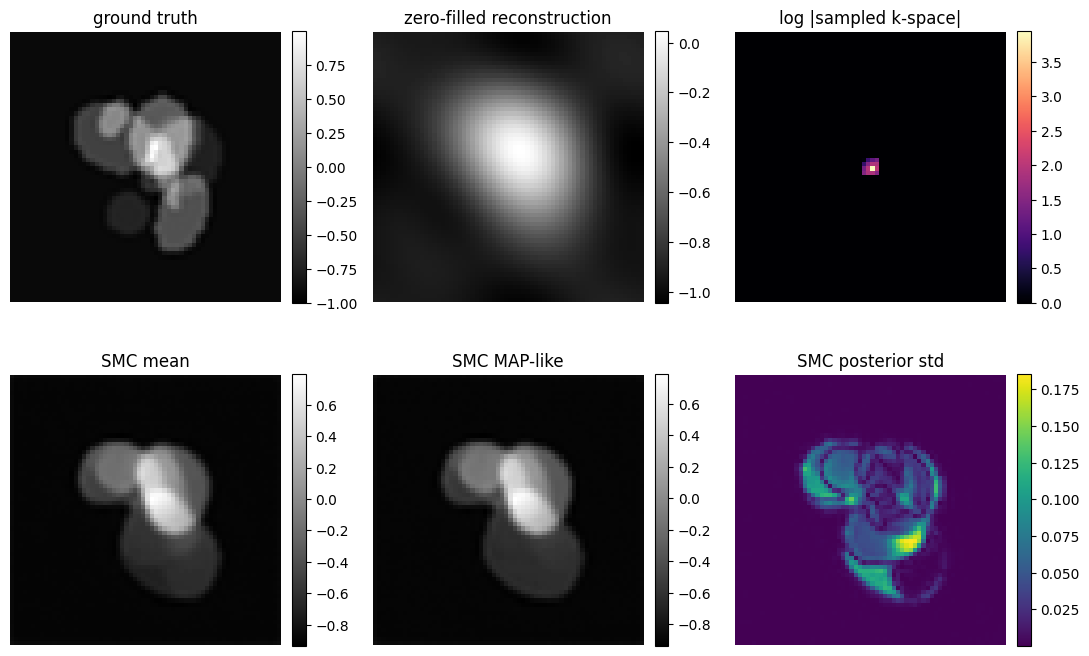

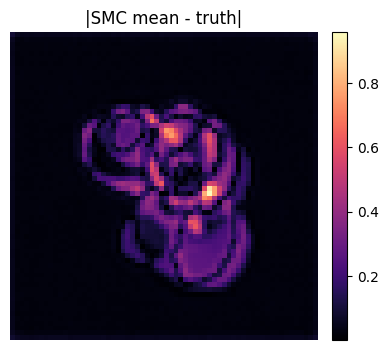

In [18]:
# Visualization: truth, observed fill, and SMC summaries.
smc_std = smc_samples.std(dim=0, keepdim=True)
err_smc = torch.abs(smc_mean - x_true)

with torch.no_grad():
    if OBS_MODE in PHASE_RETRIEVAL_OBS_MODES:
        obs_map = phase_retrieval_to_masked_map(y_obs)
        obs_display_img = torch.log1p(torch.clamp(obs_map, min=0.0))[None, None]
        obs_display_title = "log observed Fourier magnitude"
        obs_display_cmap = "magma"
        baseline_display_title = "zero-phase backprojection"
    elif OBS_MODE in MRI_OBS_MODES:
        obs_display_img = packed_to_masked_kspace(y_obs).abs()[None, None].log1p()
        obs_display_title = "log |sampled k-space|"
        obs_display_cmap = "magma"
        baseline_display_title = "zero-filled reconstruction"
    elif OBS_MODE in SPATIAL_PROJECTION_OBS_MODES:
        obs_display_img = zero_filled_reconstruction(y_obs)
        obs_display_title = "spatial projection observations"
        obs_display_cmap = "magma"
        baseline_display_title = "spatial observed-pixel fill"
    else:
        obs_display_img = zero_filled_reconstruction(y_obs)
        obs_display_title = "observed pixels display"
        obs_display_cmap = "magma"
        baseline_display_title = "observed-pixel fill"

if SHOW_PLOTS or SAVE_FIGURES:
    fig, axes = plt.subplots(2, 3, figsize=(11, 7))
    items = [
        (x_true, "ground truth", "gray"),
        (x_zf, baseline_display_title, "gray"),
        (obs_display_img, obs_display_title, obs_display_cmap),
        (smc_mean, "SMC mean", "gray"),
        (smc_map, "SMC MAP-like", "gray"),
        (smc_std, "SMC posterior std", "viridis"),
    ]
    for ax, (img, title, cmap) in zip(np.asarray(axes).flatten(), items):
        arr = img[0, 0].detach().cpu().numpy()
        im = ax.imshow(arr, cmap=cmap)
        ax.set_title(title)
        ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(OUTPUT_DIR / "singlecoil_smc_only_summary.png", dpi=150, bbox_inches="tight")
    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close(fig)

if SHOW_PLOTS or SAVE_FIGURES:
    fig, ax = plt.subplots(figsize=(4.5, 4))
    arr = err_smc[0, 0].detach().cpu().numpy()
    im = ax.imshow(arr, cmap="magma")
    ax.set_title("|SMC mean - truth|")
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    if SAVE_FIGURES:
        fig.savefig(OUTPUT_DIR / "singlecoil_smc_only_abs_error.png", dpi=150, bbox_inches="tight")
    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close(fig)


NUM_MAP_PARTICLES: 5
MAP_UNIQUENESS_MODE: ancestor
MAP_DISTINCT_ATOL: 1e-07
REPEAT_TOP_MAP_IF_SINGLE_UNIQUE_ANCESTOR: True

SMC LEVEL 1
level 1 samples                  shape=(256, 1, 64, 64) min=-0.91734 max= 0.750795 mean=-0.787738 std= 0.262773
mean RMSE                 : 0.146592
mean MAE                  : 0.0851347
mean PSNR                 : 22.6984
mean SSIM                 : 0.806125
mean obs RMSE             : 0.711618
mean reward               : -202.56
top-1 MAP-like RMSE       : 0.146592
top-1 MAP-like PSNR       : 22.6984
top-1 MAP-like SSIM       : 0.806124
top-1 MAP-like obs RMSE   : 0.711618
top-1 MAP-like reward     : -202.56
posterior std mean        : 0
posterior std max         : 0
uncertainty-error corr    : 0
95% pixel coverage        : 0
95% avg interval width    : 0
ESS                       : 1
ESS/N                     : 0.00390625
unique selected ancestors : 1/256
distinct MAP displayed    : 5 (distinct returned=1, unique available=1, repeated_single_unique=

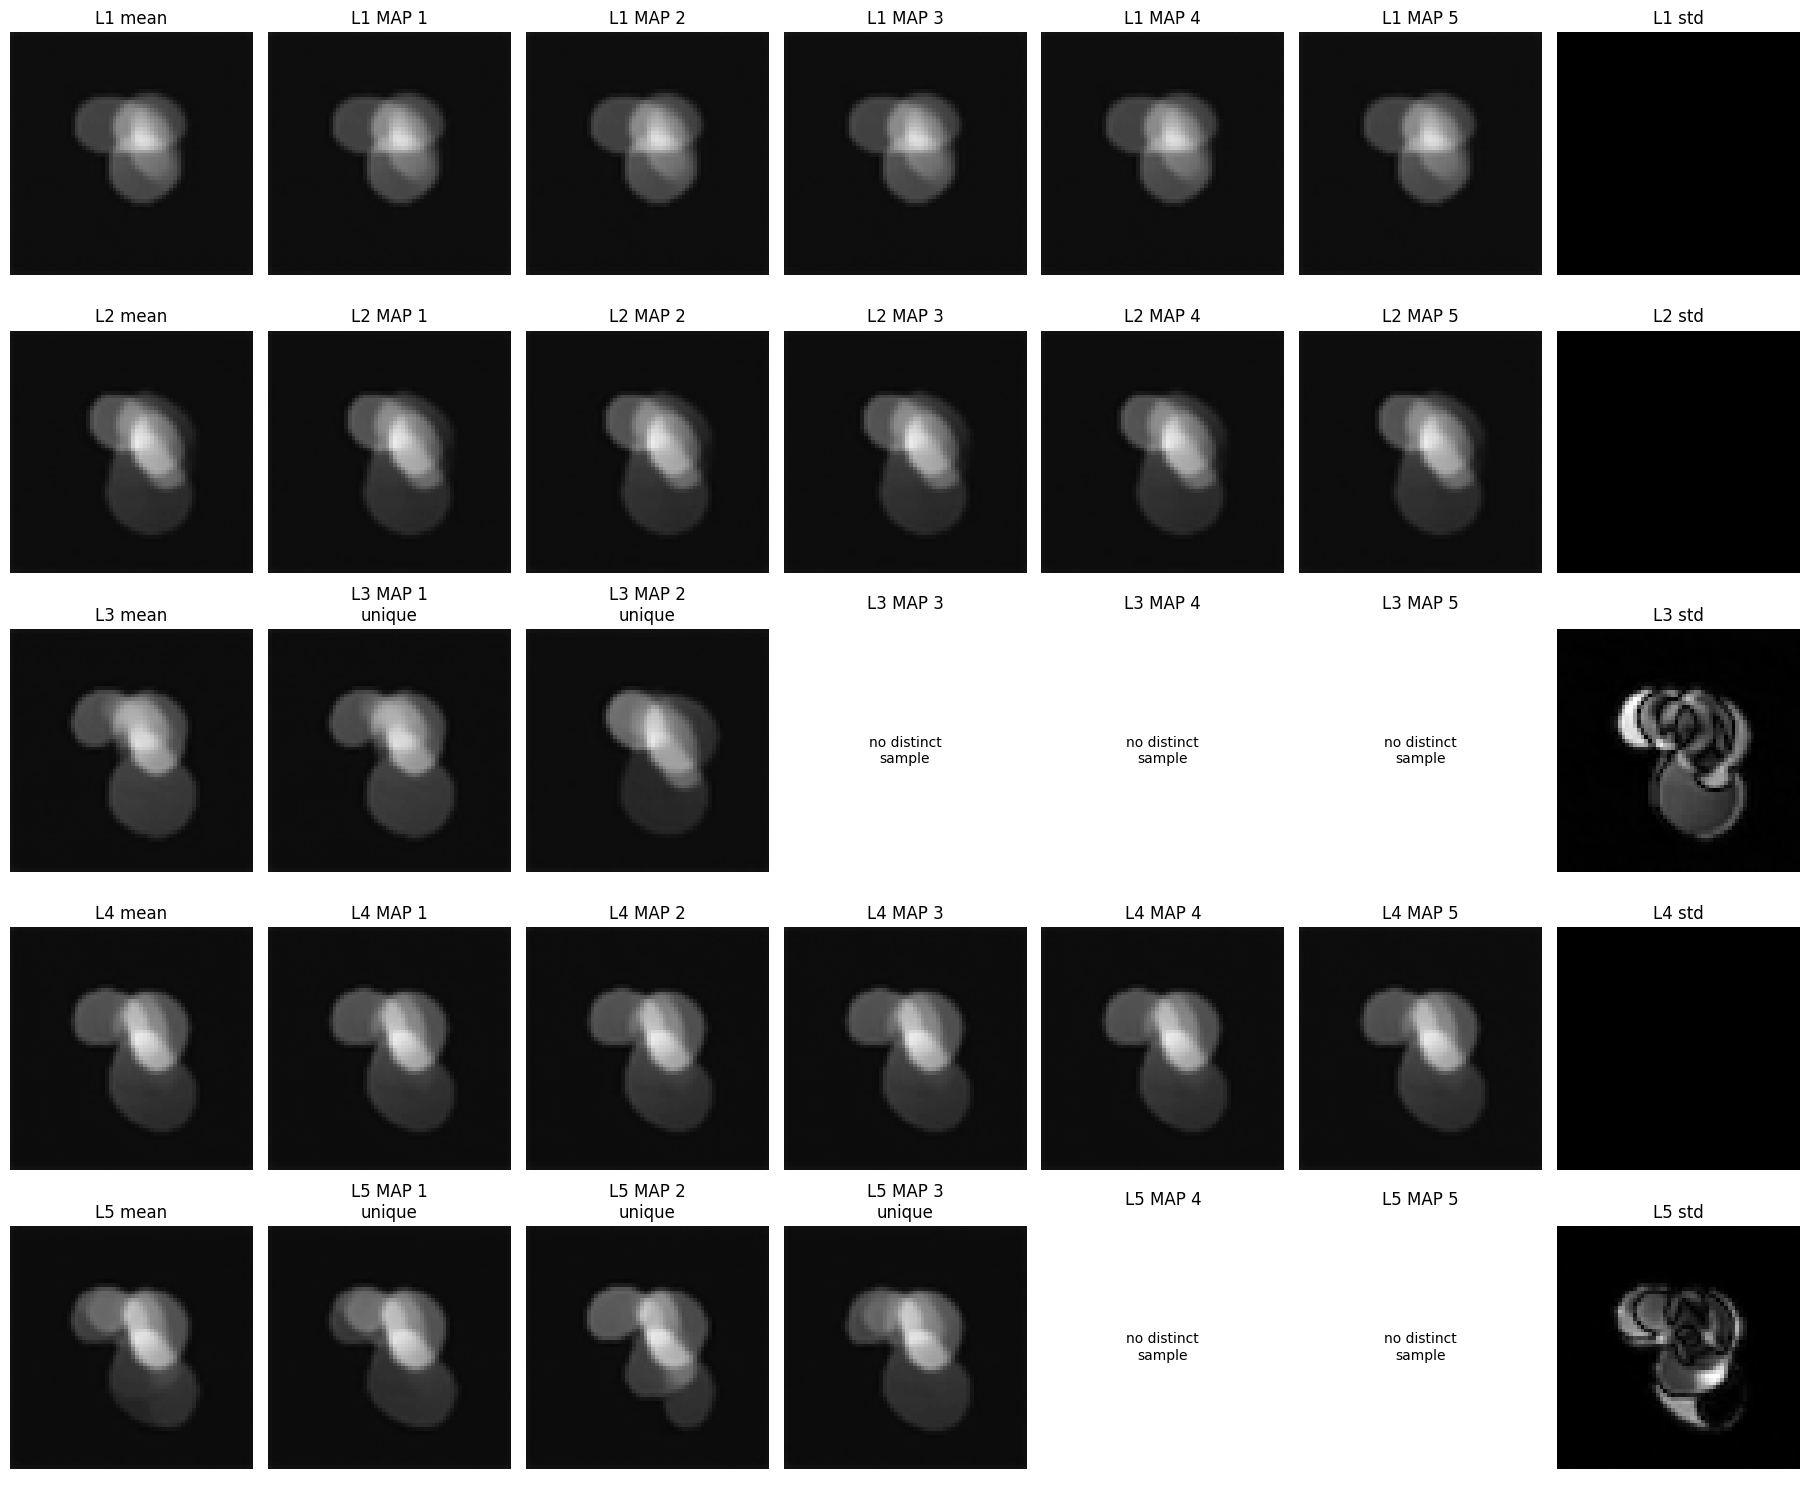

saved low-pass IFFT distinct top-k MAP plot to: singlecoil_mri_tuolumne_outputs/smc_level_1_top5_distinct_map_lowpass_ifft_4x4_8x8_16x16.png


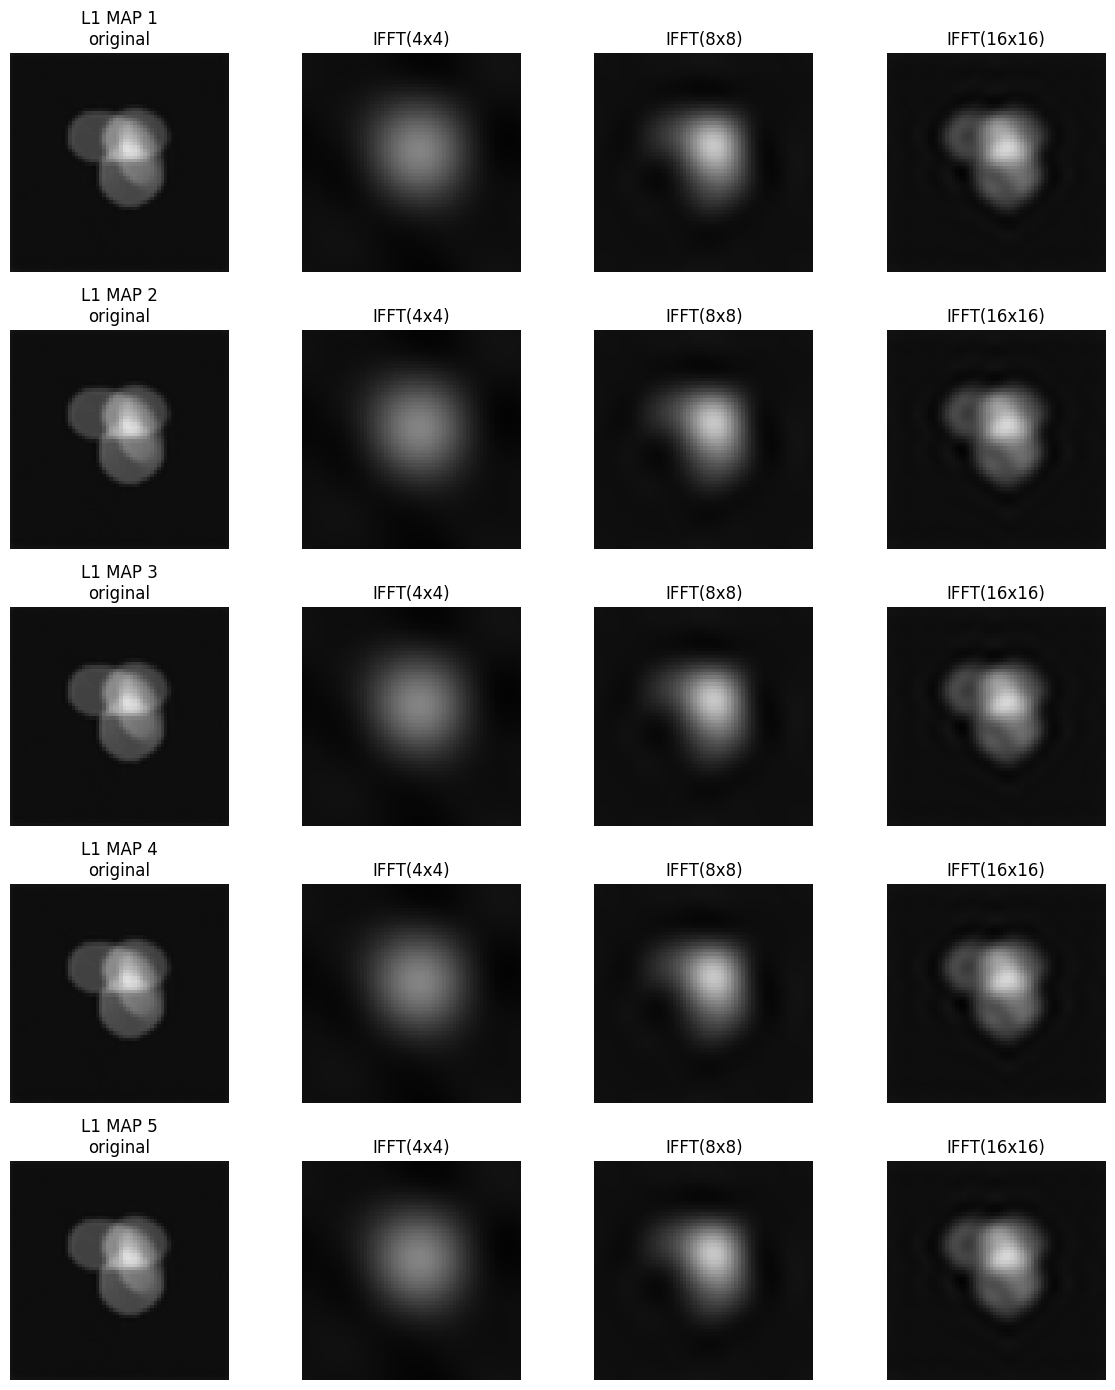

saved low-pass IFFT distinct top-k MAP plot to: singlecoil_mri_tuolumne_outputs/smc_level_2_top5_distinct_map_lowpass_ifft_4x4_8x8_16x16.png


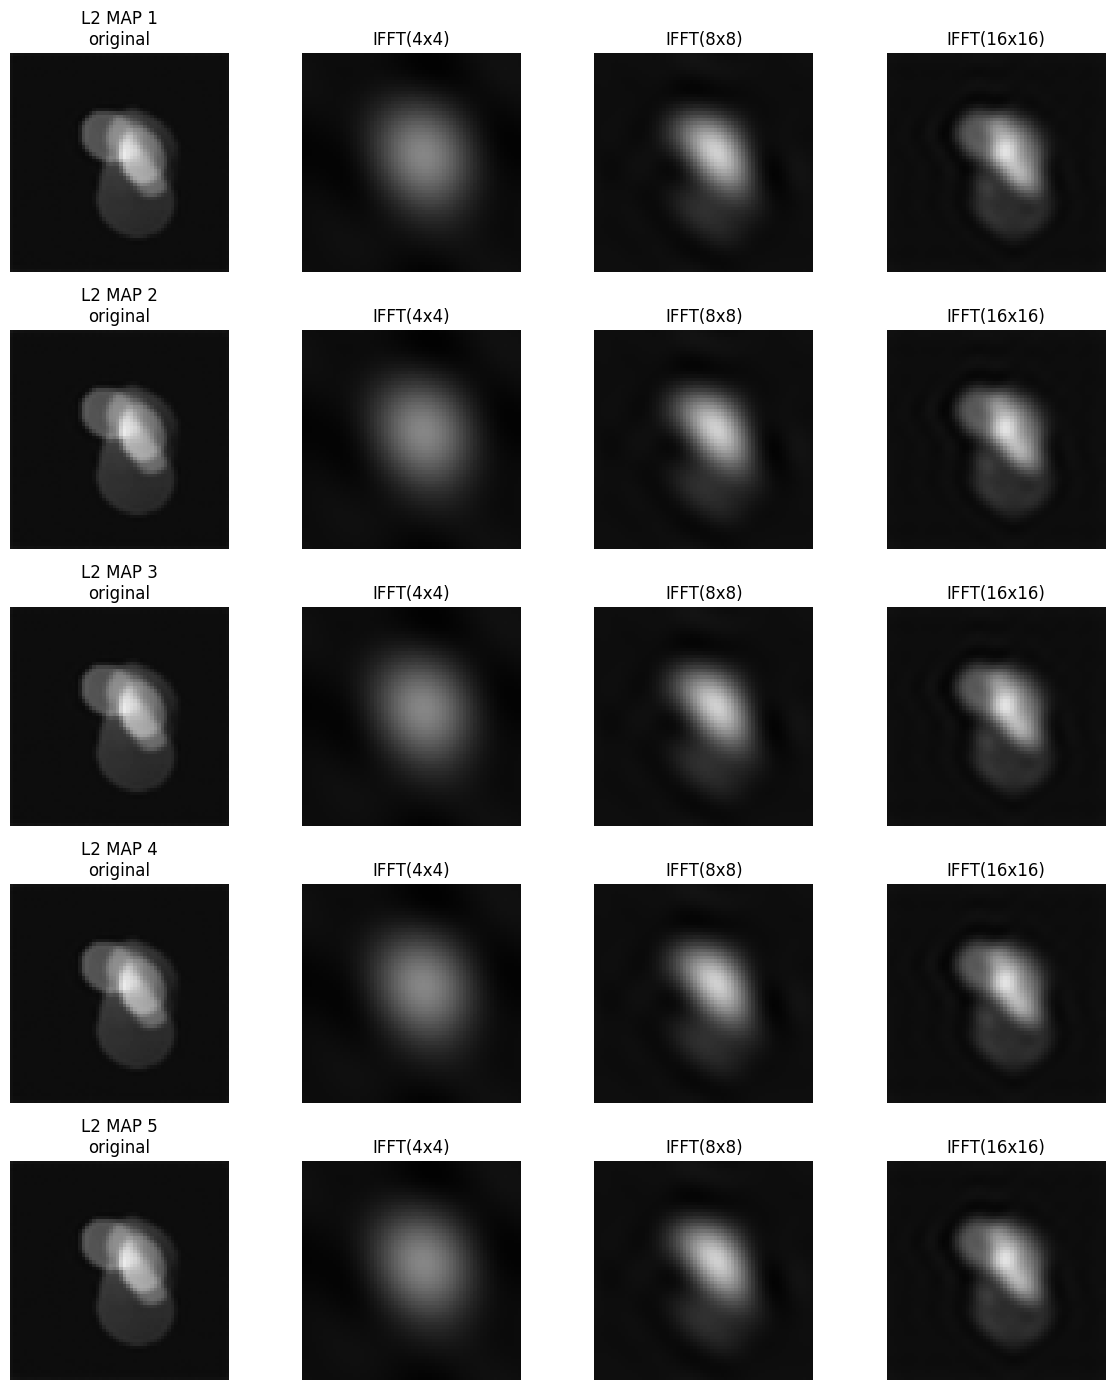

saved low-pass IFFT distinct top-k MAP plot to: singlecoil_mri_tuolumne_outputs/smc_level_3_top5_distinct_map_lowpass_ifft_4x4_8x8_16x16.png


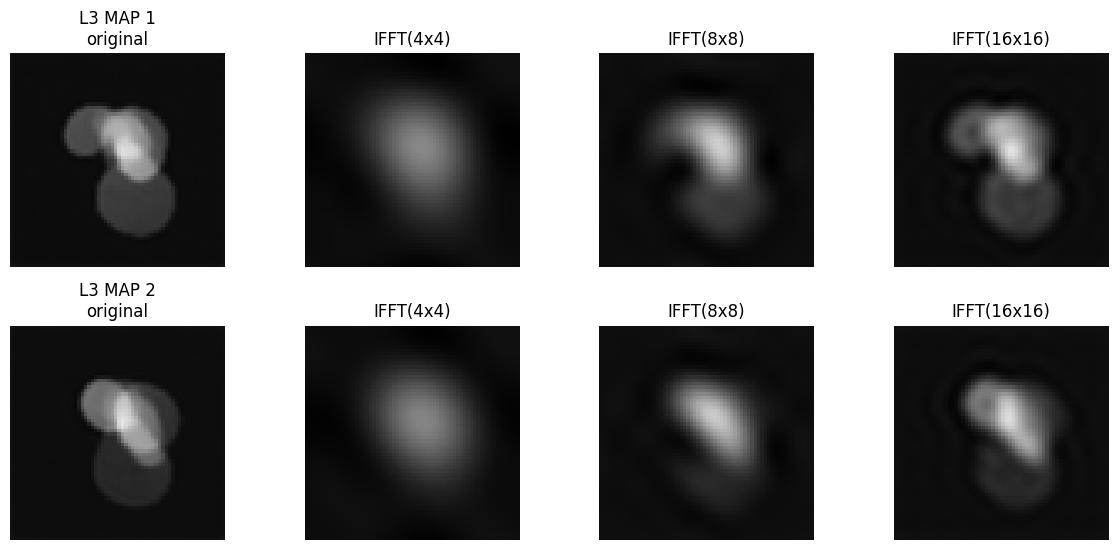

saved low-pass IFFT distinct top-k MAP plot to: singlecoil_mri_tuolumne_outputs/smc_level_4_top5_distinct_map_lowpass_ifft_4x4_8x8_16x16.png


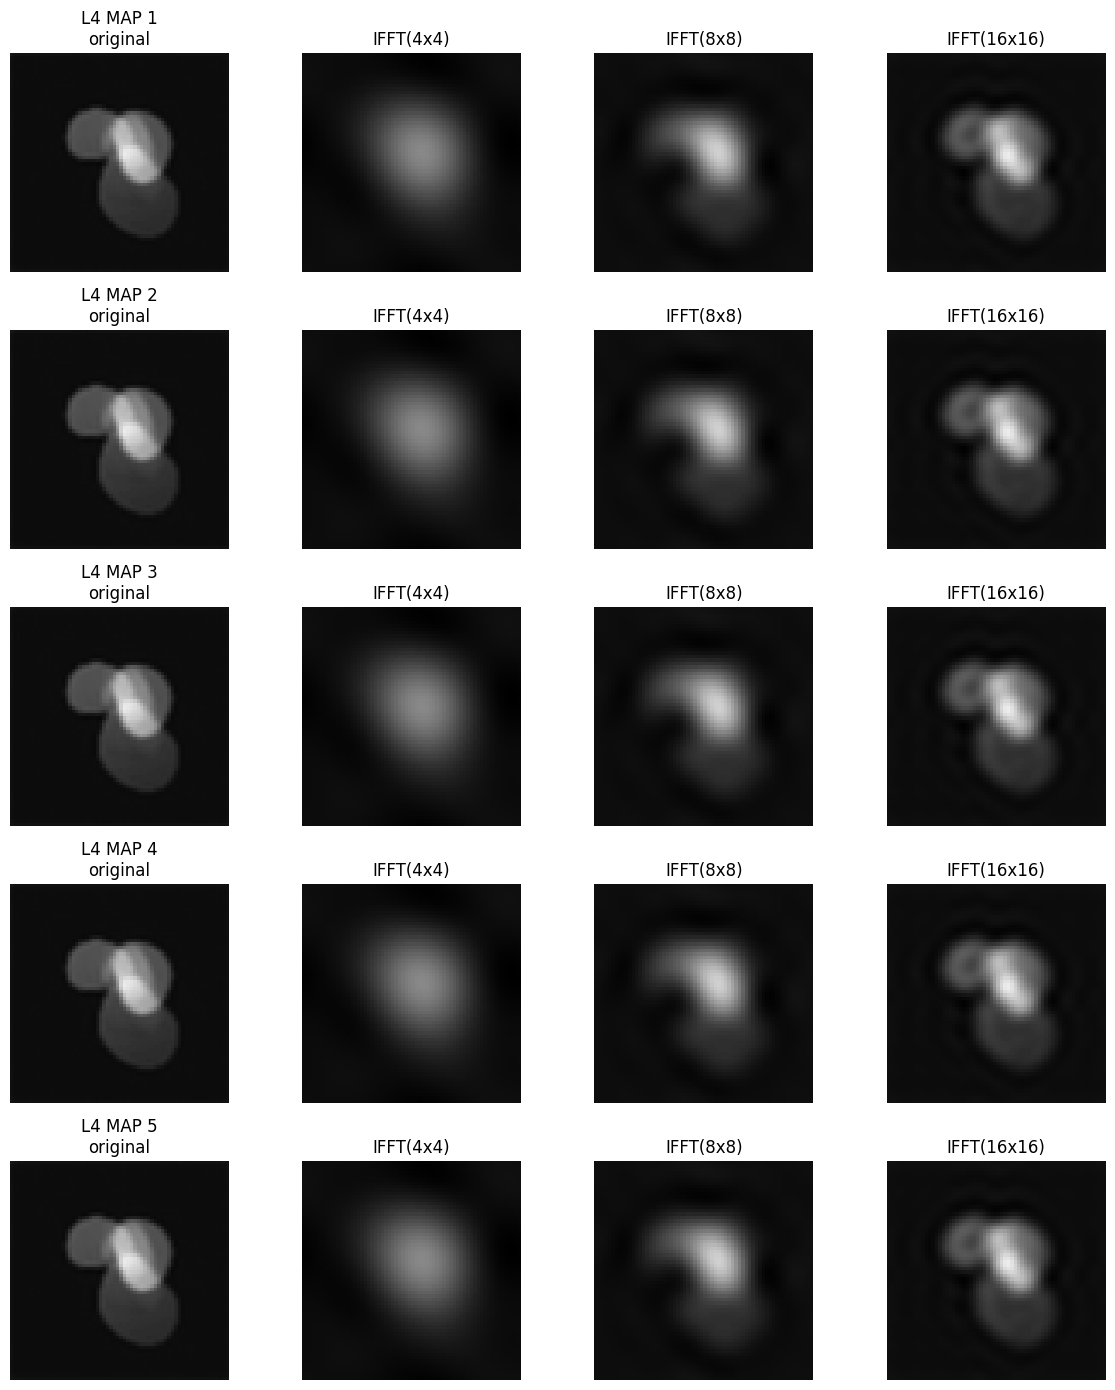

saved low-pass IFFT distinct top-k MAP plot to: singlecoil_mri_tuolumne_outputs/smc_level_5_top5_distinct_map_lowpass_ifft_4x4_8x8_16x16.png


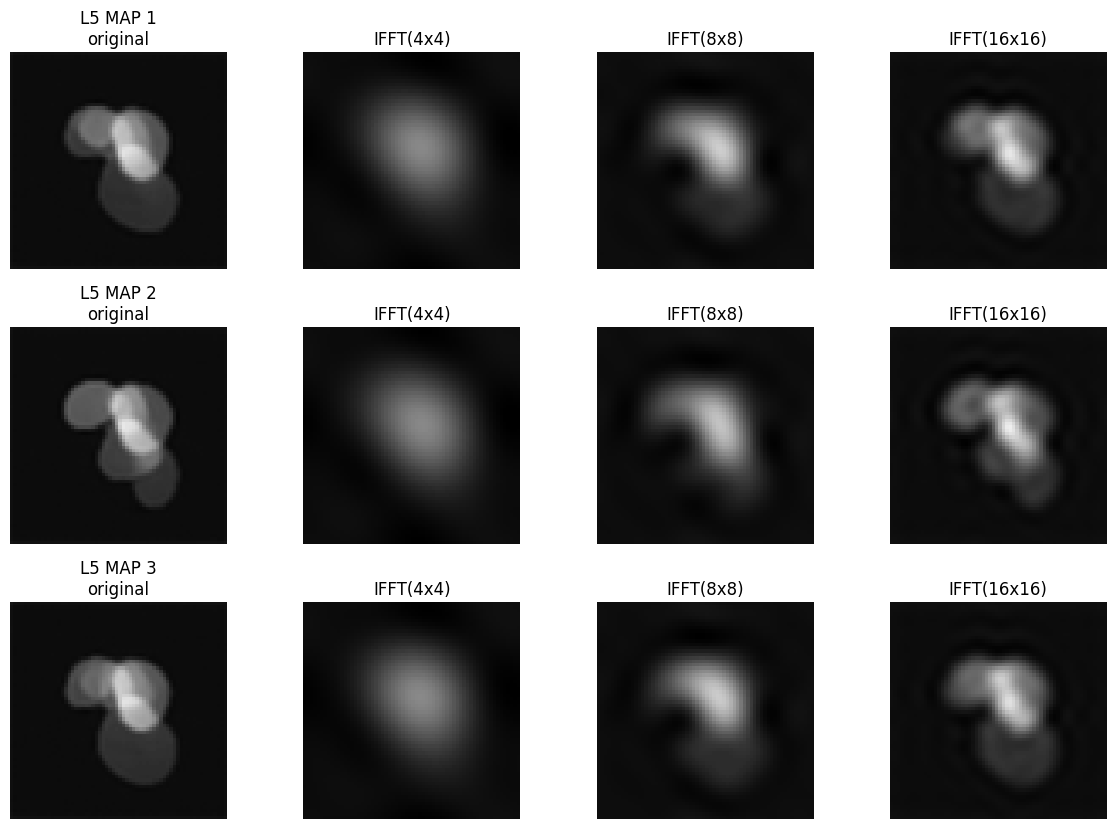

In [19]:
# ============================================================
# Per-level SMC diagnostics table and plots: DISTINCT top-k MAP particles
# ============================================================
# Paste/run this after the SMC run.
#
# Behavior:
#   * ranks MAP-like particles by reward_mri_value_chunked(samples);
#   * when smc_out["idx_by_level"] is available, keeps at most one particle
#     from each unique SMC ancestor;
#   * repeats the same MAP particle up to NUM_MAP_PARTICLES ONLY when the
#     level has exactly one unique ancestor;
#   * if there are 2, 3, or 4 unique ancestors, it shows 2, 3, or 4 distinct
#     MAP particles and leaves the remaining grid slots blank;
#   * for MRI FFT, each displayed MAP particle is also shown through low-pass
#     zero-filled IFFT previews for LOWPASS_SQUARE_SIZES, e.g. 4x4, 8x8, 16x16.

import os
import math
import numpy as np
import torch
import torch.nn.functional as F

try:
    import pandas as pd
except Exception:
    pd = None


# -----------------------------
# Basic metric helpers
# -----------------------------
METRIC_DATA_RANGE = float(globals().get("METRIC_DATA_RANGE", 2.0))
NUM_MAP_PARTICLES = (
    env_int("NUM_MAP_PARTICLES", int(globals().get("NUM_MAP_PARTICLES", 5)))
    if "env_int" in globals()
    else int(globals().get("NUM_MAP_PARTICLES", 5))
)

# New controls for distinct MAP displays.
MAP_UNIQUENESS_MODE = (
    env_str("MAP_UNIQUENESS_MODE", str(globals().get("MAP_UNIQUENESS_MODE", "ancestor")))
    if "env_str" in globals()
    else str(globals().get("MAP_UNIQUENESS_MODE", "ancestor"))
).strip().lower()
MAP_DISTINCT_ATOL = (
    env_float("MAP_DISTINCT_ATOL", float(globals().get("MAP_DISTINCT_ATOL", 1e-7)))
    if "env_float" in globals()
    else float(globals().get("MAP_DISTINCT_ATOL", 1e-7))
)
REPEAT_TOP_MAP_IF_SINGLE_UNIQUE_ANCESTOR = (
    env_bool("REPEAT_TOP_MAP_IF_SINGLE_UNIQUE_ANCESTOR", True)
    if "env_bool" in globals()
    else bool(globals().get("REPEAT_TOP_MAP_IF_SINGLE_UNIQUE_ANCESTOR", True))
)

print("NUM_MAP_PARTICLES:", NUM_MAP_PARTICLES)
print("MAP_UNIQUENESS_MODE:", MAP_UNIQUENESS_MODE)
print("MAP_DISTINCT_ATOL:", MAP_DISTINCT_ATOL)
print("REPEAT_TOP_MAP_IF_SINGLE_UNIQUE_ANCESTOR:", REPEAT_TOP_MAP_IF_SINGLE_UNIQUE_ANCESTOR)


def _as_float(x):
    if torch.is_tensor(x):
        return float(x.detach().cpu())
    return float(x)


@torch.no_grad()
def tensor_summary(name: str, x: torch.Tensor):
    xd = x.detach()
    print(
        f"{name:32s} shape={tuple(xd.shape)} "
        f"min={float(xd.min()): .6g} "
        f"max={float(xd.max()): .6g} "
        f"mean={float(xd.mean()): .6g} "
        f"std={float(xd.std()): .6g}"
    )


@torch.no_grad()
def rmse_img(x: torch.Tensor, y: torch.Tensor) -> float:
    return float(torch.sqrt(torch.mean((x - y) ** 2)).detach().cpu())


@torch.no_grad()
def mae_img(x: torch.Tensor, y: torch.Tensor) -> float:
    return float(torch.mean(torch.abs(x - y)).detach().cpu())


@torch.no_grad()
def psnr_img(x: torch.Tensor, y: torch.Tensor, data_range: float = METRIC_DATA_RANGE) -> float:
    r = rmse_img(x, y)
    return float(20.0 * math.log10(float(data_range) / max(r, 1e-12)))


@torch.no_grad()
def ssim_img(x: torch.Tensor, y: torch.Tensor, window: int = 7, data_range: float = METRIC_DATA_RANGE) -> float:
    """Simple local SSIM for tensors shaped (1,1,H,W), (N,1,H,W), or (1,H,W)."""
    if x.ndim == 3:
        x = x[None]
    if y.ndim == 3:
        y = y[None]

    C1 = (0.01 * data_range) ** 2
    C2 = (0.03 * data_range) ** 2
    pad = window // 2

    mux = F.avg_pool2d(x, window, stride=1, padding=pad)
    muy = F.avg_pool2d(y, window, stride=1, padding=pad)

    vx = F.avg_pool2d(x * x, window, stride=1, padding=pad) - mux * mux
    vy = F.avg_pool2d(y * y, window, stride=1, padding=pad) - muy * muy
    vxy = F.avg_pool2d(x * y, window, stride=1, padding=pad) - mux * muy

    ssim_map = ((2 * mux * muy + C1) * (2 * vxy + C2)) / (
        (mux * mux + muy * muy + C1) * (vx + vy + C2)
    )
    return float(ssim_map.mean().detach().cpu())


@torch.no_grad()
def obs_rmse_img(x_model: torch.Tensor) -> float:
    hx_mean = observation_mean_torch(x_model)
    return float(torch.sqrt(torch.mean((hx_mean - y_obs[None, :]) ** 2)).detach().cpu())


@torch.no_grad()
def uncertainty_metrics_for_samples(samples: torch.Tensor, mean_est: torch.Tensor, truth: torch.Tensor):
    std = samples.std(dim=0, keepdim=True, unbiased=False)
    abs_err = torch.abs(mean_est - truth)

    sf = std.flatten()
    ef = abs_err.flatten()

    corr = torch.sum((sf - sf.mean()) * (ef - ef.mean())) / (
        torch.sqrt(torch.sum((sf - sf.mean()) ** 2)) *
        torch.sqrt(torch.sum((ef - ef.mean()) ** 2)) +
        1e-12
    )

    q025 = torch.quantile(samples, 0.025, dim=0, keepdim=True)
    q975 = torch.quantile(samples, 0.975, dim=0, keepdim=True)

    coverage = ((truth >= q025) & (truth <= q975)).float().mean()
    width = (q975 - q025).mean()

    return {
        "std_mean": float(std.mean().detach().cpu()),
        "std_max": float(std.max().detach().cpu()),
        "uncertainty_error_corr": float(corr.detach().cpu()),
        "coverage_95": float(coverage.detach().cpu()),
        "avg_width_95": float(width.detach().cpu()),
    }


# -----------------------------
# Distinct MAP selection helpers
# -----------------------------
@torch.no_grad()
def _sample_content_key(x: torch.Tensor, atol: float = MAP_DISTINCT_ATOL):
    """Hash a sample tensor so identical or near-identical images are treated as duplicates."""
    arr = x.detach().cpu().reshape(-1).numpy()

    if atol is not None and float(atol) > 0:
        arr = np.round(arr / float(atol)).astype(np.int64)
    else:
        arr = arr.astype(np.float32)

    return arr.tobytes()


def _to_numpy_1d(x):
    if x is None:
        return None
    if torch.is_tensor(x):
        return x.detach().cpu().numpy().reshape(-1)
    return np.asarray(x).reshape(-1)


def _prepare_ancestor_ids(ancestor_ids, n: int):
    """Return ancestor ids as a flat numpy array, or None if unavailable/mismatched."""
    if ancestor_ids is None:
        return None

    arr = _to_numpy_1d(ancestor_ids)

    if len(arr) != int(n):
        print(
            "WARNING: ancestor_ids length does not match sample count; "
            f"got len={len(arr)}, n={n}. Falling back to sample-content uniqueness."
        )
        return None

    return arr


@torch.no_grad()
def _topk_map_particles(
    samples_model: torch.Tensor,
    num_map_particles: int = NUM_MAP_PARTICLES,
    ancestor_ids=None,
):
    """Return MAP-like particles sorted by reward, avoiding duplicates.

    Main rule:
        If ancestor_ids are available, choose at most one MAP particle per unique ancestor.

    Repetition rule:
        Repeat the same sample up to NUM_MAP_PARTICLES only if there is exactly
        one unique ancestor/sample.

    If there are 2, 3, or 4 unique ancestors, this returns only 2, 3, or 4
    distinct samples. It does not duplicate to fill 5.
    """
    samples_model = samples_model.detach().to(DEVICE)

    rewards_raw = reward_mri_value_chunked(samples_model).detach()
    rewards = rewards_raw.reshape(samples_model.shape[0], -1).mean(dim=1)

    n = int(samples_model.shape[0])
    if n <= 0:
        raise ValueError("Cannot choose MAP particles from an empty sample cloud.")

    target_k = max(1, int(num_map_particles))
    order = torch.argsort(rewards, descending=True)

    ancestor_np = _prepare_ancestor_ids(ancestor_ids, n)

    chosen_indices = []
    chosen_keys = []

    # Prefer unique ancestors if available.
    if ancestor_np is not None and MAP_UNIQUENESS_MODE in {"ancestor", "auto"}:
        unique_ancestors = np.unique(ancestor_np)
        num_unique = int(len(unique_ancestors))

        # Only case where we intentionally repeat the same MAP sample.
        if num_unique == 1 and REPEAT_TOP_MAP_IF_SINGLE_UNIQUE_ANCESTOR:
            best_idx = int(order[0].detach().cpu())
            top_indices = torch.full(
                (target_k,),
                best_idx,
                dtype=torch.long,
                device=samples_model.device,
            )
            top_rewards = rewards[top_indices]
            top_maps = samples_model[top_indices]

            meta = {
                "uniqueness_mode": "ancestor",
                "num_unique_available": 1,
                "num_distinct_returned": 1,
                "num_displayed": int(target_k),
                "repeated_single_unique": True,
                "unique_keys": [int(unique_ancestors[0])],
            }
            return top_rewards, top_indices, top_maps, meta

        seen_ancestors = set()
        seen_sample_keys = set()

        for idx_t in order:
            idx = int(idx_t.detach().cpu())
            anc = int(ancestor_np[idx])

            if anc in seen_ancestors:
                continue

            # Also require different sample content, so different ancestors that
            # collapsed to the exact same image do not both appear in the MAP grid.
            sample_key = _sample_content_key(samples_model[idx], atol=MAP_DISTINCT_ATOL)
            if sample_key in seen_sample_keys:
                continue

            seen_ancestors.add(anc)
            seen_sample_keys.add(sample_key)
            chosen_indices.append(idx)
            chosen_keys.append(anc)

            if len(chosen_indices) >= target_k:
                break

        if len(chosen_indices) == 0:
            chosen_indices = [int(order[0].detach().cpu())]
            chosen_keys = [int(ancestor_np[chosen_indices[0]])]

        top_indices = torch.as_tensor(
            chosen_indices,
            dtype=torch.long,
            device=samples_model.device,
        )
        top_rewards = rewards[top_indices]
        top_maps = samples_model[top_indices]

        meta = {
            "uniqueness_mode": "ancestor",
            "num_unique_available": num_unique,
            "num_distinct_returned": int(len(chosen_indices)),
            "num_displayed": int(len(chosen_indices)),
            "repeated_single_unique": False,
            "unique_keys": chosen_keys,
        }
        return top_rewards, top_indices, top_maps, meta

    # Fallback: unique by actual sample content.
    seen_samples = set()

    for idx_t in order:
        idx = int(idx_t.detach().cpu())
        key = _sample_content_key(samples_model[idx], atol=MAP_DISTINCT_ATOL)

        if key in seen_samples:
            continue

        seen_samples.add(key)
        chosen_indices.append(idx)
        chosen_keys.append(idx)

        if len(chosen_indices) >= target_k:
            break

    num_unique_samples = int(len(chosen_indices))

    if num_unique_samples == 1 and REPEAT_TOP_MAP_IF_SINGLE_UNIQUE_ANCESTOR:
        best_idx = int(chosen_indices[0])
        top_indices = torch.full(
            (target_k,),
            best_idx,
            dtype=torch.long,
            device=samples_model.device,
        )
        top_rewards = rewards[top_indices]
        top_maps = samples_model[top_indices]

        meta = {
            "uniqueness_mode": "sample_content",
            "num_unique_available": 1,
            "num_distinct_returned": 1,
            "num_displayed": int(target_k),
            "repeated_single_unique": True,
            "unique_keys": chosen_keys,
        }
        return top_rewards, top_indices, top_maps, meta

    top_indices = torch.as_tensor(
        chosen_indices,
        dtype=torch.long,
        device=samples_model.device,
    )
    top_rewards = rewards[top_indices]
    top_maps = samples_model[top_indices]

    meta = {
        "uniqueness_mode": "sample_content",
        "num_unique_available": num_unique_samples,
        "num_distinct_returned": num_unique_samples,
        "num_displayed": num_unique_samples,
        "repeated_single_unique": False,
        "unique_keys": chosen_keys,
    }
    return top_rewards, top_indices, top_maps, meta


@torch.no_grad()
def evaluate_smc_level_samples(
    samples_model: torch.Tensor,
    level_index: int,
    num_map_particles: int = NUM_MAP_PARTICLES,
    ancestor_ids=None,
):
    """Evaluate one SMC level sample cloud and return distinct top MAP-like particles."""
    level_num = int(level_index) + 1

    samples_model = samples_model.detach().to(DEVICE)
    truth = x_true.detach().to(DEVICE)

    mean_model = samples_model.mean(dim=0, keepdim=True)

    top_rewards, top_indices, top_maps, top_meta = _topk_map_particles(
        samples_model,
        num_map_particles=num_map_particles,
        ancestor_ids=ancestor_ids,
    )

    map_model = top_maps[0:1]
    map_idx = int(top_indices[0].detach().cpu())

    um = uncertainty_metrics_for_samples(samples_model, mean_model, truth)

    row = {
        "level": level_num,
        "N": int(samples_model.shape[0]),

        "mean_RMSE": rmse_img(mean_model, truth),
        "mean_MAE": mae_img(mean_model, truth),
        "mean_PSNR": psnr_img(mean_model, truth),
        "mean_SSIM": ssim_img(mean_model, truth),
        "mean_obs_RMSE": obs_rmse_img(mean_model),
        "mean_reward": float(
            reward_mri_value_chunked(mean_model).detach().reshape(-1).mean().cpu()
        ),

        # Backward-compatible MAP_* columns remain the top-1 MAP-like particle.
        "MAP_RMSE": rmse_img(map_model, truth),
        "MAP_MAE": mae_img(map_model, truth),
        "MAP_PSNR": psnr_img(map_model, truth),
        "MAP_SSIM": ssim_img(map_model, truth),
        "MAP_obs_RMSE": obs_rmse_img(map_model),
        "MAP_reward": float(top_rewards[0].detach().cpu()),

        "std_mean": um["std_mean"],
        "std_max": um["std_max"],
        "uncertainty_error_corr": um["uncertainty_error_corr"],
        "coverage_95": um["coverage_95"],
        "avg_width_95": um["avg_width_95"],

        "MAP_index": map_idx,
        "MAP_topk_indices": ",".join(str(int(i)) for i in top_indices.detach().cpu().tolist()),
        "MAP_topk_rewards": ",".join(f"{float(v):.10g}" for v in top_rewards.detach().cpu().tolist()),

        # New fields.
        "MAP_uniqueness_mode": top_meta["uniqueness_mode"],
        "MAP_num_unique_available": int(top_meta["num_unique_available"]),
        "MAP_num_distinct_returned": int(top_meta["num_distinct_returned"]),
        "MAP_num_displayed": int(top_meta["num_displayed"]),
        "MAP_repeated_single_unique": bool(top_meta["repeated_single_unique"]),
    }

    ancestor_np = _prepare_ancestor_ids(ancestor_ids, int(samples_model.shape[0]))

    map_rows = []
    for rank in range(int(top_maps.shape[0])):
        particle_idx = int(top_indices[rank].detach().cpu())
        particle = top_maps[rank:rank + 1]

        mr = {
            "level": level_num,
            "map_rank": rank + 1,
            "particle_index": particle_idx,
            "reward": float(top_rewards[rank].detach().cpu()),
            "RMSE": rmse_img(particle, truth),
            "MAE": mae_img(particle, truth),
            "PSNR": psnr_img(particle, truth),
            "SSIM": ssim_img(particle, truth),
            "obs_RMSE": obs_rmse_img(particle),
            "repeated_single_unique": bool(top_meta["repeated_single_unique"]),
        }

        if ancestor_np is not None and particle_idx < len(ancestor_np):
            mr["ancestor_id"] = int(ancestor_np[particle_idx])

        map_rows.append(mr)

    return (
        row,
        map_rows,
        mean_model.detach().cpu(),
        top_maps.detach().cpu(),
        samples_model.std(dim=0, keepdim=True, unbiased=False).detach().cpu(),
    )


# -----------------------------
# Build per-level table
# -----------------------------
assert "samples_by_level" in smc_out, (
    "smc_out does not contain samples_by_level. "
    "Your run_multilevel_smc_scoreprior function must append terminal samples at every level."
)

level_rows = []
top_map_rows = []
level_means = []
level_maps = []        # top-1 only, for compatibility
level_top_maps = []    # list of tensors; each tensor is (K_level,1,H,W), not always K=5
level_stds = []

for ell, samples_ell in enumerate(smc_out["samples_by_level"]):

    # Use SMC ancestor ids for distinct MAP selection whenever available.
    idx_ell = None
    if "idx_by_level" in smc_out and len(smc_out["idx_by_level"]) > ell:
        idx_ell = smc_out["idx_by_level"][ell]

    row, map_rows_ell, mean_ell, top_maps_ell, std_ell = evaluate_smc_level_samples(
        samples_ell,
        ell,
        num_map_particles=NUM_MAP_PARTICLES,
        ancestor_ids=idx_ell,
    )

    if "ess" in smc_out:
        row["ESS"] = float(np.asarray(smc_out["ess"])[ell])
        row["ESS_frac"] = row["ESS"] / max(row["N"], 1)

    if "population" in smc_out:
        row["population"] = int(np.asarray(smc_out["population"])[ell])

    if idx_ell is not None:
        idx_np = _to_numpy_1d(idx_ell)
        row["unique_ancestors"] = int(len(np.unique(idx_np)))

    level_rows.append(row)
    top_map_rows.extend(map_rows_ell)
    level_means.append(mean_ell)
    level_maps.append(top_maps_ell[0:1])
    level_top_maps.append(top_maps_ell)
    level_stds.append(std_ell)

    print("\n" + "=" * 80)
    print(f"SMC LEVEL {ell + 1}")
    print("=" * 80)
    tensor_summary(f"level {ell + 1} samples", samples_ell)
    print(f"mean RMSE                 : {row['mean_RMSE']:.6g}")
    print(f"mean MAE                  : {row['mean_MAE']:.6g}")
    print(f"mean PSNR                 : {row['mean_PSNR']:.6g}")
    print(f"mean SSIM                 : {row['mean_SSIM']:.6g}")
    print(f"mean obs RMSE             : {row['mean_obs_RMSE']:.6g}")
    print(f"mean reward               : {row['mean_reward']:.6g}")
    print(f"top-1 MAP-like RMSE       : {row['MAP_RMSE']:.6g}")
    print(f"top-1 MAP-like PSNR       : {row['MAP_PSNR']:.6g}")
    print(f"top-1 MAP-like SSIM       : {row['MAP_SSIM']:.6g}")
    print(f"top-1 MAP-like obs RMSE   : {row['MAP_obs_RMSE']:.6g}")
    print(f"top-1 MAP-like reward     : {row['MAP_reward']:.6g}")
    print(f"posterior std mean        : {row['std_mean']:.6g}")
    print(f"posterior std max         : {row['std_max']:.6g}")
    print(f"uncertainty-error corr    : {row['uncertainty_error_corr']:.6g}")
    print(f"95% pixel coverage        : {row['coverage_95']:.6g}")
    print(f"95% avg interval width    : {row['avg_width_95']:.6g}")
    if "ESS" in row:
        print(f"ESS                       : {row['ESS']:.6g}")
        print(f"ESS/N                     : {row['ESS_frac']:.6g}")
    if "unique_ancestors" in row:
        print(f"unique selected ancestors : {row['unique_ancestors']}/{row['N']}")
    print(
        f"distinct MAP displayed    : {row['MAP_num_displayed']} "
        f"(distinct returned={row['MAP_num_distinct_returned']}, "
        f"unique available={row['MAP_num_unique_available']}, "
        f"repeated_single_unique={row['MAP_repeated_single_unique']})"
    )

    print(f"\nTop MAP-like particles at this level:")
    for mr in map_rows_ell:
        anc_txt = f" | ancestor={mr['ancestor_id']:6d}" if "ancestor_id" in mr else ""
        print(
            f"  rank {mr['map_rank']:2d} | "
            f"particle {mr['particle_index']:6d}{anc_txt} | "
            f"reward={mr['reward']:.6g} | "
            f"RMSE={mr['RMSE']:.6g} | "
            f"PSNR={mr['PSNR']:.6g} | "
            f"SSIM={mr['SSIM']:.6g} | "
            f"obs_RMSE={mr['obs_RMSE']:.6g} | "
            f"repeat_single={mr['repeated_single_unique']}"
        )


# -----------------------------
# Compact tables
# -----------------------------
if pd is not None:
    smc_level_df = pd.DataFrame(level_rows)
    smc_top_map_df = pd.DataFrame(top_map_rows)

    display_cols = [
        "level", "N", "ESS", "ESS_frac", "unique_ancestors",
        "mean_RMSE", "mean_PSNR", "mean_SSIM", "mean_obs_RMSE", "mean_reward",
        "MAP_RMSE", "MAP_PSNR", "MAP_SSIM", "MAP_obs_RMSE", "MAP_reward",
        "MAP_num_unique_available", "MAP_num_distinct_returned", "MAP_num_displayed",
        "MAP_repeated_single_unique", "MAP_uniqueness_mode",
        "std_mean", "std_max", "coverage_95", "avg_width_95", "uncertainty_error_corr",
        "MAP_topk_indices", "MAP_topk_rewards",
    ]
    display_cols = [c for c in display_cols if c in smc_level_df.columns]

    print("\n" + "=" * 80)
    print("PER-LEVEL SMC METRIC TABLE")
    print("=" * 80)
    try:
        from IPython.display import display
        display(smc_level_df[display_cols])
    except Exception:
        print(smc_level_df[display_cols].to_string(index=False))

    top_map_display_cols = [
        "level", "map_rank", "particle_index", "ancestor_id", "reward",
        "RMSE", "MAE", "PSNR", "SSIM", "obs_RMSE", "repeated_single_unique",
    ]
    top_map_display_cols = [c for c in top_map_display_cols if c in smc_top_map_df.columns]

    print("\n" + "=" * 80)
    print(f"DISTINCT TOP MAP-LIKE PARTICLES PER SMC LEVEL")
    print("=" * 80)
    try:
        from IPython.display import display
        display(smc_top_map_df[top_map_display_cols])
    except Exception:
        print(smc_top_map_df[top_map_display_cols].to_string(index=False))

    if "OUTPUT_DIR" in globals():
        os.makedirs(OUTPUT_DIR, exist_ok=True)
        csv_path = os.path.join(OUTPUT_DIR, "smc_per_level_metrics.csv")
        top_map_csv_path = os.path.join(OUTPUT_DIR, f"smc_top{NUM_MAP_PARTICLES}_distinct_map_particles_by_level.csv")
        smc_level_df.to_csv(csv_path, index=False)
        smc_top_map_df.to_csv(top_map_csv_path, index=False)
        print("saved per-level metrics to:", csv_path)
        print("saved distinct top-k MAP-like particle table to:", top_map_csv_path)
else:
    smc_level_df = None
    smc_top_map_df = None
    print("\nPandas is not available; level_rows and top_map_rows contain the per-level dictionaries.")
    for row in level_rows:
        print(row)


# -----------------------------
# Save top-k tensors
# -----------------------------
if "OUTPUT_DIR" in globals():
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    top_map_pt_path = os.path.join(OUTPUT_DIR, f"smc_top{NUM_MAP_PARTICLES}_distinct_map_particles_by_level.pt")
    torch.save(
        {
            "num_map_particles_requested": int(NUM_MAP_PARTICLES),
            "level_top_maps": level_top_maps,
            "top_map_rows": top_map_rows,
            "level_rows": level_rows,
            "lowpass_square_sizes": list(globals().get("LOWPASS_SQUARE_SIZES", [4, 8, 16])),
            "map_uniqueness_mode": MAP_UNIQUENESS_MODE,
            "repeat_top_map_if_single_unique_ancestor": REPEAT_TOP_MAP_IF_SINGLE_UNIQUE_ANCESTOR,
        },
        top_map_pt_path,
    )
    print("saved distinct top-k MAP-like particle tensors to:", top_map_pt_path)

    try:
        same_k = len(set(int(x.shape[0]) for x in level_top_maps)) == 1
        if same_k:
            top_map_np = torch.stack(level_top_maps, dim=0).numpy()
            top_map_npz_path = os.path.join(OUTPUT_DIR, f"smc_top{NUM_MAP_PARTICLES}_distinct_map_particles_by_level.npz")
            np.savez_compressed(
                top_map_npz_path,
                top_map_particles=top_map_np,
                top_map_rows=np.array(top_map_rows, dtype=object),
                level_rows=np.array(level_rows, dtype=object),
                lowpass_square_sizes=np.asarray(list(globals().get("LOWPASS_SQUARE_SIZES", [4, 8, 16]))),
            )
            print("saved distinct top-k MAP-like particle NumPy archive to:", top_map_npz_path)
        else:
            print("skipped stacked npz save because levels have different numbers of distinct MAP particles")
    except Exception as e:
        print("WARNING: could not save distinct top-k MAP-like particles as npz:", repr(e))


# -----------------------------
# Optional plots: metric curves
# -----------------------------
if globals().get("SHOW_PLOTS", True) and pd is not None and smc_level_df is not None:
    import matplotlib.pyplot as plt

    def plot_metric_curve(col, ylabel=None):
        if col not in smc_level_df.columns:
            return
        plt.figure(figsize=(6, 4))
        plt.plot(smc_level_df["level"], smc_level_df[col], marker="o")
        plt.xlabel("SMC level")
        plt.ylabel(ylabel or col)
        plt.title(col + " across SMC levels")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    for col in [
        "mean_RMSE",
        "mean_PSNR",
        "mean_SSIM",
        "mean_obs_RMSE",
        "mean_reward",
        "MAP_RMSE",
        "MAP_SSIM",
        "std_mean",
        "coverage_95",
        "ESS_frac",
        "MAP_num_distinct_returned",
    ]:
        plot_metric_curve(col)


# -----------------------------
# Optional plots: mean / distinct top-k MAP / std images by level
# -----------------------------
if globals().get("SHOW_PLOTS", True) or globals().get("SAVE_FIGURES", True):
    import matplotlib.pyplot as plt

    def to_np_img(x):
        x = x.detach().cpu()
        if x.ndim == 4:
            x = x[0, 0]
        elif x.ndim == 3:
            x = x[0]
        return x.numpy()

    n_levels = len(level_means)
    max_k_cols = int(NUM_MAP_PARTICLES)
    ncols = 2 + max_k_cols

    fig = plt.figure(figsize=(2.6 * ncols, 3.0 * n_levels))

    for ell in range(n_levels):
        mean_img = level_means[ell]
        std_img = level_stds[ell]
        std_norm = std_img / (std_img.max() + 1e-8)
        top_maps = level_top_maps[ell]
        k_ell = int(top_maps.shape[0])

        # Mean column.
        ax = plt.subplot(n_levels, ncols, ell * ncols + 1)
        ax.imshow(to_np_img(mean_img), cmap="gray", vmin=-1, vmax=1)
        ax.set_title(f"L{ell + 1} mean")
        ax.axis("off")

        # MAP columns.
        for r in range(max_k_cols):
            ax = plt.subplot(n_levels, ncols, ell * ncols + 2 + r)

            if r < k_ell:
                ax.imshow(to_np_img(top_maps[r:r + 1]), cmap="gray", vmin=-1, vmax=1)
                if k_ell == max_k_cols:
                    ax.set_title(f"L{ell + 1} MAP {r + 1}")
                else:
                    ax.set_title(f"L{ell + 1} MAP {r + 1}\nunique")
            else:
                ax.text(
                    0.5,
                    0.5,
                    "no distinct\nsample",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                )
                ax.set_title(f"L{ell + 1} MAP {r + 1}")
            ax.axis("off")

        # Std column.
        ax = plt.subplot(n_levels, ncols, ell * ncols + ncols)
        ax.imshow(to_np_img(std_norm), cmap="gray")
        ax.set_title(f"L{ell + 1} std")
        ax.axis("off")

    plt.tight_layout()
    if "OUTPUT_DIR" in globals() and globals().get("SAVE_FIGURES", True):
        top_map_grid_path = os.path.join(OUTPUT_DIR, f"smc_top{NUM_MAP_PARTICLES}_distinct_map_particles_grid_by_level.png")
        fig.savefig(top_map_grid_path, dpi=200, bbox_inches="tight")
        print("saved distinct top-k MAP-like particle grid to:", top_map_grid_path)
    if globals().get("SHOW_PLOTS", True):
        plt.show()
    else:
        plt.close(fig)


# -----------------------------
# Optional plots: low-pass IFFT of distinct top-k MAP particles for MRI FFT
# -----------------------------
if (globals().get("SHOW_PLOTS", True) or globals().get("SAVE_FIGURES", True)) and OBS_MODE in MRI_OBS_MODES:
    import matplotlib.pyplot as plt

    preview_sizes = [int(s) for s in list(globals().get("LOWPASS_SQUARE_SIZES", [4, 8, 16]))]

    for ell, top_maps_cpu in enumerate(level_top_maps):
        top_maps_dev = top_maps_cpu.to(DEVICE)

        # This may be 5, or fewer if there are only 2--4 distinct ancestors.
        # It is exactly 5 only when five distinct ancestors exist, or when there
        # is exactly one unique ancestor and we intentionally repeat it.
        k_show_level = int(top_maps_cpu.shape[0])

        ncols = 1 + len(preview_sizes)
        fig, axes = plt.subplots(
            k_show_level,
            ncols,
            figsize=(3.0 * ncols, 2.8 * k_show_level),
            squeeze=False,
        )

        for rank in range(k_show_level):
            original = top_maps_cpu[rank:rank + 1]

            axes[rank, 0].imshow(
                original[0, 0].detach().cpu().numpy(),
                cmap="gray",
                vmin=-1,
                vmax=1,
            )
            axes[rank, 0].set_title(f"L{ell + 1} MAP {rank + 1}\noriginal")
            axes[rank, 0].axis("off")

            for j, size in enumerate(preview_sizes):
                lp_img = lowpass_ifft_reconstruction_from_image(
                    top_maps_dev[rank:rank + 1],
                    int(size),
                ).detach().cpu()

                axes[rank, j + 1].imshow(
                    lp_img[0, 0].numpy(),
                    cmap="gray",
                    vmin=-1,
                    vmax=1,
                )
                axes[rank, j + 1].set_title(f"IFFT({size}x{size})")
                axes[rank, j + 1].axis("off")

        plt.tight_layout()

        if "OUTPUT_DIR" in globals() and globals().get("SAVE_FIGURES", True):
            lp_fig_path = os.path.join(
                OUTPUT_DIR,
                f"smc_level_{ell + 1}_top{NUM_MAP_PARTICLES}_distinct_map_lowpass_ifft_4x4_8x8_16x16.png",
            )
            fig.savefig(lp_fig_path, dpi=200, bbox_inches="tight")
            print("saved low-pass IFFT distinct top-k MAP plot to:", lp_fig_path)

        if globals().get("SHOW_PLOTS", True):
            plt.show()
        else:
            plt.close(fig)
else:
    if OBS_MODE not in MRI_OBS_MODES:
        print("Top-k MAP low-pass IFFT plots skipped because OBS_MODE is not MRI FFT.")


## 14. Saving results


In [20]:
result_path = OUTPUT_DIR / f"singlecoil_{OBS_MODE}_{LIKELIHOOD_TYPE}_terminal_multiscale_smc_5levels_ref8_{IMG_SIZE}_{LIKELIHOOD_SURROGATE_MODE}_smc_only.npz"

save_payload = {
    "x_true": x_true.detach().cpu().numpy(),
    "x_zf": x_zf.detach().cpu().numpy(),
    "smc_samples": smc_samples.detach().cpu().numpy(),
    "smc_samples_by_level": np.array([s.detach().cpu().numpy() for s in smc_out["samples_by_level"]], dtype=object),
    "smc_mean": smc_mean.detach().cpu().numpy(),
    "smc_map": smc_map.detach().cpu().numpy(),
    "smc_ess": smc_out["ess"],
    "smc_population": smc_out["population"],
    "smc_n_steps_by_level": smc_out["n_steps_by_level"],
    "mask": OBS_MASK.detach().cpu().numpy(),
    "y_clean": y_clean.detach().cpu().numpy(),
    "y_obs": y_obs.detach().cpu().numpy(),
    "mu_tail_by_level": np.array([m.detach().cpu().numpy() for m in mu_tail_by_level], dtype=object),
    "eta_by_level": np.asarray(eta_by_level),
    "tail_info": np.array([tail_info], dtype=object),
    "tail_stats_npz_path": str(TAIL_STATS_NPZ_PATH),
    "checkpoint_path": str(CHECKPOINT_PATH),
    "metrics": np.array([str(metric_summary)], dtype=object),
    "level_metrics": np.array([str(smc_out["level_metrics"])], dtype=object),
    "score_training_steps": score_training_steps,
    "score_training_losses": score_training_losses,
    "score_validation_time_grid": score_validation_time_grid,
    "score_validation_time_loss": score_validation_time_loss,
}

save_payload["config"] = np.array([{
    "IMG_SIZE": IMG_SIZE,
    "DATASET_CLASS": type(train_ds).__name__,
    "OBS_MODE": OBS_MODE,
    "LIKELIHOOD_TYPE": LIKELIHOOD_TYPE,
    "MASK_TYPE": MASK_TYPE,
    "ACCEL": ACCEL,
    "BLOCK_MASK_BLOCK_SIZE": BLOCK_MASK_BLOCK_SIZE,
    "BLOCK_MASK_NUM_BLOCKS": BLOCK_MASK_NUM_BLOCKS,
    "BLOCK_MASK_GAP": BLOCK_MASK_GAP,
    "LOWPASS_SQUARE_SIZE": LOWPASS_SQUARE_SIZE,
    "LOWPASS_SQUARE_SIZES": LOWPASS_SQUARE_SIZES,
    "NUM_MAP_PARTICLES": NUM_MAP_PARTICLES,
    "INPAINT_KEEP_FRACTION": INPAINT_KEEP_FRACTION,
    "INPAINT_MASK_SEED": INPAINT_MASK_SEED,
    "SPATIAL_MASK_TYPE": SPATIAL_MASK_TYPE,
    "SPATIAL_KEEP_FRACTION": SPATIAL_KEEP_FRACTION,
    "SPATIAL_MASK_SEED": SPATIAL_MASK_SEED,
    "SPATIAL_BLOCK_SIZE": SPATIAL_BLOCK_SIZE,
    "SPATIAL_NUM_BLOCKS": SPATIAL_NUM_BLOCKS,
    "SPATIAL_BLOCK_GAP": SPATIAL_BLOCK_GAP,
    "PHASE_RETRIEVAL_MASK_TYPE": PHASE_RETRIEVAL_MASK_TYPE,
    "PHASE_RETRIEVAL_ACCEL": PHASE_RETRIEVAL_ACCEL,
    "PHASE_RETRIEVAL_CENTER_FRACTION": PHASE_RETRIEVAL_CENTER_FRACTION,
    "PHASE_RETRIEVAL_MASK_SEED": PHASE_RETRIEVAL_MASK_SEED,
    "PHASE_RETRIEVAL_MEASUREMENT": PHASE_RETRIEVAL_MEASUREMENT,
    "PHASE_RETRIEVAL_EPS": PHASE_RETRIEVAL_EPS,
    "POISSON_RATE_LINK": POISSON_RATE_LINK,
    "POISSON_RATE_SCALE": POISSON_RATE_SCALE,
    "POISSON_RATE_OFFSET": POISSON_RATE_OFFSET,
    "POISSON_EPS": POISSON_EPS,
    "POISSON_SAMPLE_COUNTS": POISSON_SAMPLE_COUNTS,
    "DELTA_OBS": DELTA_OBS,
    "NORMALIZE_LIKELIHOOD_BY_OBS_DIM": NORMALIZE_LIKELIHOOD_BY_OBS_DIM,
    "LIKELIHOOD_SURROGATE_MODE": LIKELIHOOD_SURROGATE_MODE,
    "TAIL_CORRECTION_EXTRA_SCALE": TAIL_CORRECTION_EXTRA_SCALE,
    "TAIL_CORRECTION_MULTIPLIER": tail_correction_multiplier(),
    "N_PARTICLES": N_PARTICLES,
    "N_REF_TAIL": N_REF_TAIL,
    "NUM_SMC_LEVELS": NUM_SMC_LEVELS,
    "NUM_REF_LEVELS": NUM_REF_LEVELS,
    "N_STEPS_SMC_BY_LEVEL": N_STEPS_SMC_BY_LEVEL,
    "N_STEPS_REF_BY_LEVEL": N_STEPS_REF_BY_LEVEL,
    "USE_MONOTONE_GAP": USE_MONOTONE_GAP,
    "NUM_TRAIN_STEPS": NUM_TRAIN_STEPS,
    "TRAINING_LOSS_SOURCE": score_training_loss_source,
    "CHECKPOINT_PATH": str(CHECKPOINT_PATH),
    "TAIL_STATS_NPZ_PATH": str(TAIL_STATS_NPZ_PATH),
    "TAIL_STATS_SOURCE": tail_info.get("source", "unknown"),
    "T0": T0,
    "T1": T1,
    "DEVICE": str(DEVICE),
    "HIP_VERSION": getattr(torch.version, "hip", None),
}], dtype=object)

np.savez_compressed(result_path, **save_payload)
print("saved:", result_path.resolve())


saved: /p/lustre5/wang161/smc_swissroll_tuolumne/singlecoil_mri_tuolumne_outputs/singlecoil_mri_fft_gaussian_terminal_multiscale_smc_5levels_ref8_64_none_smc_only.npz


mask observed fraction: 0.00390625
fraction of Fourier energy captured by mask: 0.9582303166389465
selected Fourier locations: 16 / 4096


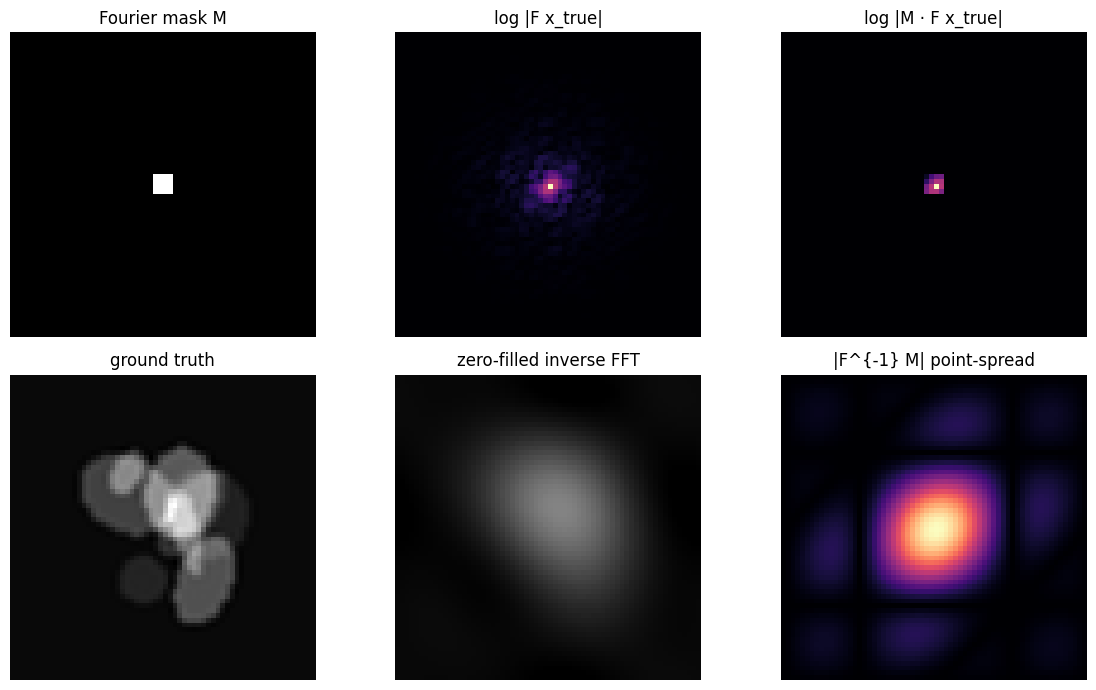

In [21]:
# ============================================================
# Diagnose why FFT zero-filled can be strong
# ============================================================

import torch
import matplotlib.pyplot as plt


@torch.no_grad()
def ifft2c_img_debug(k: torch.Tensor) -> torch.Tensor:
    """
    Centered orthonormal inverse 2D FFT.

    Input:
        k: (B,H,W), complex, centered/fftshifted

    Output:
        x: (B,1,H,W), real
    """
    x = torch.fft.ifftshift(k, dim=(-2, -1))
    x = torch.fft.ifft2(x, norm="ortho")
    x = torch.fft.fftshift(x, dim=(-2, -1))
    return x.real[:, None]


@torch.no_grad()
def inspect_fft_mask_effect(x_true, mask):
    """
    Show:
      1. Fourier mask
      2. true k-space magnitude
      3. masked k-space magnitude
      4. ground truth image
      5. zero-filled inverse FFT image
      6. point-spread function |F^{-1}M|
    """
    mask = mask.bool()
    H, W = mask.shape

    k_true = fft2c_img(x_true)  # (B,H,W), complex centered k-space

    k_masked = torch.zeros_like(k_true)
    k_masked[:, mask] = k_true[:, mask]

    x_zf_clean = ifft2c_img_debug(k_masked)

    # Point-spread function: inverse FFT of the mask.
    mask_complex = mask.float()[None].to(k_true.device).to(torch.complex64)
    psf = ifft2c_img_debug(mask_complex)[0, 0]
    psf_abs = torch.abs(psf)

    total_energy = torch.sum(torch.abs(k_true) ** 2)
    observed_energy = torch.sum(torch.abs(k_true[:, mask]) ** 2)
    observed_fraction = float(mask.float().mean().detach().cpu())
    energy_fraction = float((observed_energy / total_energy).detach().cpu())

    print("mask observed fraction:", observed_fraction)
    print("fraction of Fourier energy captured by mask:", energy_fraction)
    print("selected Fourier locations:", int(mask.sum().item()), "/", H * W)

    fig, axes = plt.subplots(2, 3, figsize=(12, 7))

    axes[0, 0].imshow(mask.detach().cpu(), cmap="gray")
    axes[0, 0].set_title("Fourier mask M")

    axes[0, 1].imshow(torch.log1p(torch.abs(k_true[0])).detach().cpu(), cmap="magma")
    axes[0, 1].set_title("log |F x_true|")

    axes[0, 2].imshow(torch.log1p(torch.abs(k_masked[0])).detach().cpu(), cmap="magma")
    axes[0, 2].set_title("log |M · F x_true|")

    axes[1, 0].imshow(x_true[0, 0].detach().cpu(), cmap="gray", vmin=-1, vmax=1)
    axes[1, 0].set_title("ground truth")

    axes[1, 1].imshow(x_zf_clean[0, 0].detach().cpu(), cmap="gray", vmin=-1, vmax=1)
    axes[1, 1].set_title("zero-filled inverse FFT")

    axes[1, 2].imshow(psf_abs.detach().cpu(), cmap="magma")
    axes[1, 2].set_title("|F^{-1} M| point-spread")

    for ax in axes.ravel():
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    return x_zf_clean, psf_abs


if OBS_MODE in MRI_OBS_MODES or OBS_MODE in PHASE_RETRIEVAL_OBS_MODES:
    x_zf_clean_debug, psf_abs_debug = inspect_fft_mask_effect(x_true, OBS_MASK)
else:
    print(f"Skipping Fourier-mask energy diagnostic for OBS_MODE={OBS_MODE}; active mask is not a Fourier/k-space mask.")


NUM_MAP_PARTICLES: 5
MAP_UNIQUENESS_MODE: ancestor
MAP_DISTINCT_ATOL: 1e-07
REPEAT_TOP_MAP_IF_SINGLE_UNIQUE_ANCESTOR: True

SMC LEVEL 1
level 1 samples                  shape=(256, 1, 64, 64) min=-0.91734 max= 0.750795 mean=-0.787738 std= 0.262773
mean RMSE                 : 0.146592
mean MAE                  : 0.0851347
mean PSNR                 : 22.6984
mean SSIM                 : 0.806125
mean obs RMSE             : 0.711618
mean reward               : -202.56
top-1 MAP-like RMSE       : 0.146592
top-1 MAP-like PSNR       : 22.6984
top-1 MAP-like SSIM       : 0.806124
top-1 MAP-like obs RMSE   : 0.711618
top-1 MAP-like reward     : -202.56
posterior std mean        : 0
posterior std max         : 0
uncertainty-error corr    : 0
95% pixel coverage        : 0
95% avg interval width    : 0
ESS                       : 1
ESS/N                     : 0.00390625
unique selected ancestors : 1/256
distinct MAP displayed    : 5 (distinct returned=1, unique available=1, repeated_single_unique=

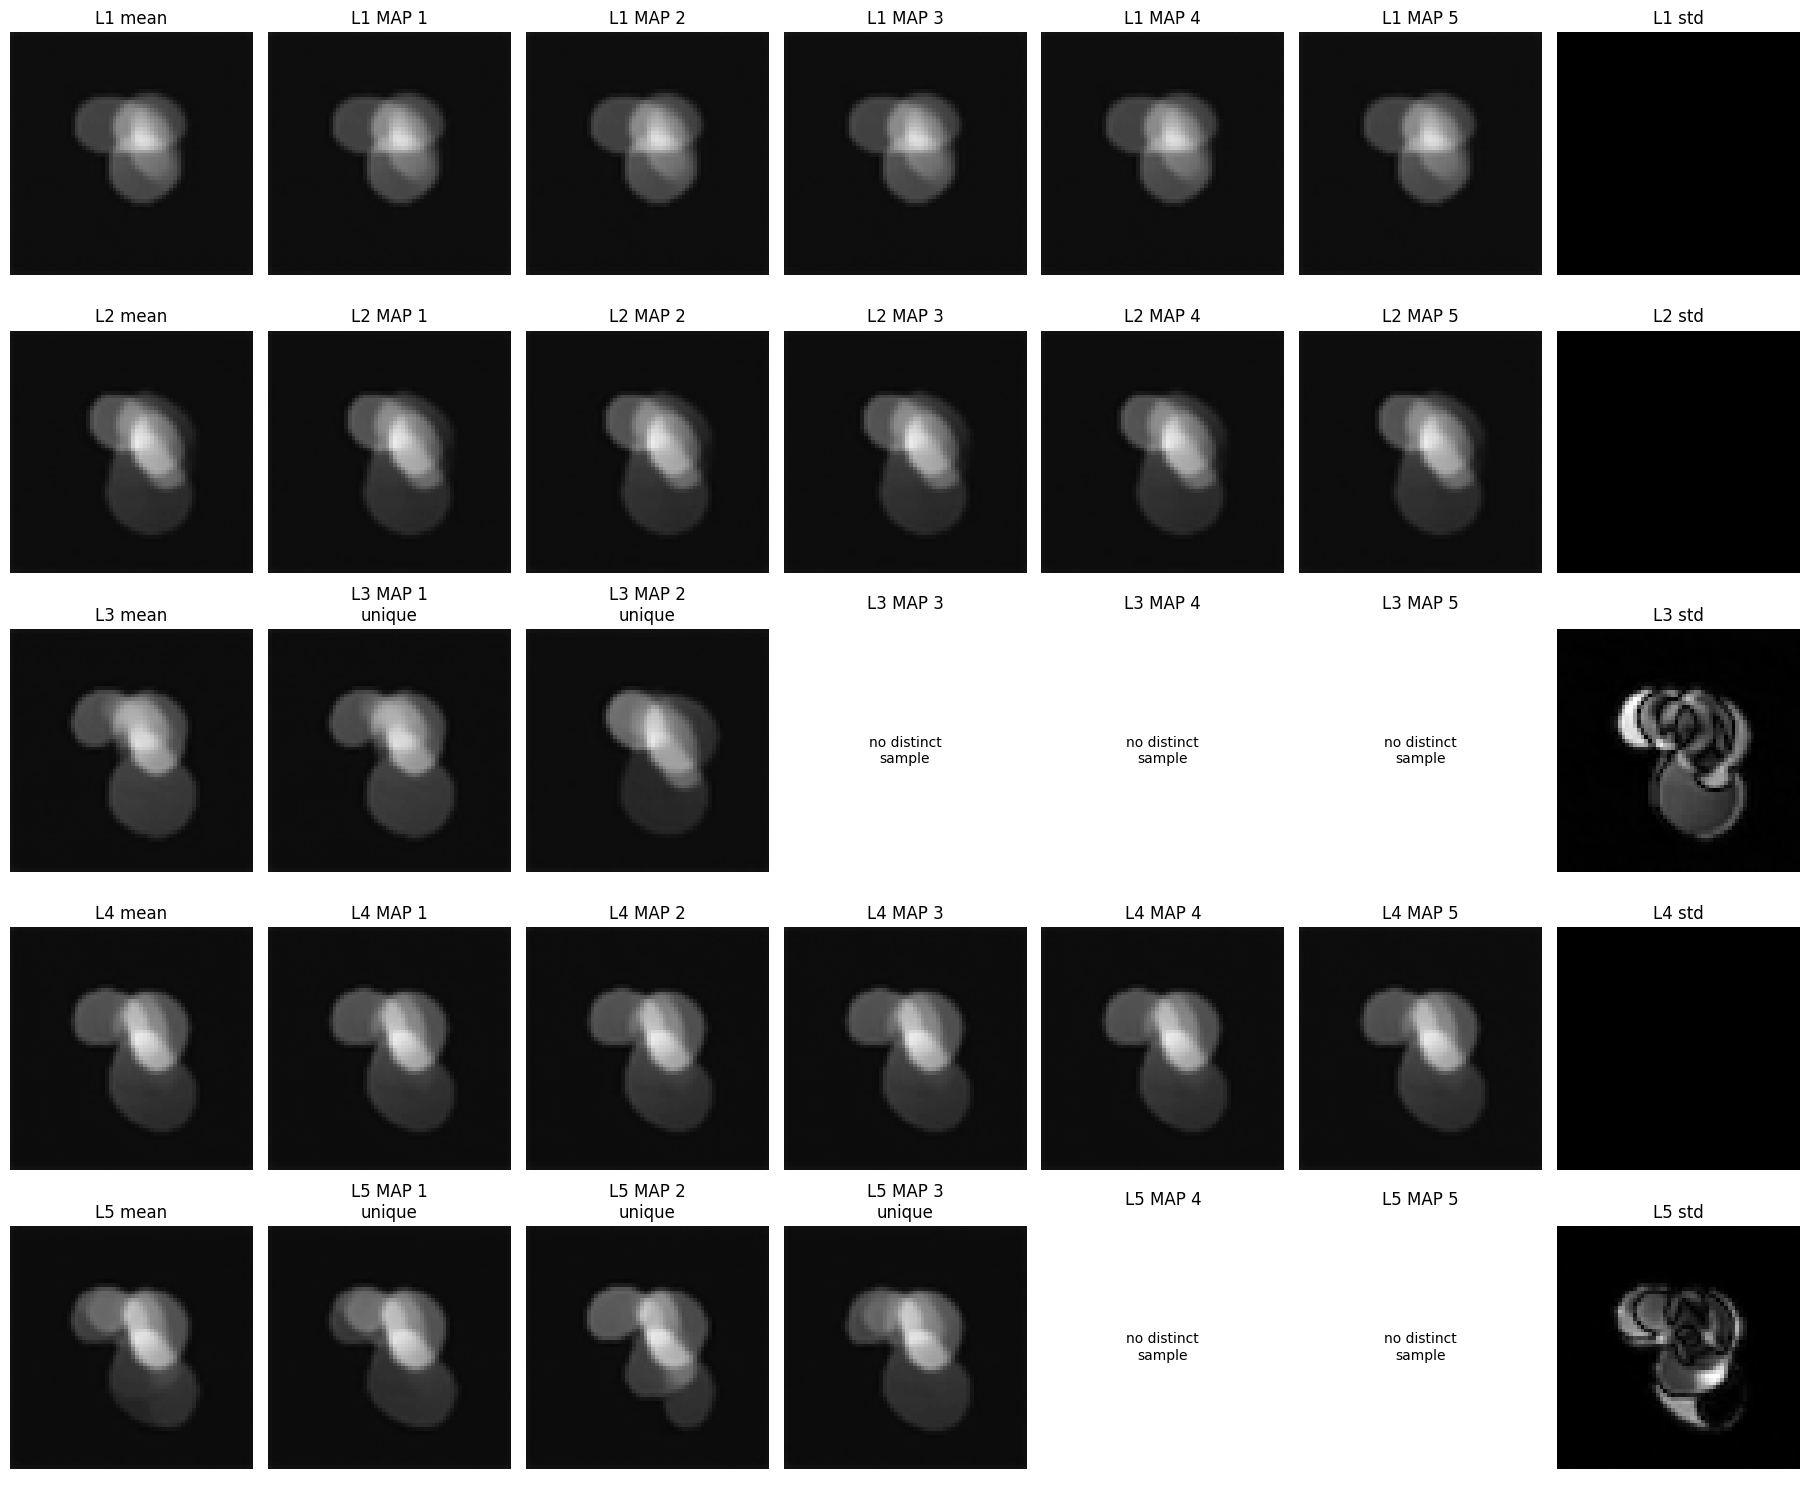

saved low-pass IFFT distinct top-k MAP plot to: singlecoil_mri_tuolumne_outputs/smc_level_1_top5_distinct_map_lowpass_ifft_4x4_8x8_16x16.png


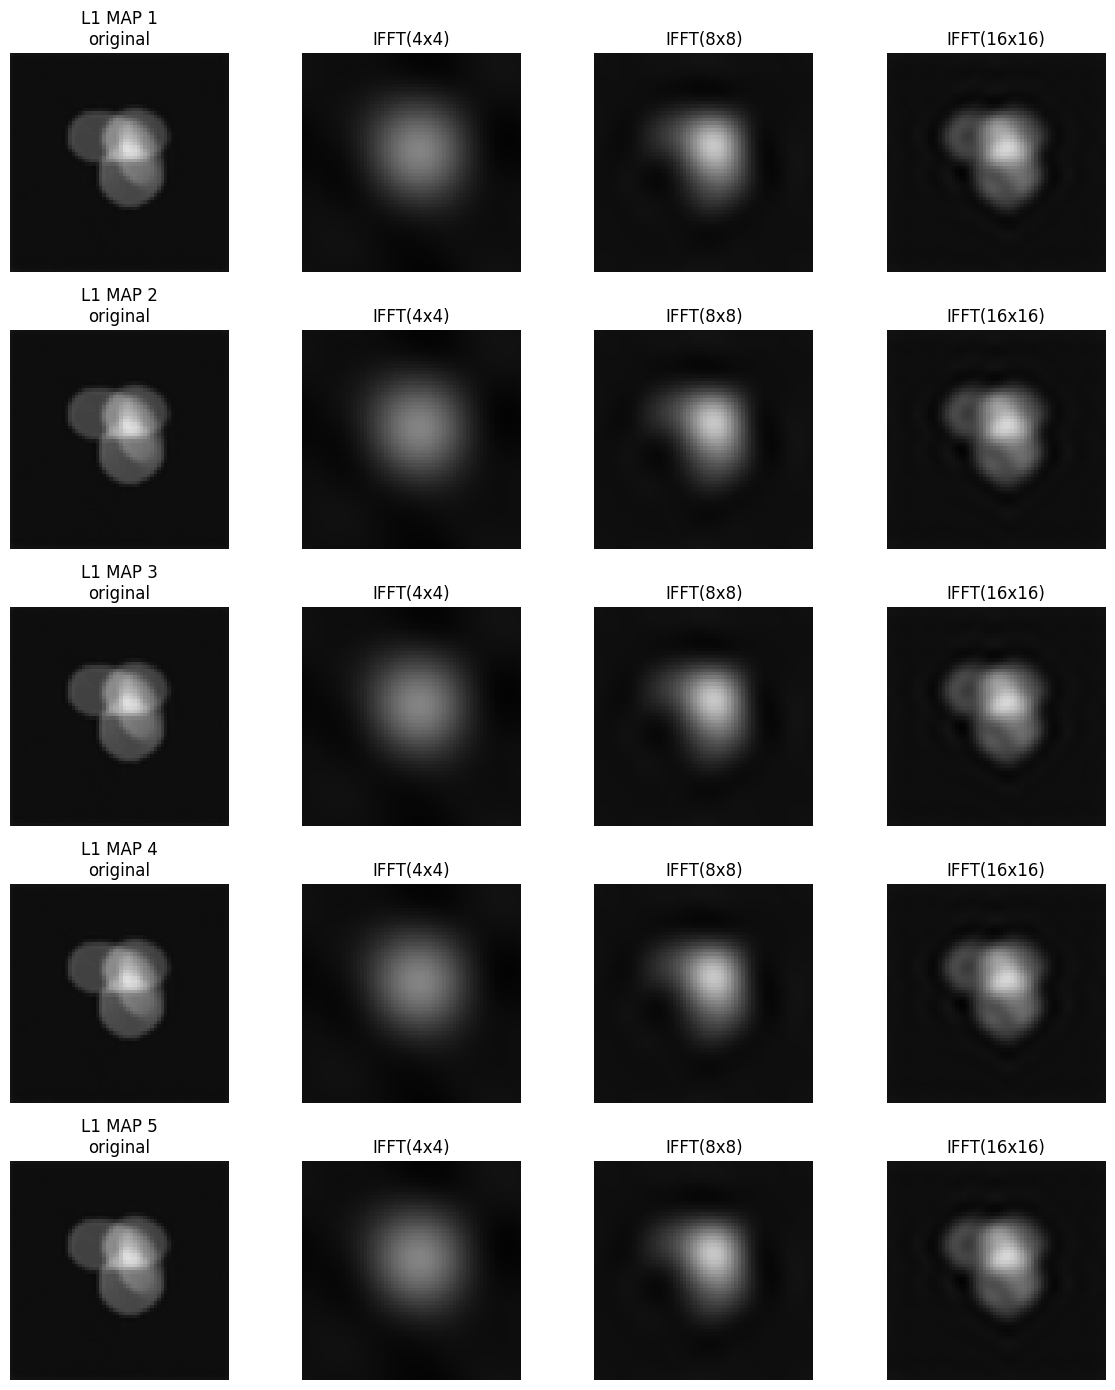

saved low-pass IFFT distinct top-k MAP plot to: singlecoil_mri_tuolumne_outputs/smc_level_2_top5_distinct_map_lowpass_ifft_4x4_8x8_16x16.png


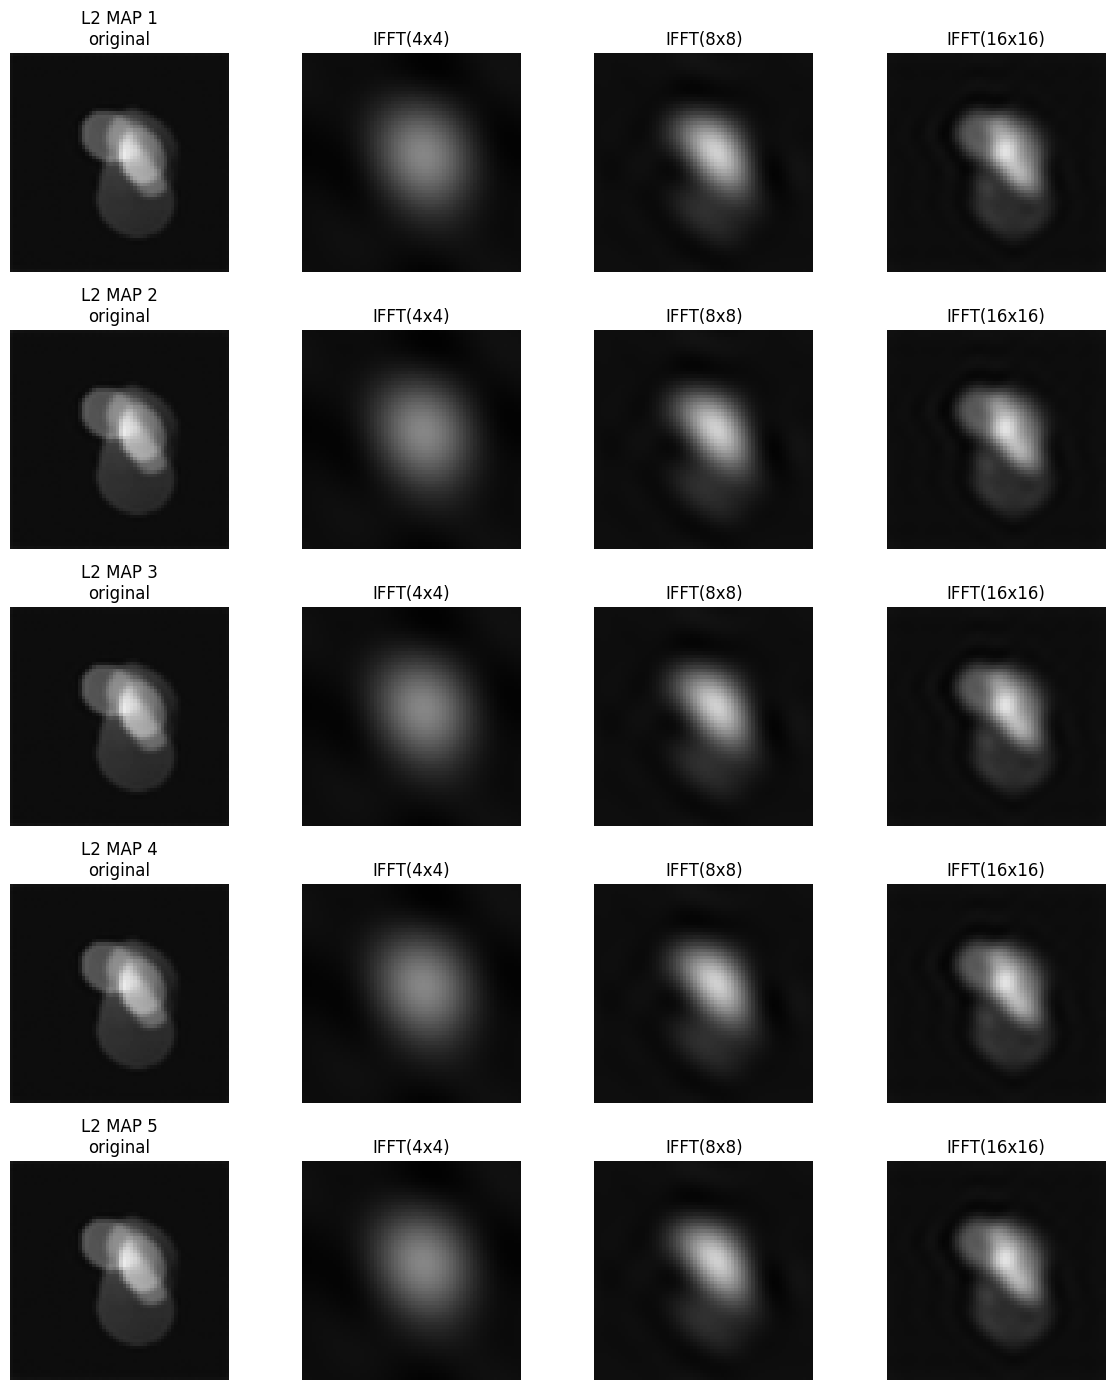

saved low-pass IFFT distinct top-k MAP plot to: singlecoil_mri_tuolumne_outputs/smc_level_3_top5_distinct_map_lowpass_ifft_4x4_8x8_16x16.png


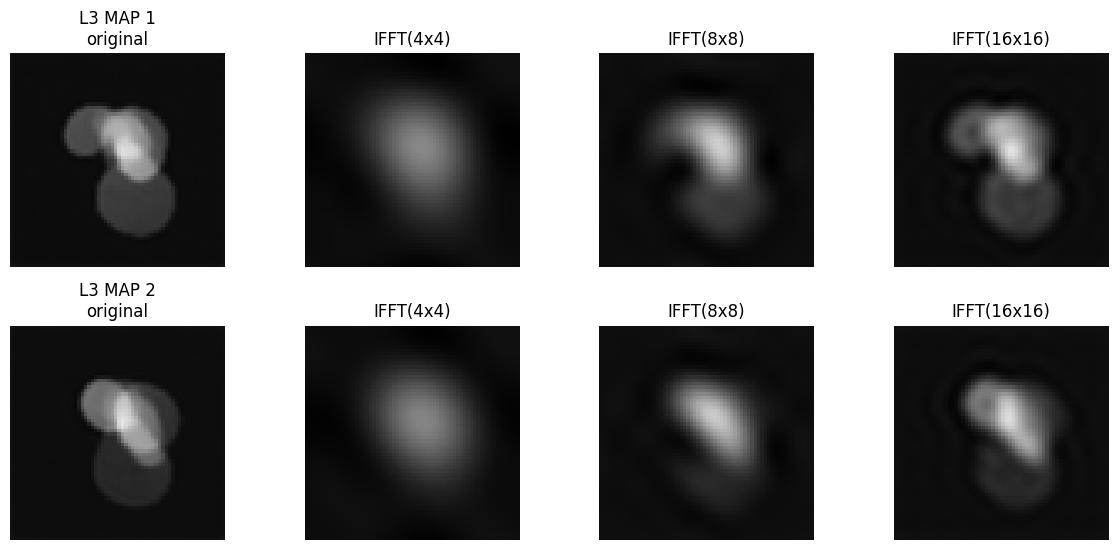

saved low-pass IFFT distinct top-k MAP plot to: singlecoil_mri_tuolumne_outputs/smc_level_4_top5_distinct_map_lowpass_ifft_4x4_8x8_16x16.png


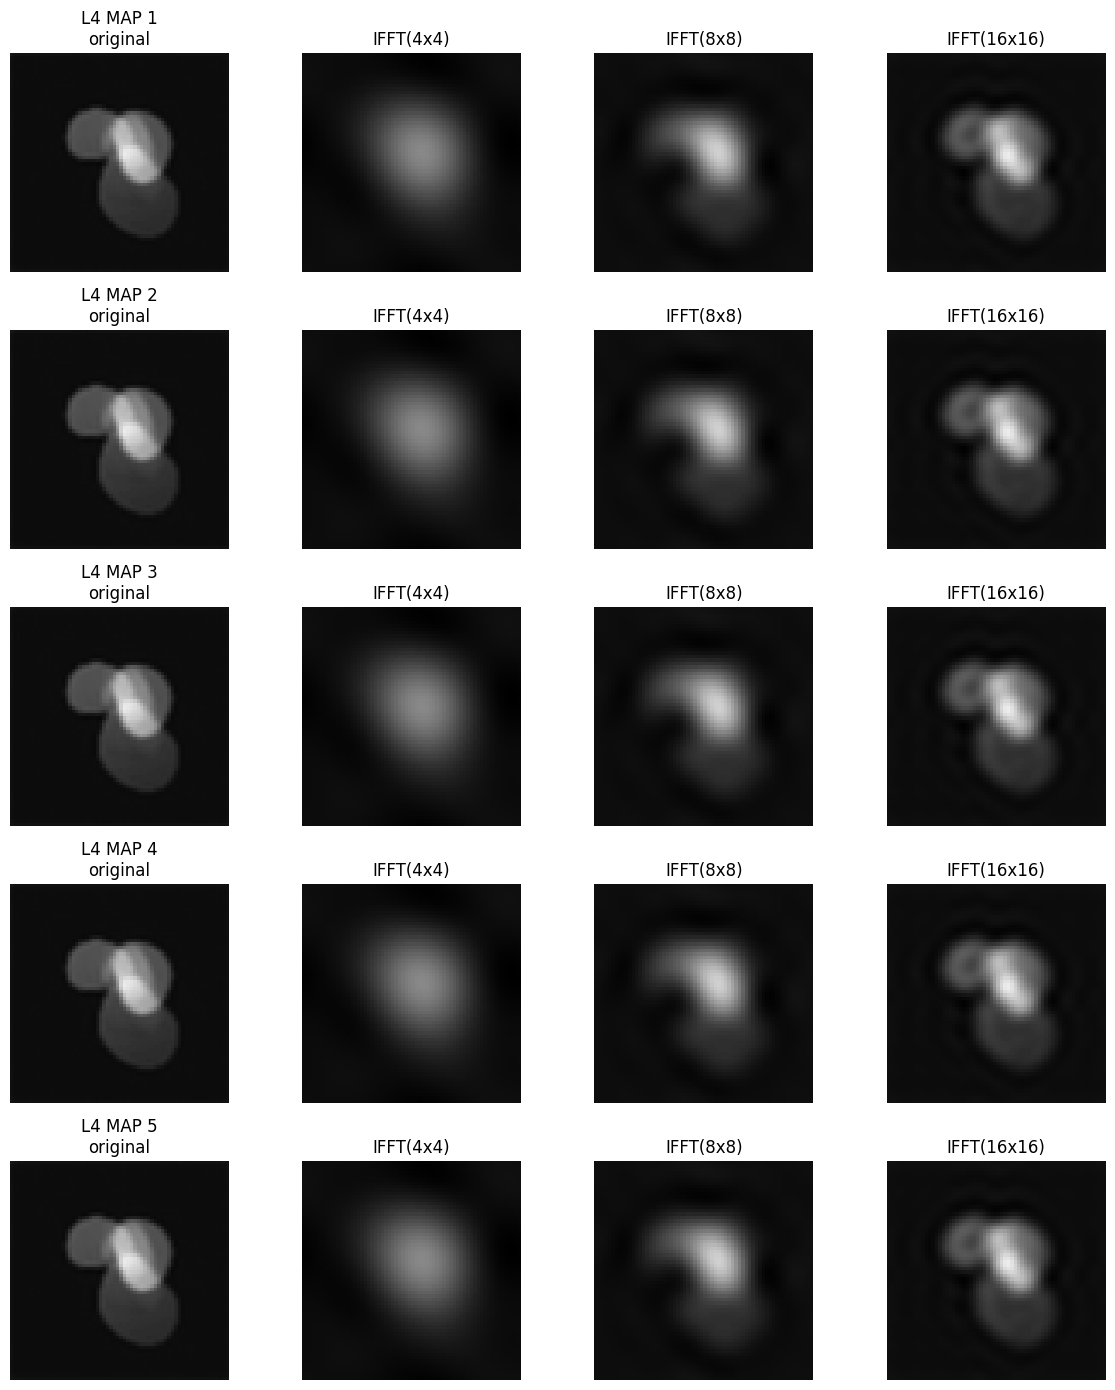

saved low-pass IFFT distinct top-k MAP plot to: singlecoil_mri_tuolumne_outputs/smc_level_5_top5_distinct_map_lowpass_ifft_4x4_8x8_16x16.png


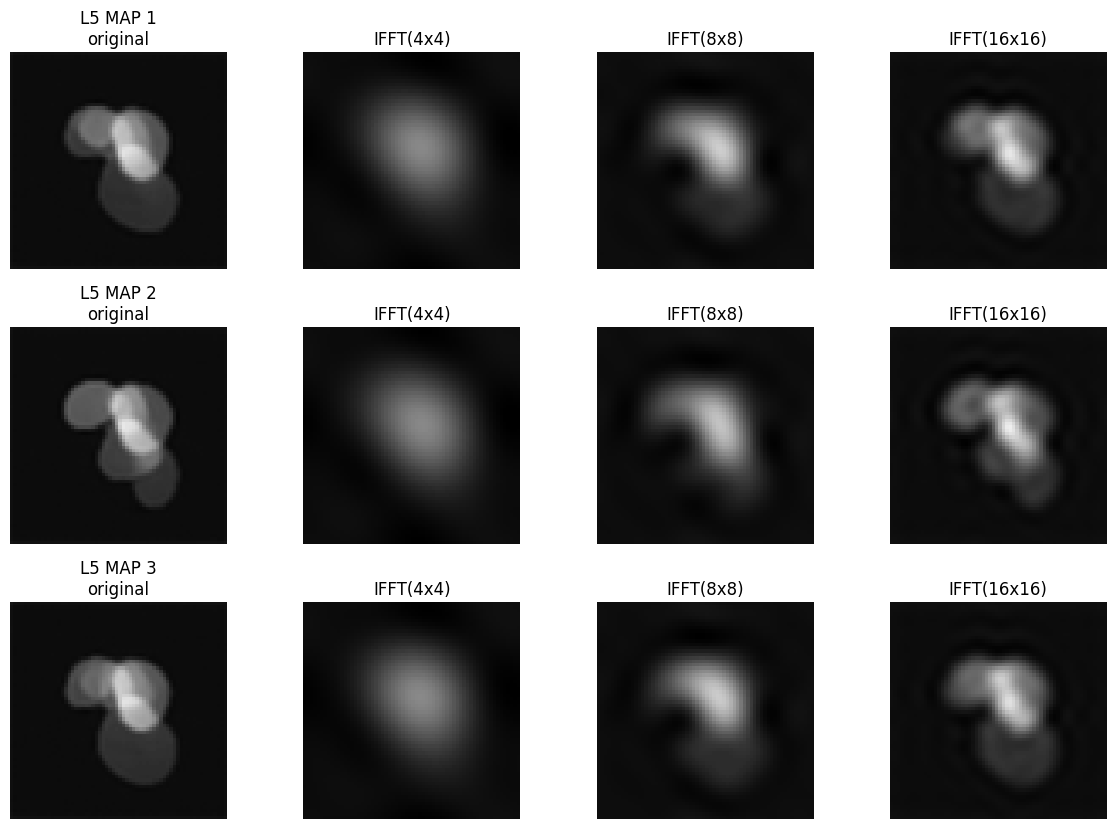

In [22]:
# ============================================================
# Per-level SMC diagnostics table and plots: DISTINCT top-k MAP particles
# ============================================================
# Paste/run this after the SMC run.
#
# Behavior:
#   * ranks MAP-like particles by reward_mri_value_chunked(samples);
#   * when smc_out["idx_by_level"] is available, keeps at most one particle
#     from each unique SMC ancestor;
#   * repeats the same MAP particle up to NUM_MAP_PARTICLES ONLY when the
#     level has exactly one unique ancestor;
#   * if there are 2, 3, or 4 unique ancestors, it shows 2, 3, or 4 distinct
#     MAP particles and leaves the remaining grid slots blank;
#   * for MRI FFT, each displayed MAP particle is also shown through low-pass
#     zero-filled IFFT previews for LOWPASS_SQUARE_SIZES, e.g. 4x4, 8x8, 16x16.

import os
import math
import numpy as np
import torch
import torch.nn.functional as F

try:
    import pandas as pd
except Exception:
    pd = None


# -----------------------------
# Basic metric helpers
# -----------------------------
METRIC_DATA_RANGE = float(globals().get("METRIC_DATA_RANGE", 2.0))
NUM_MAP_PARTICLES = (
    env_int("NUM_MAP_PARTICLES", int(globals().get("NUM_MAP_PARTICLES", 5)))
    if "env_int" in globals()
    else int(globals().get("NUM_MAP_PARTICLES", 5))
)

# New controls for distinct MAP displays.
MAP_UNIQUENESS_MODE = (
    env_str("MAP_UNIQUENESS_MODE", str(globals().get("MAP_UNIQUENESS_MODE", "ancestor")))
    if "env_str" in globals()
    else str(globals().get("MAP_UNIQUENESS_MODE", "ancestor"))
).strip().lower()
MAP_DISTINCT_ATOL = (
    env_float("MAP_DISTINCT_ATOL", float(globals().get("MAP_DISTINCT_ATOL", 1e-7)))
    if "env_float" in globals()
    else float(globals().get("MAP_DISTINCT_ATOL", 1e-7))
)
REPEAT_TOP_MAP_IF_SINGLE_UNIQUE_ANCESTOR = (
    env_bool("REPEAT_TOP_MAP_IF_SINGLE_UNIQUE_ANCESTOR", True)
    if "env_bool" in globals()
    else bool(globals().get("REPEAT_TOP_MAP_IF_SINGLE_UNIQUE_ANCESTOR", True))
)

print("NUM_MAP_PARTICLES:", NUM_MAP_PARTICLES)
print("MAP_UNIQUENESS_MODE:", MAP_UNIQUENESS_MODE)
print("MAP_DISTINCT_ATOL:", MAP_DISTINCT_ATOL)
print("REPEAT_TOP_MAP_IF_SINGLE_UNIQUE_ANCESTOR:", REPEAT_TOP_MAP_IF_SINGLE_UNIQUE_ANCESTOR)


def _as_float(x):
    if torch.is_tensor(x):
        return float(x.detach().cpu())
    return float(x)


@torch.no_grad()
def tensor_summary(name: str, x: torch.Tensor):
    xd = x.detach()
    print(
        f"{name:32s} shape={tuple(xd.shape)} "
        f"min={float(xd.min()): .6g} "
        f"max={float(xd.max()): .6g} "
        f"mean={float(xd.mean()): .6g} "
        f"std={float(xd.std()): .6g}"
    )


@torch.no_grad()
def rmse_img(x: torch.Tensor, y: torch.Tensor) -> float:
    return float(torch.sqrt(torch.mean((x - y) ** 2)).detach().cpu())


@torch.no_grad()
def mae_img(x: torch.Tensor, y: torch.Tensor) -> float:
    return float(torch.mean(torch.abs(x - y)).detach().cpu())


@torch.no_grad()
def psnr_img(x: torch.Tensor, y: torch.Tensor, data_range: float = METRIC_DATA_RANGE) -> float:
    r = rmse_img(x, y)
    return float(20.0 * math.log10(float(data_range) / max(r, 1e-12)))


@torch.no_grad()
def ssim_img(x: torch.Tensor, y: torch.Tensor, window: int = 7, data_range: float = METRIC_DATA_RANGE) -> float:
    """Simple local SSIM for tensors shaped (1,1,H,W), (N,1,H,W), or (1,H,W)."""
    if x.ndim == 3:
        x = x[None]
    if y.ndim == 3:
        y = y[None]

    C1 = (0.01 * data_range) ** 2
    C2 = (0.03 * data_range) ** 2
    pad = window // 2

    mux = F.avg_pool2d(x, window, stride=1, padding=pad)
    muy = F.avg_pool2d(y, window, stride=1, padding=pad)

    vx = F.avg_pool2d(x * x, window, stride=1, padding=pad) - mux * mux
    vy = F.avg_pool2d(y * y, window, stride=1, padding=pad) - muy * muy
    vxy = F.avg_pool2d(x * y, window, stride=1, padding=pad) - mux * muy

    ssim_map = ((2 * mux * muy + C1) * (2 * vxy + C2)) / (
        (mux * mux + muy * muy + C1) * (vx + vy + C2)
    )
    return float(ssim_map.mean().detach().cpu())


@torch.no_grad()
def obs_rmse_img(x_model: torch.Tensor) -> float:
    hx_mean = observation_mean_torch(x_model)
    return float(torch.sqrt(torch.mean((hx_mean - y_obs[None, :]) ** 2)).detach().cpu())


@torch.no_grad()
def uncertainty_metrics_for_samples(samples: torch.Tensor, mean_est: torch.Tensor, truth: torch.Tensor):
    std = samples.std(dim=0, keepdim=True, unbiased=False)
    abs_err = torch.abs(mean_est - truth)

    sf = std.flatten()
    ef = abs_err.flatten()

    corr = torch.sum((sf - sf.mean()) * (ef - ef.mean())) / (
        torch.sqrt(torch.sum((sf - sf.mean()) ** 2)) *
        torch.sqrt(torch.sum((ef - ef.mean()) ** 2)) +
        1e-12
    )

    q025 = torch.quantile(samples, 0.025, dim=0, keepdim=True)
    q975 = torch.quantile(samples, 0.975, dim=0, keepdim=True)

    coverage = ((truth >= q025) & (truth <= q975)).float().mean()
    width = (q975 - q025).mean()

    return {
        "std_mean": float(std.mean().detach().cpu()),
        "std_max": float(std.max().detach().cpu()),
        "uncertainty_error_corr": float(corr.detach().cpu()),
        "coverage_95": float(coverage.detach().cpu()),
        "avg_width_95": float(width.detach().cpu()),
    }


# -----------------------------
# Distinct MAP selection helpers
# -----------------------------
@torch.no_grad()
def _sample_content_key(x: torch.Tensor, atol: float = MAP_DISTINCT_ATOL):
    """Hash a sample tensor so identical or near-identical images are treated as duplicates."""
    arr = x.detach().cpu().reshape(-1).numpy()

    if atol is not None and float(atol) > 0:
        arr = np.round(arr / float(atol)).astype(np.int64)
    else:
        arr = arr.astype(np.float32)

    return arr.tobytes()


def _to_numpy_1d(x):
    if x is None:
        return None
    if torch.is_tensor(x):
        return x.detach().cpu().numpy().reshape(-1)
    return np.asarray(x).reshape(-1)


def _prepare_ancestor_ids(ancestor_ids, n: int):
    """Return ancestor ids as a flat numpy array, or None if unavailable/mismatched."""
    if ancestor_ids is None:
        return None

    arr = _to_numpy_1d(ancestor_ids)

    if len(arr) != int(n):
        print(
            "WARNING: ancestor_ids length does not match sample count; "
            f"got len={len(arr)}, n={n}. Falling back to sample-content uniqueness."
        )
        return None

    return arr


@torch.no_grad()
def _topk_map_particles(
    samples_model: torch.Tensor,
    num_map_particles: int = NUM_MAP_PARTICLES,
    ancestor_ids=None,
):
    """Return MAP-like particles sorted by reward, avoiding duplicates.

    Main rule:
        If ancestor_ids are available, choose at most one MAP particle per unique ancestor.

    Repetition rule:
        Repeat the same sample up to NUM_MAP_PARTICLES only if there is exactly
        one unique ancestor/sample.

    If there are 2, 3, or 4 unique ancestors, this returns only 2, 3, or 4
    distinct samples. It does not duplicate to fill 5.
    """
    samples_model = samples_model.detach().to(DEVICE)

    rewards_raw = reward_mri_value_chunked(samples_model).detach()
    rewards = rewards_raw.reshape(samples_model.shape[0], -1).mean(dim=1)

    n = int(samples_model.shape[0])
    if n <= 0:
        raise ValueError("Cannot choose MAP particles from an empty sample cloud.")

    target_k = max(1, int(num_map_particles))
    order = torch.argsort(rewards, descending=True)

    ancestor_np = _prepare_ancestor_ids(ancestor_ids, n)

    chosen_indices = []
    chosen_keys = []

    # Prefer unique ancestors if available.
    if ancestor_np is not None and MAP_UNIQUENESS_MODE in {"ancestor", "auto"}:
        unique_ancestors = np.unique(ancestor_np)
        num_unique = int(len(unique_ancestors))

        # Only case where we intentionally repeat the same MAP sample.
        if num_unique == 1 and REPEAT_TOP_MAP_IF_SINGLE_UNIQUE_ANCESTOR:
            best_idx = int(order[0].detach().cpu())
            top_indices = torch.full(
                (target_k,),
                best_idx,
                dtype=torch.long,
                device=samples_model.device,
            )
            top_rewards = rewards[top_indices]
            top_maps = samples_model[top_indices]

            meta = {
                "uniqueness_mode": "ancestor",
                "num_unique_available": 1,
                "num_distinct_returned": 1,
                "num_displayed": int(target_k),
                "repeated_single_unique": True,
                "unique_keys": [int(unique_ancestors[0])],
            }
            return top_rewards, top_indices, top_maps, meta

        seen_ancestors = set()
        seen_sample_keys = set()

        for idx_t in order:
            idx = int(idx_t.detach().cpu())
            anc = int(ancestor_np[idx])

            if anc in seen_ancestors:
                continue

            # Also require different sample content, so different ancestors that
            # collapsed to the exact same image do not both appear in the MAP grid.
            sample_key = _sample_content_key(samples_model[idx], atol=MAP_DISTINCT_ATOL)
            if sample_key in seen_sample_keys:
                continue

            seen_ancestors.add(anc)
            seen_sample_keys.add(sample_key)
            chosen_indices.append(idx)
            chosen_keys.append(anc)

            if len(chosen_indices) >= target_k:
                break

        if len(chosen_indices) == 0:
            chosen_indices = [int(order[0].detach().cpu())]
            chosen_keys = [int(ancestor_np[chosen_indices[0]])]

        top_indices = torch.as_tensor(
            chosen_indices,
            dtype=torch.long,
            device=samples_model.device,
        )
        top_rewards = rewards[top_indices]
        top_maps = samples_model[top_indices]

        meta = {
            "uniqueness_mode": "ancestor",
            "num_unique_available": num_unique,
            "num_distinct_returned": int(len(chosen_indices)),
            "num_displayed": int(len(chosen_indices)),
            "repeated_single_unique": False,
            "unique_keys": chosen_keys,
        }
        return top_rewards, top_indices, top_maps, meta

    # Fallback: unique by actual sample content.
    seen_samples = set()

    for idx_t in order:
        idx = int(idx_t.detach().cpu())
        key = _sample_content_key(samples_model[idx], atol=MAP_DISTINCT_ATOL)

        if key in seen_samples:
            continue

        seen_samples.add(key)
        chosen_indices.append(idx)
        chosen_keys.append(idx)

        if len(chosen_indices) >= target_k:
            break

    num_unique_samples = int(len(chosen_indices))

    if num_unique_samples == 1 and REPEAT_TOP_MAP_IF_SINGLE_UNIQUE_ANCESTOR:
        best_idx = int(chosen_indices[0])
        top_indices = torch.full(
            (target_k,),
            best_idx,
            dtype=torch.long,
            device=samples_model.device,
        )
        top_rewards = rewards[top_indices]
        top_maps = samples_model[top_indices]

        meta = {
            "uniqueness_mode": "sample_content",
            "num_unique_available": 1,
            "num_distinct_returned": 1,
            "num_displayed": int(target_k),
            "repeated_single_unique": True,
            "unique_keys": chosen_keys,
        }
        return top_rewards, top_indices, top_maps, meta

    top_indices = torch.as_tensor(
        chosen_indices,
        dtype=torch.long,
        device=samples_model.device,
    )
    top_rewards = rewards[top_indices]
    top_maps = samples_model[top_indices]

    meta = {
        "uniqueness_mode": "sample_content",
        "num_unique_available": num_unique_samples,
        "num_distinct_returned": num_unique_samples,
        "num_displayed": num_unique_samples,
        "repeated_single_unique": False,
        "unique_keys": chosen_keys,
    }
    return top_rewards, top_indices, top_maps, meta


@torch.no_grad()
def evaluate_smc_level_samples(
    samples_model: torch.Tensor,
    level_index: int,
    num_map_particles: int = NUM_MAP_PARTICLES,
    ancestor_ids=None,
):
    """Evaluate one SMC level sample cloud and return distinct top MAP-like particles."""
    level_num = int(level_index) + 1

    samples_model = samples_model.detach().to(DEVICE)
    truth = x_true.detach().to(DEVICE)

    mean_model = samples_model.mean(dim=0, keepdim=True)

    top_rewards, top_indices, top_maps, top_meta = _topk_map_particles(
        samples_model,
        num_map_particles=num_map_particles,
        ancestor_ids=ancestor_ids,
    )

    map_model = top_maps[0:1]
    map_idx = int(top_indices[0].detach().cpu())

    um = uncertainty_metrics_for_samples(samples_model, mean_model, truth)

    row = {
        "level": level_num,
        "N": int(samples_model.shape[0]),

        "mean_RMSE": rmse_img(mean_model, truth),
        "mean_MAE": mae_img(mean_model, truth),
        "mean_PSNR": psnr_img(mean_model, truth),
        "mean_SSIM": ssim_img(mean_model, truth),
        "mean_obs_RMSE": obs_rmse_img(mean_model),
        "mean_reward": float(
            reward_mri_value_chunked(mean_model).detach().reshape(-1).mean().cpu()
        ),

        # Backward-compatible MAP_* columns remain the top-1 MAP-like particle.
        "MAP_RMSE": rmse_img(map_model, truth),
        "MAP_MAE": mae_img(map_model, truth),
        "MAP_PSNR": psnr_img(map_model, truth),
        "MAP_SSIM": ssim_img(map_model, truth),
        "MAP_obs_RMSE": obs_rmse_img(map_model),
        "MAP_reward": float(top_rewards[0].detach().cpu()),

        "std_mean": um["std_mean"],
        "std_max": um["std_max"],
        "uncertainty_error_corr": um["uncertainty_error_corr"],
        "coverage_95": um["coverage_95"],
        "avg_width_95": um["avg_width_95"],

        "MAP_index": map_idx,
        "MAP_topk_indices": ",".join(str(int(i)) for i in top_indices.detach().cpu().tolist()),
        "MAP_topk_rewards": ",".join(f"{float(v):.10g}" for v in top_rewards.detach().cpu().tolist()),

        # New fields.
        "MAP_uniqueness_mode": top_meta["uniqueness_mode"],
        "MAP_num_unique_available": int(top_meta["num_unique_available"]),
        "MAP_num_distinct_returned": int(top_meta["num_distinct_returned"]),
        "MAP_num_displayed": int(top_meta["num_displayed"]),
        "MAP_repeated_single_unique": bool(top_meta["repeated_single_unique"]),
    }

    ancestor_np = _prepare_ancestor_ids(ancestor_ids, int(samples_model.shape[0]))

    map_rows = []
    for rank in range(int(top_maps.shape[0])):
        particle_idx = int(top_indices[rank].detach().cpu())
        particle = top_maps[rank:rank + 1]

        mr = {
            "level": level_num,
            "map_rank": rank + 1,
            "particle_index": particle_idx,
            "reward": float(top_rewards[rank].detach().cpu()),
            "RMSE": rmse_img(particle, truth),
            "MAE": mae_img(particle, truth),
            "PSNR": psnr_img(particle, truth),
            "SSIM": ssim_img(particle, truth),
            "obs_RMSE": obs_rmse_img(particle),
            "repeated_single_unique": bool(top_meta["repeated_single_unique"]),
        }

        if ancestor_np is not None and particle_idx < len(ancestor_np):
            mr["ancestor_id"] = int(ancestor_np[particle_idx])

        map_rows.append(mr)

    return (
        row,
        map_rows,
        mean_model.detach().cpu(),
        top_maps.detach().cpu(),
        samples_model.std(dim=0, keepdim=True, unbiased=False).detach().cpu(),
    )


# -----------------------------
# Build per-level table
# -----------------------------
assert "samples_by_level" in smc_out, (
    "smc_out does not contain samples_by_level. "
    "Your run_multilevel_smc_scoreprior function must append terminal samples at every level."
)

level_rows = []
top_map_rows = []
level_means = []
level_maps = []        # top-1 only, for compatibility
level_top_maps = []    # list of tensors; each tensor is (K_level,1,H,W), not always K=5
level_stds = []

for ell, samples_ell in enumerate(smc_out["samples_by_level"]):

    # Use SMC ancestor ids for distinct MAP selection whenever available.
    idx_ell = None
    if "idx_by_level" in smc_out and len(smc_out["idx_by_level"]) > ell:
        idx_ell = smc_out["idx_by_level"][ell]

    row, map_rows_ell, mean_ell, top_maps_ell, std_ell = evaluate_smc_level_samples(
        samples_ell,
        ell,
        num_map_particles=NUM_MAP_PARTICLES,
        ancestor_ids=idx_ell,
    )

    if "ess" in smc_out:
        row["ESS"] = float(np.asarray(smc_out["ess"])[ell])
        row["ESS_frac"] = row["ESS"] / max(row["N"], 1)

    if "population" in smc_out:
        row["population"] = int(np.asarray(smc_out["population"])[ell])

    if idx_ell is not None:
        idx_np = _to_numpy_1d(idx_ell)
        row["unique_ancestors"] = int(len(np.unique(idx_np)))

    level_rows.append(row)
    top_map_rows.extend(map_rows_ell)
    level_means.append(mean_ell)
    level_maps.append(top_maps_ell[0:1])
    level_top_maps.append(top_maps_ell)
    level_stds.append(std_ell)

    print("\n" + "=" * 80)
    print(f"SMC LEVEL {ell + 1}")
    print("=" * 80)
    tensor_summary(f"level {ell + 1} samples", samples_ell)
    print(f"mean RMSE                 : {row['mean_RMSE']:.6g}")
    print(f"mean MAE                  : {row['mean_MAE']:.6g}")
    print(f"mean PSNR                 : {row['mean_PSNR']:.6g}")
    print(f"mean SSIM                 : {row['mean_SSIM']:.6g}")
    print(f"mean obs RMSE             : {row['mean_obs_RMSE']:.6g}")
    print(f"mean reward               : {row['mean_reward']:.6g}")
    print(f"top-1 MAP-like RMSE       : {row['MAP_RMSE']:.6g}")
    print(f"top-1 MAP-like PSNR       : {row['MAP_PSNR']:.6g}")
    print(f"top-1 MAP-like SSIM       : {row['MAP_SSIM']:.6g}")
    print(f"top-1 MAP-like obs RMSE   : {row['MAP_obs_RMSE']:.6g}")
    print(f"top-1 MAP-like reward     : {row['MAP_reward']:.6g}")
    print(f"posterior std mean        : {row['std_mean']:.6g}")
    print(f"posterior std max         : {row['std_max']:.6g}")
    print(f"uncertainty-error corr    : {row['uncertainty_error_corr']:.6g}")
    print(f"95% pixel coverage        : {row['coverage_95']:.6g}")
    print(f"95% avg interval width    : {row['avg_width_95']:.6g}")
    if "ESS" in row:
        print(f"ESS                       : {row['ESS']:.6g}")
        print(f"ESS/N                     : {row['ESS_frac']:.6g}")
    if "unique_ancestors" in row:
        print(f"unique selected ancestors : {row['unique_ancestors']}/{row['N']}")
    print(
        f"distinct MAP displayed    : {row['MAP_num_displayed']} "
        f"(distinct returned={row['MAP_num_distinct_returned']}, "
        f"unique available={row['MAP_num_unique_available']}, "
        f"repeated_single_unique={row['MAP_repeated_single_unique']})"
    )

    print(f"\nTop MAP-like particles at this level:")
    for mr in map_rows_ell:
        anc_txt = f" | ancestor={mr['ancestor_id']:6d}" if "ancestor_id" in mr else ""
        print(
            f"  rank {mr['map_rank']:2d} | "
            f"particle {mr['particle_index']:6d}{anc_txt} | "
            f"reward={mr['reward']:.6g} | "
            f"RMSE={mr['RMSE']:.6g} | "
            f"PSNR={mr['PSNR']:.6g} | "
            f"SSIM={mr['SSIM']:.6g} | "
            f"obs_RMSE={mr['obs_RMSE']:.6g} | "
            f"repeat_single={mr['repeated_single_unique']}"
        )


# -----------------------------
# Compact tables
# -----------------------------
if pd is not None:
    smc_level_df = pd.DataFrame(level_rows)
    smc_top_map_df = pd.DataFrame(top_map_rows)

    display_cols = [
        "level", "N", "ESS", "ESS_frac", "unique_ancestors",
        "mean_RMSE", "mean_PSNR", "mean_SSIM", "mean_obs_RMSE", "mean_reward",
        "MAP_RMSE", "MAP_PSNR", "MAP_SSIM", "MAP_obs_RMSE", "MAP_reward",
        "MAP_num_unique_available", "MAP_num_distinct_returned", "MAP_num_displayed",
        "MAP_repeated_single_unique", "MAP_uniqueness_mode",
        "std_mean", "std_max", "coverage_95", "avg_width_95", "uncertainty_error_corr",
        "MAP_topk_indices", "MAP_topk_rewards",
    ]
    display_cols = [c for c in display_cols if c in smc_level_df.columns]

    print("\n" + "=" * 80)
    print("PER-LEVEL SMC METRIC TABLE")
    print("=" * 80)
    try:
        from IPython.display import display
        display(smc_level_df[display_cols])
    except Exception:
        print(smc_level_df[display_cols].to_string(index=False))

    top_map_display_cols = [
        "level", "map_rank", "particle_index", "ancestor_id", "reward",
        "RMSE", "MAE", "PSNR", "SSIM", "obs_RMSE", "repeated_single_unique",
    ]
    top_map_display_cols = [c for c in top_map_display_cols if c in smc_top_map_df.columns]

    print("\n" + "=" * 80)
    print(f"DISTINCT TOP MAP-LIKE PARTICLES PER SMC LEVEL")
    print("=" * 80)
    try:
        from IPython.display import display
        display(smc_top_map_df[top_map_display_cols])
    except Exception:
        print(smc_top_map_df[top_map_display_cols].to_string(index=False))

    if "OUTPUT_DIR" in globals():
        os.makedirs(OUTPUT_DIR, exist_ok=True)
        csv_path = os.path.join(OUTPUT_DIR, "smc_per_level_metrics.csv")
        top_map_csv_path = os.path.join(OUTPUT_DIR, f"smc_top{NUM_MAP_PARTICLES}_distinct_map_particles_by_level.csv")
        smc_level_df.to_csv(csv_path, index=False)
        smc_top_map_df.to_csv(top_map_csv_path, index=False)
        print("saved per-level metrics to:", csv_path)
        print("saved distinct top-k MAP-like particle table to:", top_map_csv_path)
else:
    smc_level_df = None
    smc_top_map_df = None
    print("\nPandas is not available; level_rows and top_map_rows contain the per-level dictionaries.")
    for row in level_rows:
        print(row)


# -----------------------------
# Save top-k tensors
# -----------------------------
if "OUTPUT_DIR" in globals():
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    top_map_pt_path = os.path.join(OUTPUT_DIR, f"smc_top{NUM_MAP_PARTICLES}_distinct_map_particles_by_level.pt")
    torch.save(
        {
            "num_map_particles_requested": int(NUM_MAP_PARTICLES),
            "level_top_maps": level_top_maps,
            "top_map_rows": top_map_rows,
            "level_rows": level_rows,
            "lowpass_square_sizes": list(globals().get("LOWPASS_SQUARE_SIZES", [4, 8, 16])),
            "map_uniqueness_mode": MAP_UNIQUENESS_MODE,
            "repeat_top_map_if_single_unique_ancestor": REPEAT_TOP_MAP_IF_SINGLE_UNIQUE_ANCESTOR,
        },
        top_map_pt_path,
    )
    print("saved distinct top-k MAP-like particle tensors to:", top_map_pt_path)

    try:
        same_k = len(set(int(x.shape[0]) for x in level_top_maps)) == 1
        if same_k:
            top_map_np = torch.stack(level_top_maps, dim=0).numpy()
            top_map_npz_path = os.path.join(OUTPUT_DIR, f"smc_top{NUM_MAP_PARTICLES}_distinct_map_particles_by_level.npz")
            np.savez_compressed(
                top_map_npz_path,
                top_map_particles=top_map_np,
                top_map_rows=np.array(top_map_rows, dtype=object),
                level_rows=np.array(level_rows, dtype=object),
                lowpass_square_sizes=np.asarray(list(globals().get("LOWPASS_SQUARE_SIZES", [4, 8, 16]))),
            )
            print("saved distinct top-k MAP-like particle NumPy archive to:", top_map_npz_path)
        else:
            print("skipped stacked npz save because levels have different numbers of distinct MAP particles")
    except Exception as e:
        print("WARNING: could not save distinct top-k MAP-like particles as npz:", repr(e))


# -----------------------------
# Optional plots: metric curves
# -----------------------------
if globals().get("SHOW_PLOTS", True) and pd is not None and smc_level_df is not None:
    import matplotlib.pyplot as plt

    def plot_metric_curve(col, ylabel=None):
        if col not in smc_level_df.columns:
            return
        plt.figure(figsize=(6, 4))
        plt.plot(smc_level_df["level"], smc_level_df[col], marker="o")
        plt.xlabel("SMC level")
        plt.ylabel(ylabel or col)
        plt.title(col + " across SMC levels")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    for col in [
        "mean_RMSE",
        "mean_PSNR",
        "mean_SSIM",
        "mean_obs_RMSE",
        "mean_reward",
        "MAP_RMSE",
        "MAP_SSIM",
        "std_mean",
        "coverage_95",
        "ESS_frac",
        "MAP_num_distinct_returned",
    ]:
        plot_metric_curve(col)


# -----------------------------
# Optional plots: mean / distinct top-k MAP / std images by level
# -----------------------------
if globals().get("SHOW_PLOTS", True) or globals().get("SAVE_FIGURES", True):
    import matplotlib.pyplot as plt

    def to_np_img(x):
        x = x.detach().cpu()
        if x.ndim == 4:
            x = x[0, 0]
        elif x.ndim == 3:
            x = x[0]
        return x.numpy()

    n_levels = len(level_means)
    max_k_cols = int(NUM_MAP_PARTICLES)
    ncols = 2 + max_k_cols

    fig = plt.figure(figsize=(2.6 * ncols, 3.0 * n_levels))

    for ell in range(n_levels):
        mean_img = level_means[ell]
        std_img = level_stds[ell]
        std_norm = std_img / (std_img.max() + 1e-8)
        top_maps = level_top_maps[ell]
        k_ell = int(top_maps.shape[0])

        # Mean column.
        ax = plt.subplot(n_levels, ncols, ell * ncols + 1)
        ax.imshow(to_np_img(mean_img), cmap="gray", vmin=-1, vmax=1)
        ax.set_title(f"L{ell + 1} mean")
        ax.axis("off")

        # MAP columns.
        for r in range(max_k_cols):
            ax = plt.subplot(n_levels, ncols, ell * ncols + 2 + r)

            if r < k_ell:
                ax.imshow(to_np_img(top_maps[r:r + 1]), cmap="gray", vmin=-1, vmax=1)
                if k_ell == max_k_cols:
                    ax.set_title(f"L{ell + 1} MAP {r + 1}")
                else:
                    ax.set_title(f"L{ell + 1} MAP {r + 1}\nunique")
            else:
                ax.text(
                    0.5,
                    0.5,
                    "no distinct\nsample",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                )
                ax.set_title(f"L{ell + 1} MAP {r + 1}")
            ax.axis("off")

        # Std column.
        ax = plt.subplot(n_levels, ncols, ell * ncols + ncols)
        ax.imshow(to_np_img(std_norm), cmap="gray")
        ax.set_title(f"L{ell + 1} std")
        ax.axis("off")

    plt.tight_layout()
    if "OUTPUT_DIR" in globals() and globals().get("SAVE_FIGURES", True):
        top_map_grid_path = os.path.join(OUTPUT_DIR, f"smc_top{NUM_MAP_PARTICLES}_distinct_map_particles_grid_by_level.png")
        fig.savefig(top_map_grid_path, dpi=200, bbox_inches="tight")
        print("saved distinct top-k MAP-like particle grid to:", top_map_grid_path)
    if globals().get("SHOW_PLOTS", True):
        plt.show()
    else:
        plt.close(fig)


# -----------------------------
# Optional plots: low-pass IFFT of distinct top-k MAP particles for MRI FFT
# -----------------------------
if (globals().get("SHOW_PLOTS", True) or globals().get("SAVE_FIGURES", True)) and OBS_MODE in MRI_OBS_MODES:
    import matplotlib.pyplot as plt

    preview_sizes = [int(s) for s in list(globals().get("LOWPASS_SQUARE_SIZES", [4, 8, 16]))]

    for ell, top_maps_cpu in enumerate(level_top_maps):
        top_maps_dev = top_maps_cpu.to(DEVICE)

        # This may be 5, or fewer if there are only 2--4 distinct ancestors.
        # It is exactly 5 only when five distinct ancestors exist, or when there
        # is exactly one unique ancestor and we intentionally repeat it.
        k_show_level = int(top_maps_cpu.shape[0])

        ncols = 1 + len(preview_sizes)
        fig, axes = plt.subplots(
            k_show_level,
            ncols,
            figsize=(3.0 * ncols, 2.8 * k_show_level),
            squeeze=False,
        )

        for rank in range(k_show_level):
            original = top_maps_cpu[rank:rank + 1]

            axes[rank, 0].imshow(
                original[0, 0].detach().cpu().numpy(),
                cmap="gray",
                vmin=-1,
                vmax=1,
            )
            axes[rank, 0].set_title(f"L{ell + 1} MAP {rank + 1}\noriginal")
            axes[rank, 0].axis("off")

            for j, size in enumerate(preview_sizes):
                lp_img = lowpass_ifft_reconstruction_from_image(
                    top_maps_dev[rank:rank + 1],
                    int(size),
                ).detach().cpu()

                axes[rank, j + 1].imshow(
                    lp_img[0, 0].numpy(),
                    cmap="gray",
                    vmin=-1,
                    vmax=1,
                )
                axes[rank, j + 1].set_title(f"IFFT({size}x{size})")
                axes[rank, j + 1].axis("off")

        plt.tight_layout()

        if "OUTPUT_DIR" in globals() and globals().get("SAVE_FIGURES", True):
            lp_fig_path = os.path.join(
                OUTPUT_DIR,
                f"smc_level_{ell + 1}_top{NUM_MAP_PARTICLES}_distinct_map_lowpass_ifft_4x4_8x8_16x16.png",
            )
            fig.savefig(lp_fig_path, dpi=200, bbox_inches="tight")
            print("saved low-pass IFFT distinct top-k MAP plot to:", lp_fig_path)

        if globals().get("SHOW_PLOTS", True):
            plt.show()
        else:
            plt.close(fig)
else:
    if OBS_MODE not in MRI_OBS_MODES:
        print("Top-k MAP low-pass IFFT plots skipped because OBS_MODE is not MRI FFT.")


## Notes for Tuolumne / AMD runs

This is the **SMC-only spatial-projection** notebook. It uses the identity observation operator with a spatial projection mask:

```text
OBS_MODE=spatial_projection
LIKELIHOOD_TYPE=gaussian
h(x) = P_Omega x
```

By default it loads the trained prior checkpoint from:

```bash
/p/lustre5/wang161/smc_swissroll_tuolumne/notebooks/MRISythetic/DOLCE_GaussianCT/prior/mri_score_prior_outputs/score_prior_singlecoil_mri_64_trained.pt
```

and it loads the most recent prior-only tail-statistics NPZ from:

```bash
/p/lustre5/wang161/smc_swissroll_tuolumne/notebooks/MRISythetic/DOLCE_GaussianCT/prior/mri_score_prior_outputs/score_prior_tail_behavior_stats.npz
```

Useful explicit launch variables:

```bash
export OBS_MODE=spatial_projection
export LIKELIHOOD_TYPE=gaussian
export CHECKPOINT_PATH=/p/lustre5/wang161/smc_swissroll_tuolumne/notebooks/MRISythetic/DOLCE_GaussianCT/prior/mri_score_prior_outputs/score_prior_singlecoil_mri_64_trained.pt
export TAIL_STATS_NPZ_PATH=/p/lustre5/wang161/smc_swissroll_tuolumne/notebooks/MRISythetic/DOLCE_GaussianCT/prior/mri_score_prior_outputs/score_prior_tail_behavior_stats.npz
export LOAD_CHECKPOINT_IF_EXISTS=1
export REQUIRE_PRETRAINED_PRIOR=1
export LOAD_PRECOMPUTED_TAIL_STATS=1
export RECOMPUTE_TAIL_STATS_IF_MISSING=0
export NUM_TRAIN_STEPS=0
```

To use a spatial block mask:

```bash
export SPATIAL_MASK_TYPE=block
export SPATIAL_BLOCK_SIZE=4
export SPATIAL_NUM_BLOCKS=8
export SPATIAL_BLOCK_GAP=4
```

To use a random spatial mask:

```bash
export SPATIAL_MASK_TYPE=random
export SPATIAL_KEEP_FRACTION=0.2
```


## Added low-pass square MRI FFT mask and distinct top-5 MAP diagnostics

For MRI FFT low-pass square masking, use for example:

```bash
export OBS_MODE=mri_fft
export MASK_TYPE=lowpass_square
export LOWPASS_SQUARE_SIZE=4     # or 8, or 16
export LOWPASS_SQUARE_SIZES=4,8,16
export NUM_MAP_PARTICLES=5
```

The mask convention is unchanged: `True` means observed. The FFT helper uses centered k-space, so the low-pass square is centered at the DC Fourier coordinate `(ky,kx)=(0,0)`, displayed at the center of the array after `fftshift`.

The MAP diagnostics now use distinct ancestors when `smc_out["idx_by_level"]` is available:

```text
unique_ancestors >= 5  -> show 5 different-ancestor MAP samples
unique_ancestors = 4   -> show 4 different-ancestor MAP samples, no duplicated fifth
unique_ancestors = 3   -> show 3 different-ancestor MAP samples
unique_ancestors = 2   -> show 2 different-ancestor MAP samples
unique_ancestors = 1   -> repeat the same best MAP sample 5 times
```

The notebook saves/displays:

```text
mri_lowpass_ifft_previews_4x4_8x8_16x16.png
smc_top5_distinct_map_particles_by_level.csv
smc_top5_distinct_map_particles_by_level.pt
smc_top5_distinct_map_particles_by_level.npz  # only if every level has same K
smc_top5_distinct_map_particles_grid_by_level.png
smc_level_<level>_top5_distinct_map_lowpass_ifft_4x4_8x8_16x16.png
```
